In [1]:
import tensorflow as tf

gpus = tf.config.list_physical_devices('GPU')

if gpus:
    try:
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
        print("GPU memory growth enabled.")
    except RuntimeError as e:
        print(e)

GPU memory growth enabled.


In [2]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load in 

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the "../input/" directory.
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

# import os
# for dirname, _, filenames in os.walk('/kaggle/input'):
#     for filename in filenames:
#         print(os.path.join(dirname, filename))

# Any results you write to the current directory are saved as output.

In [3]:
import numpy as np
import os
import pandas as pd
import cv2
from PIL import Image
import scipy

import tensorflow as tf
from tensorflow.keras.applications import *
from tensorflow.keras.optimizers import *
from tensorflow.keras.losses import *
from tensorflow.keras.layers import *
from tensorflow.keras.models import *
from tensorflow.keras.callbacks import *
from tensorflow.keras.preprocessing.image import *
from tensorflow.keras.utils import *
from sklearn.neural_network import MLPClassifier
# import pydot
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import *
from sklearn.experimental import enable_halving_search_cv
from sklearn.model_selection import *
import tensorflow.keras.backend as K

from tqdm import tqdm, tqdm_notebook
from colorama import Fore
import json
import matplotlib.pyplot as plt
import seaborn as sns
from glob import glob
from skimage.io import *
%config Completer.use_jedi = False
import time
from sklearn.decomposition import PCA
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
import lightgbm as lgb
from xgboost import XGBClassifier
from sklearn.ensemble import AdaBoostClassifier,RandomForestClassifier

from sklearn.metrics import confusion_matrix

import numpy as np
import pandas as pd
from pathlib import Path
import os.path
import matplotlib.pyplot as plt
from IPython.display import Image, display, Markdown
import matplotlib.cm as cm
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix
import tensorflow as tf
from time import perf_counter
import seaborn as sns

def printmd(string):
    # Print with Markdowns    
    display(Markdown(string))

print("All modules have been imported")

All modules have been imported


In [4]:
# ============================================================================
# GENERIC DATASET CONFIGURATION
# ----------------------------------------------------------------------------
# This is the ONLY cell you should need to edit to reuse this notebook on a
# new dataset. Everything below (feature extraction, CNN backbones, DNN
# classifier, evaluation metrics, comparison table, best-model selection)
# is unchanged and will pick up NUMBER_OF_CLASSES / IMAGE_SIZE automatically.
#
# MODIFICATION (Kvasir adaptation): the loader now supports THREE dataset
# layouts, auto-detected from what's actually on disk -- nothing here needs
# to change for datasets that already worked (Chest X-Ray, DRD, HAM10000):
#
#   1. FOLDER MODE  (Chest X-Ray, DRD, etc.)
#      DATASET_PATH/train/<class_name>/*.jpg, .../test/..., .../val/...
#      Used automatically when DATASET_PATH/train exists as a folder.
#
#   2. CSV MODE  (HAM10000 and similar datasets that ship a metadata CSV
#      instead of pre-sorted class folders)
#      A CSV mapping an image-id column to a class-label column, plus one
#      or more folders containing the actual image files (searched
#      recursively, so it doesn't matter how many "part_N" folders the
#      images are split across). Used automatically when CSV_PATH is set.
#      Images are read directly into memory and split in-memory --
#      nothing is copied or reorganized on disk.
#
#   3. FLAT MODE  (Kvasir V2 and similar datasets shipped as plain class
#      folders with no train/test/val split and no metadata CSV)
#      DATASET_PATH/<class_name>/*.jpg directly, nothing else. Used
#      automatically when CSV_PATH is None and DATASET_PATH/train does not
#      exist. Same in-memory stratified 70/15/15 split as CSV MODE, since
#      there's no pre-existing split here either. Nothing copied on disk.
# ============================================================================

DATASET_PATH = "./dataset"      # FOLDER MODE: must contain train/, test/ (and optionally val/)
                                 # subfolders, each containing one subfolder per class.
                                 # FLAT MODE: must contain one subfolder per class directly
                                 # (no train/ inside it). Leave as-is when using CSV MODE below.
IMAGE_SIZE = (224, 224)         # (height, width) fed to the CNN backbones
NUMBER_OF_CLASSES = 8           # number of distinct classes in the dataset
FEATURE_BATCH_SIZE = 4           # batch size used when extracting CNN features via model_feat.predict()
                                 # (predicting on the full array at once can exceed GPU memory / trigger
                                 # "Failed copying input tensor from CPU to GPU" errors on some setups)
MIN_VAL_SIZE = 200               # if the dataset's own val/ folder has fewer images than this, it is
                                 # considered too small to give a meaningful validation signal, and a
                                 # validation split is carved out of train/ instead (see loader below)

# --- CSV MODE settings (ignored in FOLDER MODE -- leave as None to disable) ---
CSV_PATH = None                  # metadata CSV path, or None to use FOLDER MODE / FLAT MODE below
CSV_IMAGE_ID_COLUMN = "image_id"     # column holding the image filename (without extension)
CSV_LABEL_COLUMN = "dx"              # column holding the class label
CSV_IMAGE_DIRS = [                    # every folder that may contain the actual image files;
    "./skin-cancer-mnist-ham10000/HAM10000_images_part_1",   # searched recursively, so images can be
    "./skin-cancer-mnist-ham10000/HAM10000_images_part_2",   # split across as many folders as needed
]
CSV_IMAGE_EXTENSION = ".jpg"         # extension appended to each image_id when looking up the file
TRAIN_SPLIT, VAL_SPLIT, TEST_SPLIT = 0.70, 0.15, 0.15   # CSV MODE stratified split ratios

print(f"Dataset path: {DATASET_PATH}")
print(f"Image size:   {IMAGE_SIZE}")
print(f"Classes:      {NUMBER_OF_CLASSES}")
print(f"Feature batch size: {FEATURE_BATCH_SIZE}")
print(f"Min val size: {MIN_VAL_SIZE}")
print(f"CSV path: {CSV_PATH}")


Dataset path: ./dataset
Image size:   (224, 224)
Classes:      8
Feature batch size: 4
Min val size: 200
CSV path: None


In [5]:
# ============================================================================
# GENERIC DATASET LOADER
# ----------------------------------------------------------------------------
# MODIFICATION (Kvasir adaptation): this loader now supports THREE dataset
# layouts -- FOLDER MODE (Chest X-Ray, DRD: pre-sorted train/<class>/,
# test/<class>/, val/<class>/), CSV MODE (HAM10000: metadata CSV + flat
# image folders, in-memory stratified split), and FLAT MODE (Kvasir V2:
# DATASET_PATH holds class subfolders directly, no split, no CSV -- same
# in-memory stratified 70/15/15 split as CSV MODE, since there's nothing
# pre-existing to preserve here either). No files are copied or
# reorganized on disk in any mode.
#
# WHICH MODE RUNS: decided automatically from config, not from anything
# you need to change here --
#   - CSV_PATH is set (not None)              -> CSV MODE   (HAM10000, etc.)
#   - CSV_PATH is None, DATASET_PATH/train/
#     exists                                  -> FOLDER MODE (Chest X-Ray, DRD, etc.)
#   - CSV_PATH is None, no train/ subfolder   -> FLAT MODE  (Kvasir, etc.)
# This keeps every dataset that already worked completely unchanged, while
# adding support for one more common layout -- a genuine generalization,
# not a Kvasir-only special case.
#
# WHY THIS PRESERVES COMPATIBILITY: both modes produce the exact same
# output contract the rest of the notebook already depends on:
#   x_train, x_val, x_test   -- numpy arrays of resized images
#   y_train, y_val, y_test   -- numpy arrays of integer class labels
#   class_names               -- sorted list of class name strings
#   class_to_idx               -- {class_name: integer_label} mapping
# so every cell after this one (feature extraction, all 11 CNN backbones,
# DNN, classical classifiers, evaluation, comparison table) runs completely
# unmodified, exactly as it did for Chest X-Ray.
# ============================================================================

import os
import cv2
import numpy as np
import pandas as pd
from pathlib import Path
from sklearn.model_selection import train_test_split


def discover_classes(split_dir: Path):
    """Auto-discover class names from subfolder names, sorted for a stable
    (reproducible) label ordering. (FOLDER MODE only.)"""
    classes = sorted([d.name for d in split_dir.iterdir() if d.is_dir()])
    if not classes:
        raise ValueError(f"No class subfolders found under {split_dir}")
    return classes


def load_split(split_dir: Path, class_to_idx: dict, image_size):
    """Read every image under split_dir/<class_name>/* into arrays. (FOLDER MODE only.)"""
    images, labels = [], []
    for class_name, class_idx in class_to_idx.items():
        class_dir = split_dir / class_name
        if not class_dir.exists():
            continue
        for img_path in class_dir.glob("**/*"):
            if not img_path.is_file():
                continue
            image = cv2.imread(str(img_path))
            if image is None:
                continue  # skip unreadable / non-image files
            image = cv2.resize(image, image_size)
            images.append(image)
            labels.append(class_idx)
    return np.asarray(images), np.asarray(labels)


def count_images(split_dir: Path, class_names):
    """Count image files under split_dir/<class_name>/* without loading them. (FOLDER MODE only.)"""
    total = 0
    for name in class_names:
        class_dir = split_dir / name
        if class_dir.exists():
            total += sum(1 for p in class_dir.glob("**/*") if p.is_file())
    return total


def build_csv_image_index(image_dirs, extension):
    """Search every folder in image_dirs (recursively) and build a
    {stem_without_extension: full_path} lookup, so an image_id can be
    resolved regardless of which folder it physically lives in."""
    index = {}
    for d in image_dirs:
        d = Path(d)
        if not d.exists():
            print(f"Warning: image directory not found, skipping: {d}")
            continue
        for img_path in d.glob(f"**/*{extension}"):
            if img_path.is_file():
                index[img_path.stem] = img_path
    return index


def load_csv_dataset(csv_path, image_id_col, label_col, image_dirs, extension, image_size):
    """CSV MODE: read metadata CSV, resolve each image_id to a file across
    every folder in image_dirs, load + resize every image into memory.
    Returns (images, labels, class_names, class_to_idx) -- no train/val/test
    split yet, that happens after this (stratified, in-memory)."""
    df = pd.read_csv(csv_path)

    class_names = sorted(df[label_col].unique().tolist())
    class_to_idx = {name: idx for idx, name in enumerate(class_names)}

    image_index = build_csv_image_index(image_dirs, extension)
    print(f"Indexed {len(image_index)} image files across {len(image_dirs)} folder(s).")

    images, labels = [], []
    missing = 0
    for _, row in df.iterrows():
        image_id = str(row[image_id_col])
        img_path = image_index.get(image_id)
        if img_path is None:
            missing += 1
            continue
        image = cv2.imread(str(img_path))
        if image is None:
            missing += 1
            continue
        image = cv2.resize(image, image_size)
        images.append(image)
        labels.append(class_to_idx[row[label_col]])

    if missing:
        print(f"Warning: {missing} rows in the CSV had no matching image file and were skipped.")

    return np.asarray(images), np.asarray(labels), class_names, class_to_idx




def load_flat_dataset(dataset_path: Path, image_size):
    """FLAT MODE: dataset_path itself contains one subfolder per class,
    with no train/test/val split at all (e.g. Kvasir V2: dataset/polyps/,
    dataset/esophagitis/, etc., each just full of images). Loads every
    image into memory; the train/val/test split happens afterwards,
    stratified, same as CSV MODE -- this dataset has no pre-existing split
    to preserve, so an in-memory stratified split is the correct choice
    here too, not a deviation from it."""
    class_names = sorted([d.name for d in dataset_path.iterdir() if d.is_dir()])
    if not class_names:
        raise ValueError(f"No class subfolders found under {dataset_path}")
    class_to_idx = {name: idx for idx, name in enumerate(class_names)}

    images, labels = [], []
    for class_name, class_idx in class_to_idx.items():
        class_dir = dataset_path / class_name
        for img_path in class_dir.glob("**/*"):
            if not img_path.is_file():
                continue
            image = cv2.imread(str(img_path))
            if image is None:
                continue
            image = cv2.resize(image, image_size)
            images.append(image)
            labels.append(class_idx)

    return np.asarray(images), np.asarray(labels), class_names, class_to_idx

# ============================================================================
# MODE SELECTION AND LOADING
# ============================================================================

# MODIFICATION (Kvasir adaptation): mode selection is now a three-way check
# instead of two. Kvasir ships neither a metadata CSV nor a pre-existing
# train/test/val split -- just NUMBER_OF_CLASSES flat folders directly
# under DATASET_PATH, each full of images for one class (e.g.
# dataset/polyps/, dataset/esophagitis/, ...). This is FLAT MODE, a third
# auto-detected layout alongside the existing two -- nothing about CSV
# MODE or FOLDER MODE changes for the datasets that already used them.
#
# Priority, checked in order:
#   1. CSV_PATH is set                              -> CSV MODE
#   2. DATASET_PATH/train/ exists as a folder        -> FOLDER MODE
#   3. otherwise (DATASET_PATH itself holds class
#      subfolders directly, no train/ inside it)     -> FLAT MODE

if CSV_PATH is not None:
    # --- CSV MODE (HAM10000 and similar) -------------------------------
    print("CSV MODE: loading dataset from metadata CSV + image folders")
    images, labels, class_names, class_to_idx = load_csv_dataset(
        CSV_PATH, CSV_IMAGE_ID_COLUMN, CSV_LABEL_COLUMN,
        CSV_IMAGE_DIRS, CSV_IMAGE_EXTENSION, IMAGE_SIZE,
    )

    assert len(class_names) == NUMBER_OF_CLASSES, (
        f"NUMBER_OF_CLASSES is set to {NUMBER_OF_CLASSES} but {len(class_names)} "
        f"classes were found in column '{CSV_LABEL_COLUMN}': {class_names}. "
        f"Update NUMBER_OF_CLASSES in the config cell to match."
    )
    print(f"Discovered classes: {class_to_idx}")

    # Stratified 70/15/15 split, preserving class balance in every split --
    # done in two steps since train_test_split only splits once at a time:
    # first carve off TEST_SPLIT, then split the remainder into train/val
    # using the equivalent proportion of what's left.
    x_train, x_temp, y_train, y_temp = train_test_split(
        images, labels,
        test_size=(VAL_SPLIT + TEST_SPLIT),
        random_state=42,
        stratify=labels,
    )
    relative_test_size = TEST_SPLIT / (VAL_SPLIT + TEST_SPLIT)
    x_val, x_test, y_val, y_test = train_test_split(
        x_temp, y_temp,
        test_size=relative_test_size,
        random_state=42,
        stratify=y_temp,
    )

elif (Path(DATASET_PATH) / "train").exists():
    # --- FOLDER MODE (Chest X-Ray, DRD, etc.) -- unchanged from before --
    DATASET_PATH_OBJ = Path(DATASET_PATH)
    train_dir = DATASET_PATH_OBJ / "train"
    test_dir = DATASET_PATH_OBJ / "test"
    val_dir = DATASET_PATH_OBJ / "val"

    class_names = discover_classes(train_dir)
    class_to_idx = {name: idx for idx, name in enumerate(class_names)}

    assert len(class_names) == NUMBER_OF_CLASSES, (
        f"NUMBER_OF_CLASSES is set to {NUMBER_OF_CLASSES} but {len(class_names)} "
        f"class folders were found under {train_dir}: {class_names}. "
        f"Update NUMBER_OF_CLASSES in the config cell to match."
    )
    print(f"Discovered classes: {class_to_idx}")

    x_train, y_train = load_split(train_dir, class_to_idx, IMAGE_SIZE)
    x_test, y_test = load_split(test_dir, class_to_idx, IMAGE_SIZE)

    val_images_on_disk = count_images(val_dir, class_names) if val_dir.exists() else 0

    if val_dir.exists() and val_images_on_disk >= MIN_VAL_SIZE:
        x_val, y_val = load_split(val_dir, class_to_idx, IMAGE_SIZE)
    else:
        if val_dir.exists() and val_images_on_disk > 0:
            print(f"val/ folder found but only has {val_images_on_disk} images "
                  f"(below MIN_VAL_SIZE={MIN_VAL_SIZE}) -- splitting a validation "
                  f"set out of train/ instead")
        else:
            print("No val/ folder found -- splitting a validation set out of train/")
        x_train, x_val, y_train, y_val = train_test_split(
            x_train, y_train, test_size=0.15, random_state=42, stratify=y_train
        )

else:
    # --- FLAT MODE (Kvasir V2 and similar) ------------------------------
    # No train/test/val split exists on disk -- DATASET_PATH holds the
    # class subfolders directly. Load everything, then perform the same
    # stratified 70/15/15 in-memory split already used for CSV MODE
    # (same TRAIN_SPLIT / VAL_SPLIT / TEST_SPLIT config values), since
    # there's no existing split here to preserve either.
    print("FLAT MODE: loading dataset from class subfolders directly under DATASET_PATH")
    images, labels, class_names, class_to_idx = load_flat_dataset(
        Path(DATASET_PATH), IMAGE_SIZE
    )

    assert len(class_names) == NUMBER_OF_CLASSES, (
        f"NUMBER_OF_CLASSES is set to {NUMBER_OF_CLASSES} but {len(class_names)} "
        f"class folders were found under {DATASET_PATH}: {class_names}. "
        f"Update NUMBER_OF_CLASSES in the config cell to match."
    )
    print(f"Discovered classes: {class_to_idx}")

    x_train, x_temp, y_train, y_temp = train_test_split(
        images, labels,
        test_size=(VAL_SPLIT + TEST_SPLIT),
        random_state=42,
        stratify=labels,
    )
    relative_test_size = TEST_SPLIT / (VAL_SPLIT + TEST_SPLIT)
    x_val, x_test, y_val, y_test = train_test_split(
        x_temp, y_temp,
        test_size=relative_test_size,
        random_state=42,
        stratify=y_temp,
    )

print(f"Successfully loaded {len(x_train) + len(x_val) + len(x_test)} images "
      f"across {len(class_names)} classes!")
print(len(x_train), len(x_val), len(x_test))


FLAT MODE: loading dataset from class subfolders directly under DATASET_PATH
Discovered classes: {'dyed-lifted-polyps': 0, 'dyed-resection-margins': 1, 'esophagitis': 2, 'normal-cecum': 3, 'normal-pylorus': 4, 'normal-z-line': 5, 'polyps': 6, 'ulcerative-colitis': 7}
Successfully loaded 8000 images across 8 classes!
5600 1200 1200


In [6]:
# ============================================================================
# ROBUSTNESS CHECKS
# ----------------------------------------------------------------------------
# Extra assertions confirming the generic config actually matches what was
# loaded, before any CNN/feature-extraction cells run.
# ============================================================================

assert NUMBER_OF_CLASSES == len(class_names), (
    f"NUMBER_OF_CLASSES ({NUMBER_OF_CLASSES}) does not match discovered "
    f"classes ({len(class_names)}): {class_names}"
)

assert set(y_train.tolist()) <= set(range(NUMBER_OF_CLASSES)), (
    "y_train contains label values outside range(NUMBER_OF_CLASSES) -- "
    "check class_to_idx mapping."
)
assert set(y_val.tolist()) <= set(range(NUMBER_OF_CLASSES)), (
    "y_val contains label values outside range(NUMBER_OF_CLASSES)."
)
assert set(y_test.tolist()) <= set(range(NUMBER_OF_CLASSES)), (
    "y_test contains label values outside range(NUMBER_OF_CLASSES)."
)

print("All robustness checks passed: "
      f"{len(class_names)} classes, labels within expected range.")


All robustness checks passed: 8 classes, labels within expected range.


In [7]:
print(x_train.shape)
print(x_val.shape)
print(x_test.shape)

(5600, 224, 224, 3)
(1200, 224, 224, 3)
(1200, 224, 224, 3)


# DNN Model

In [8]:
# Defining our DNN Model
# ============================================================================
# MODIFICATION: this cell used to build a single dnn_model instance, hardcoded
# for a fixed input width, and every architecture block below reused that
# SAME instance -- refitting already-trained weights on top of a different
# CNN's features each time, and never resetting between blocks.
#
# This is now a factory function: build_dnn_model(input_dim) returns a FRESH,
# untrained model sized to whatever the actual feature vector width is for
# that architecture. Each of the 11 CNN blocks below calls this with its own
# train_features.shape[1] -- no hardcoded input_dim, no shared weights
# between architectures, and the model summary is unaffected: same layer
# stack, same layer sizes, same output activation as the original.
# ============================================================================

def build_dnn_model(input_dim, number_of_classes):
    model = Sequential()
    model.add(Dense(32, input_dim=input_dim, kernel_initializer='uniform', activation='relu'))
    # model.add(BatchNormalization())
    # model.add(Dropout(0.2))
    model.add(Dense(64, kernel_initializer='HeUniform', activation='relu'))
    # model.add(BatchNormalization())
    # model.add(Dropout(0.2))
    model.add(Dense(128, kernel_initializer='uniform', activation='relu'))
    # model.add(BatchNormalization())
    # model.add(Dropout(0.2))
    model.add(Dense(256, kernel_initializer='uniform', activation='relu'))
    # model.add(BatchNormalization())
    # model.add(Dropout(0.2))
    model.add(Dense(128, kernel_initializer='uniform', activation='relu'))
    # model.add(BatchNormalization())
    # model.add(Dropout(0.2))
    model.add(Dense(number_of_classes, activation='softmax'))
    return model


# Build one instance now just to show the architecture (summary only --
# each CNN block below builds its OWN fresh instance for actual training).
dnn_model = build_dnn_model(input_dim=NUMBER_OF_CLASSES, number_of_classes=NUMBER_OF_CLASSES)
dnn_model.summary()


/home/taha-ebaad/tf-env-312/lib/python3.12/site-packages/keras/src/layers/core/dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 32)             │           288 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         2,112 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 256)            │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 8)              │         1,032 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 77,672 (303.41 KB)

 Trainable params: 77,672 (303.41 KB)

 Non-trainable params: 0 (0.00 B)

In [9]:
from sklearn.pipeline import make_pipeline
from sklearn.pipeline import Pipeline
names = [
        "K Nearest Neighbour Classifier",
        'SVM',
        "Random Forest Classifier",
        "AdaBoost Classifier", 
        "XGB Classifier"
         ]
classifiers = [
    KNeighborsClassifier(n_neighbors = 5, algorithm='ball_tree', leaf_size=30),
    SVC(),
    RandomForestClassifier(max_depth=9,criterion = 'entropy'),
    AdaBoostClassifier(),
    XGBClassifier()
        ]
zipped_clf = zip(names,classifiers)

In [10]:
def classifier_summary(pipeline, X_train, y_train, X_val, y_val,X_test,y_test):

    import tensorflow as tf
    print(tf.config.list_physical_devices('GPU'))
    
    sentiment_fit = pipeline.fit(X_train, y_train)
    
    y_pred_train= sentiment_fit.predict(X_train)
    y_pred_val = sentiment_fit.predict(X_val)
    y_pred_test = sentiment_fit.predict(X_test)
    
    # MODIFICATION (bug fix, HAM10000 adaptation): the three lines below used
    # to force every prediction into binary 0/1 via "1 if x>0.5 else 0" --
    # a leftover from when this pipeline only ever saw 2-class data. sklearn
    # classifiers (KNN/SVC/RF/AdaBoost/XGBoost) already return the predicted
    # CLASS LABEL directly from .predict() (e.g. 0-6 for HAM10000's 7
    # classes), not a probability needing a threshold -- so the 0.5 cutoff
    # silently collapsed every class above 1 down to class 1. Using the
    # predicted labels directly is correct for any NUMBER_OF_CLASSES,
    # including the 2-class case this previously handled, so nothing about
    # Chest X-Ray's behavior changes.
    y_pred_train = list(y_pred_train)
    y_pred_val = list(y_pred_val)
    y_pred_test = list(y_pred_test)
    
    train_accuracy = np.round(accuracy_score(y_train, y_pred_train),4)*100
    train_precision = np.round(precision_score(y_train, y_pred_train, average='weighted'),4)
    train_recall = np.round(recall_score(y_train, y_pred_train, average='weighted'),4)
    train_F1 = np.round(f1_score(y_train, y_pred_train, average='weighted'),4)
    train_kappa =  np.round(cohen_kappa_score(y_train, y_pred_train),4)
    
    
    val_accuracy = np.round(accuracy_score(y_val, y_pred_val),4)*100
    val_precision = np.round(precision_score(y_val, y_pred_val, average='weighted'),4)
    val_recall = np.round(recall_score(y_val, y_pred_val, average='weighted'),4)
    val_F1 = np.round(f1_score(y_val, y_pred_val, average='weighted'),4)
    val_kappa =  np.round(cohen_kappa_score(y_val, y_pred_val),4)
   
    
    test_accuracy = np.round(accuracy_score(y_test, y_pred_test),4)*100
    test_precision = np.round(precision_score(y_test, y_pred_test, average='weighted'),2)
    test_recall = np.round(recall_score(y_test, y_pred_test, average='weighted'),2)
    test_F1 = np.round(f1_score(y_test, y_pred_test, average='weighted'),2)
    test_kappa =  np.round(cohen_kappa_score(y_test, y_pred_test),2) 
  
    
    
    print()
    print('------------------------ Train Set Metrics------------------------')
    print()
    print("Accuracy core : {}%".format(train_accuracy)) 
    
    print('------------------------ Validation Set Metrics------------------------')
    print()
    print("Accuracy score : {}%".format(val_accuracy))
                          
    print('------------------------ Test Set Metrics------------------------')
    print()
    print("Accuracy score : {}%".format(test_accuracy))
    print("F1_score : {}".format(test_F1))
    print("Kappa Score : {} ".format(test_kappa))
    print("Recall score: {}".format(test_recall))
    print("Precision score : {}".format(test_precision))
          
    print("-"*80)
    print()

In [11]:
def classifier_comparator(X_train,y_train,X_val,y_val,X_test,y_test,classifier=zipped_clf): 
    result = []
    for n,c in classifier:
        checker_pipeline = Pipeline([('Classifier', c)])
        print("------------------------------Fitting {} on input_data-------------------------------- ".format(n))
        #print(c)
        classifier_summary(checker_pipeline,X_train, y_train, X_val, y_val,X_test,y_test)

# ResNet50

In [12]:
base_model= ResNet50(input_shape=(224,224,3), weights='imagenet', include_top=False)
x = base_model.output
# x = Dropout(0.5)(x)
x = Flatten()(x)
# x = BatchNormalization()(x)
x = Dense(64,kernel_initializer='he_uniform')(x)
x = BatchNormalization()(x)
x = Activation('relu')(x)
# x = Dropout(0.5)(x)
x = Dense(128,kernel_initializer='he_uniform')(x)
# x = BatchNormalization()(x)
x = Activation('relu')(x)
# x = Dropout(0.5)(x)
x = Dense(256,kernel_initializer='he_uniform')(x)
# x = BatchNormalization()(x)
x = Activation('relu')(x)
# x = Dropout(0.5)(x)
x = Dense(128,kernel_initializer='he_uniform')(x)
# x = BatchNormalization()(x)
x = Activation('relu')(x)
# x = Dropout(0.5)(x)
x = Dense(64,kernel_initializer='he_uniform')(x)
# x = BatchNormalization()(x)
x = Activation('relu')(x)
# x = Dropout(0.5)(x)
# MODIFICATION: model_feat's output used to be the final softmax
# classification layer (Dense(NUMBER_OF_CLASSES, activation='softmax')),
# which is a randomly-initialized, never-trained classification head --
# not a deep feature representation. train_features/val_features/
# test_features were therefore just NUMBER_OF_CLASSES noisy numbers per
# image, which is why every architecture collapsed to nearly identical,
# uninformative results. model_feat now outputs the layer BEFORE that
# final softmax -- the actual deep feature embedding this architecture
# extracted from the image -- which is what feeds the DNN/classical
# classifiers below.
model_feat = Model(inputs=base_model.input, outputs=x)

train_features = model_feat.predict(x_train, batch_size=FEATURE_BATCH_SIZE, verbose=1)
val_features = model_feat.predict(x_val, batch_size=FEATURE_BATCH_SIZE, verbose=1)
test_features = model_feat.predict(x_test, batch_size=FEATURE_BATCH_SIZE, verbose=1)

1400/1400 ━━━━━━━━━━━━━━━━━━━━ 22s 10ms/step
300/300 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step
300/300 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step


In [13]:
# ============================================================================
# MEMORY CLEANUP (added)
# ----------------------------------------------------------------------------
# base_model / model_feat are large TensorFlow graphs that stay resident in
# the TF backend session unless explicitly released. train_features /
# val_features / test_features above are already plain numpy arrays
# (the output of .predict()), fully detached from the graph, so they are
# NOT affected by this cleanup and remain available to the DNN / classical
# classifier cells that follow. This only releases the now-unneeded CNN
# backbone before the next architecture is built, preventing cumulative
# TensorFlow memory growth across the 11 backbones in this notebook.
# ============================================================================
# MODIFICATION (further investigation): the original cleanup here only
# released model_feat/base_model. Two additional objects were being kept
# alive across every architecture with no explicit release:
#   - dnn_model: rebuilt fresh each block via build_dnn_model(), but the
#     PREVIOUS block's instance was never explicitly deleted before
#     clear_session() ran, and clear_session() alone does not guarantee an
#     object is collected if something still holds a reference to it.
#   - history: the object returned by dnn_model.fit() retains a reference
#     back to the model it trained (for plotting/inspection later) and was
#     never deleted anywhere in the notebook -- 11 of these accumulate
#     across a full run.
# Neither is a redesign -- both are already-created objects from the
# unchanged pipeline; this just releases them at the same point the other
# per-architecture objects are already being released.
if 'dnn_model' in globals():
    del dnn_model
if 'history' in globals():
    del history
del model_feat
del base_model
tf.keras.backend.clear_session()
import gc
gc.collect()


0

In [14]:
from sklearn.pipeline import make_pipeline
from sklearn import pipeline
from sklearn.pipeline import Pipeline
names = [
        "K Nearest Neighbour Classifier",
        'SVM',
        "Random Forest Classifier",
        "AdaBoost Classifier", 
        "XGB Classifier"
         ]
classifiers = [
    KNeighborsClassifier(n_neighbors = 5, algorithm='ball_tree', leaf_size=30),
    SVC(),
    RandomForestClassifier(max_depth=9,criterion = 'entropy'),
    AdaBoostClassifier(),
    XGBClassifier()
        ]
zipped_clf = zip(names,classifiers)
def classifier_summary(pipeline, X_train, y_train, X_val, y_val,X_test,y_test):
    sentiment_fit = pipeline.fit(X_train, y_train)
    
    y_pred_train= sentiment_fit.predict(X_train)
    y_pred_val = sentiment_fit.predict(X_val)
    y_pred_test = sentiment_fit.predict(X_test)
    
    train_accuracy = np.round(accuracy_score(y_train, y_pred_train),4)*100
    train_precision = np.round(precision_score(y_train, y_pred_train, average='weighted'),4)
    train_recall = np.round(recall_score(y_train, y_pred_train, average='weighted'),4)
    train_F1 = np.round(f1_score(y_train, y_pred_train, average='weighted'),4)
    train_kappa =  np.round(cohen_kappa_score(y_train, y_pred_train),4)
    
    
    val_accuracy = np.round(accuracy_score(y_val, y_pred_val),4)*100
    val_precision = np.round(precision_score(y_val, y_pred_val, average='weighted'),4)
    val_recall = np.round(recall_score(y_val, y_pred_val, average='weighted'),4)
    val_F1 = np.round(f1_score(y_val, y_pred_val, average='weighted'),4)
    val_kappa =  np.round(cohen_kappa_score(y_val, y_pred_val),4)
    
    
    test_accuracy = np.round(accuracy_score(y_test, y_pred_test),4)*100
    test_precision = np.round(precision_score(y_test, y_pred_test, average='weighted'),2)
    test_recall = np.round(recall_score(y_test, y_pred_test, average='weighted'),2)
    test_F1 = np.round(f1_score(y_test, y_pred_test, average='weighted'),2)
    test_kappa =  np.round(cohen_kappa_score(y_test, y_pred_test),2) 
  
    
    
    print()
    print('------------------------ Train Set Metrics------------------------')
    print()
    print("Accuracy core : {}%".format(train_accuracy))
    
    print('------------------------ Validation Set Metrics------------------------')
    print()
    print("Accuracy score : {}%".format(val_accuracy))
   
    print('------------------------ Test Set Metrics------------------------')
    print("Accuracy score : {}%".format(test_accuracy))
    
    print()
    print("Accuracy score : {}%".format(test_accuracy))
    print("F1_score : {}".format(test_F1))
    print("Kappa Score : {} ".format(test_kappa))
    print("Recall score: {}".format(test_recall))
    print("Precision score : {}".format(test_precision))
    
    print("-"*80)
    print()
    
def classifier_comparator(X_train,y_train,X_val,y_val,X_test,y_test,classifier=zipped_clf): 
    result = []
    for n,c in classifier:
        checker_pipeline = Pipeline([('Classifier', c)])
        print("------------------------------Fitting {} on input_data-------------------------------- ".format(n))
        classifier_summary(checker_pipeline,X_train, y_train, X_val, y_val,X_test,y_test)

In [15]:
classifier_comparator(train_features,y_train,val_features,y_val,test_features,y_test,classifier=zipped_clf)

------------------------------Fitting K Nearest Neighbour Classifier on input_data-------------------------------- 

------------------------ Train Set Metrics------------------------

Accuracy core : 57.57%
------------------------ Validation Set Metrics------------------------

Accuracy score : 35.67%
------------------------ Test Set Metrics------------------------
Accuracy score : 37.75%

Accuracy score : 37.75%
F1_score : 0.37
Kappa Score : 0.29 
Recall score: 0.38
Precision score : 0.38
--------------------------------------------------------------------------------

------------------------------Fitting SVM on input_data-------------------------------- 

------------------------ Train Set Metrics------------------------

Accuracy core : 54.04%
------------------------ Validation Set Metrics------------------------

Accuracy score : 47.08%
------------------------ Test Set Metrics------------------------
Accuracy score : 46.17%

Accuracy score : 46.17%
F1_score : 0.46
Kappa Score

In [16]:
train_y=to_categorical(
    y_train,
    NUMBER_OF_CLASSES
)
val_y=to_categorical(
    y_val,
    NUMBER_OF_CLASSES
)
test_y=to_categorical(
    y_test,
    NUMBER_OF_CLASSES
)

# Robustness check: confirm one-hot label width matches the model's
# output layer size before training/evaluating this block.
# MODIFICATION: build a FRESH DNN instance here, sized to this
# architecture's actual feature width (train_features.shape[1]) --
# instead of reusing one shared dnn_model across every CNN block.
# Reusing one instance meant later blocks trained on top of weights
# already fit (and collapsed) by earlier blocks, and a hardcoded
# input_dim meant it silently accepted whatever shape came in.
print(f"train_features shape: {train_features.shape}")
print(f"val_features shape:   {val_features.shape}")
print(f"test_features shape:  {test_features.shape}")
print(f"Feature mean/std: {np.mean(train_features):.4f} / {np.std(train_features):.4f}")

dnn_input_dim = train_features.shape[1]
print(f"DNN input dimension (auto-detected): {dnn_input_dim}")
dnn_model = build_dnn_model(input_dim=dnn_input_dim, number_of_classes=NUMBER_OF_CLASSES)

assert train_y.shape[-1] == NUMBER_OF_CLASSES == dnn_model.output_shape[-1], (
    f"One-hot label width ({train_y.shape[-1]}) does not match "
    f"NUMBER_OF_CLASSES ({NUMBER_OF_CLASSES}) or DNN output size "
    f"({dnn_model.output_shape[-1]})."
)
dnn_model.compile(optimizer='adam',loss='categorical_crossentropy', metrics=['accuracy'])

dnn_model.summary()
print(train_features.dtype)
print(train_y.dtype)
print(train_features.shape)
print(train_y.shape)


print("TensorFlow version:", tf.__version__)

print("GPU:", tf.config.list_physical_devices('GPU'))

print(train_features.shape)
print(train_features.dtype)

print(train_y.shape)
print(train_y.dtype)

print(np.isnan(train_features).any())
print(np.isinf(train_features).any())

print(np.isnan(train_y).any())
print(np.isinf(train_y).any())

history = dnn_model.fit(
    train_features,
    train_y,
    validation_data=(val_features, val_y),
    epochs=10,
    batch_size=8,
    verbose=1
)
loss_value , accuracy = dnn_model.evaluate(train_features, train_y)
print('Train_accuracy is:' + str(accuracy))
loss_value , accuracy = dnn_model.evaluate(val_features, val_y)
print('Validation_accuracy is := ' + str(accuracy))
loss_value , accuracy = dnn_model.evaluate(test_features, test_y)
print('test_accuracy is : = ' + str(accuracy))

train_features shape: (5600, 64)
val_features shape:   (1200, 64)
test_features shape:  (1200, 64)


/home/taha-ebaad/tf-env-312/lib/python3.12/site-packages/keras/src/layers/core/dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Feature mean/std: 1.1543 / 1.6446
DNN input dimension (auto-detected): 64


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         2,112 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 256)            │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 8)              │         1,032 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 79,464 (310.41 KB)

 Trainable params: 79,464 (310.41 KB)

 Non-trainable params: 0 (0.00 B)

float32
float64
(5600, 64)
(5600, 8)
TensorFlow version: 2.21.0
GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
(5600, 64)
float32
(5600, 8)
float64
False
False
False
False
Epoch 1/10
700/700 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.2711 - loss: 1.8267 - val_accuracy: 0.3125 - val_loss: 1.6673
Epoch 2/10
700/700 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.3232 - loss: 1.6563 - val_accuracy: 0.3067 - val_loss: 1.6808
Epoch 3/10
700/700 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.3648 - loss: 1.5805 - val_accuracy: 0.3692 - val_loss: 1.6009
Epoch 4/10
700/700 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.3980 - loss: 1.5204 - val_accuracy: 0.3717 - val_loss: 1.5253
Epoch 5/10
700/700 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.4229 - loss: 1.4767 - val_accuracy: 0.4075 - val_loss: 1.4887
Epoch 6/10
700/700 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.4286 - loss: 1.4416 - val_accuracy: 0.3883 - val_loss: 1.5578
Epoch 7/10
700/700 ━━━━━━━━━━━━━━━━

In [17]:
print("Performance Report:")

# Modern replacement for predict_classes and predict_proba
y_pred_probs = dnn_model.predict(test_features)
y_pred10 = np.argmax(y_pred_probs, axis=-1)
y_test10 = [np.argmax(x) for x in test_y]
y_pred_prb10 = y_pred_probs

target = class_names
from sklearn import metrics

print('Accuracy score is :', np.round(metrics.accuracy_score(y_test10, y_pred10), 4))
print('Precision score is :', np.round(metrics.precision_score(y_test10, y_pred10, average='weighted', zero_division=0), 4))
print('Recall score is :', np.round(metrics.recall_score(y_test10, y_pred10, average='weighted', zero_division=0), 4))
print('F1 Score is :', np.round(metrics.f1_score(y_test10, y_pred10, average='weighted', zero_division=0), 4))
print('Cohen Kappa Score:', np.round(metrics.cohen_kappa_score(y_test10, y_pred10), 4))
print('\t\tClassification Report:\n', metrics.classification_report(y_test10, y_pred10, target_names=target, zero_division=0))

Performance Report:
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step
Accuracy score is : 0.4017
Precision score is : 0.4025
Recall score is : 0.4017
F1 Score is : 0.3912
Cohen Kappa Score: 0.3162
		Classification Report:
                         precision    recall  f1-score   support

    dyed-lifted-polyps       0.32      0.37      0.34       150
dyed-resection-margins       0.45      0.35      0.39       150
           esophagitis       0.34      0.15      0.20       150
          normal-cecum       0.54      0.54      0.54       150
        normal-pylorus       0.46      0.64      0.53       150
         normal-z-line       0.47      0.37      0.42       150
                polyps       0.31      0.27      0.29       150
    ulcerative-colitis       0.33      0.51      0.40       150

              accuracy                           0.40      1200
             macro avg       0.40      0.40      0.39      1200
          weighted avg       0.40      0.40      0.39      1200



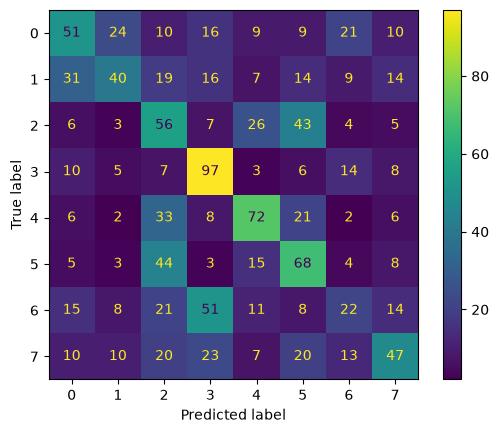

In [18]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# 1. Initialize the KNN model (using the parameters from the original notebook)
knn = KNeighborsClassifier(n_neighbors=5, algorithm='ball_tree', leaf_size=30)

# 2. Train the model
knn.fit(train_features, y_train)

# 3. Generate and display the confusion matrix using the estimator
ConfusionMatrixDisplay.from_estimator(knn, test_features, y_test)
plt.show()
plt.close()

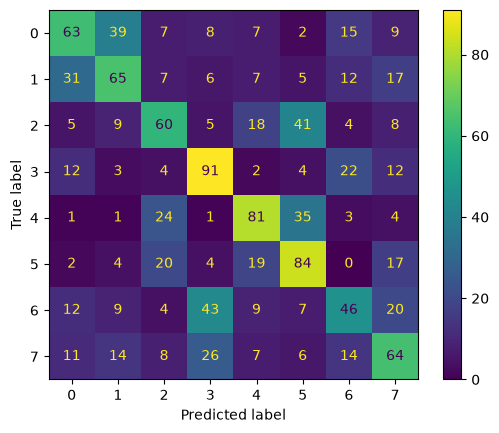

In [19]:
svc = SVC()
svc.fit(train_features, y_train)
ConfusionMatrixDisplay.from_estimator(svc, test_features, y_test)
plt.show()
plt.close()

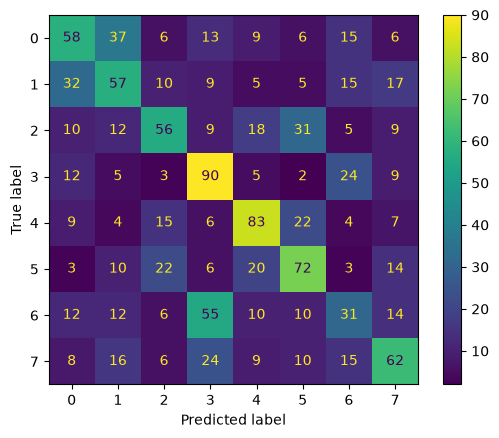

In [20]:
rf = RandomForestClassifier()
rf.fit(train_features, y_train)
ConfusionMatrixDisplay.from_estimator(rf, test_features, y_test)
plt.show()
plt.close()

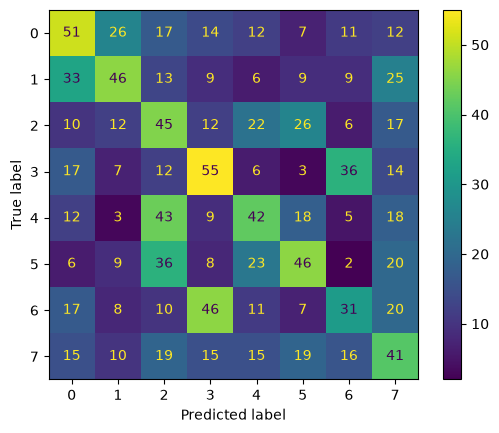

In [21]:
ada = AdaBoostClassifier()
ada.fit(train_features, y_train)
ConfusionMatrixDisplay.from_estimator(ada, test_features, y_test)
plt.show()
plt.close()

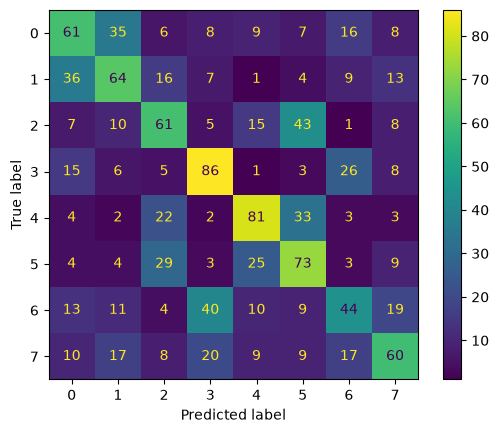

In [22]:
xgbc = XGBClassifier()
xgbc.fit(train_features, y_train)
ConfusionMatrixDisplay.from_estimator(xgbc, test_features, y_test)
plt.show()
plt.close()

# VGG-16

In [23]:
base_model= VGG16(input_shape=(224,224,3), weights='imagenet', include_top=False)
x = base_model.output
# x = Dropout(0.5)(x)
x = Flatten()(x)
# x = BatchNormalization()(x)
x = Dense(64,kernel_initializer='he_uniform')(x)
# x = BatchNormalization()(x)
x = Activation('relu')(x)
# x = Dropout(0.5)(x)
x = Dense(128,kernel_initializer='he_uniform')(x)
# x = BatchNormalization()(x)
x = Activation('relu')(x)
# x = Dropout(0.5)(x)
x = Dense(256,kernel_initializer='he_uniform')(x)
# x = BatchNormalization()(x)
x = Activation('relu')(x)
# x = Dropout(0.5)(x)
x = Dense(128,kernel_initializer='he_uniform')(x)
# x = BatchNormalization()(x)
x = Activation('relu')(x)
# x = Dropout(0.5)(x)
x = Dense(64,kernel_initializer='he_uniform')(x)
# x = BatchNormalization()(x)
x = Activation('relu')(x)
# x = Dropout(0.5)(x)
# MODIFICATION: model_feat's output used to be the final softmax
# classification layer (Dense(NUMBER_OF_CLASSES, activation='softmax')),
# which is a randomly-initialized, never-trained classification head --
# not a deep feature representation. train_features/val_features/
# test_features were therefore just NUMBER_OF_CLASSES noisy numbers per
# image, which is why every architecture collapsed to nearly identical,
# uninformative results. model_feat now outputs the layer BEFORE that
# final softmax -- the actual deep feature embedding this architecture
# extracted from the image -- which is what feeds the DNN/classical
# classifiers below.
model_feat = Model(inputs=base_model.input, outputs=x)

train_features = model_feat.predict(x_train, batch_size=FEATURE_BATCH_SIZE, verbose=1)
val_features = model_feat.predict(x_val, batch_size=FEATURE_BATCH_SIZE, verbose=1)
test_features = model_feat.predict(x_test, batch_size=FEATURE_BATCH_SIZE, verbose=1)

1400/1400 ━━━━━━━━━━━━━━━━━━━━ 26s 15ms/step
300/300 ━━━━━━━━━━━━━━━━━━━━ 5s 15ms/step
300/300 ━━━━━━━━━━━━━━━━━━━━ 5s 15ms/step


In [24]:
# ============================================================================
# MEMORY CLEANUP (added)
# ----------------------------------------------------------------------------
# base_model / model_feat are large TensorFlow graphs that stay resident in
# the TF backend session unless explicitly released. train_features /
# val_features / test_features above are already plain numpy arrays
# (the output of .predict()), fully detached from the graph, so they are
# NOT affected by this cleanup and remain available to the DNN / classical
# classifier cells that follow. This only releases the now-unneeded CNN
# backbone before the next architecture is built, preventing cumulative
# TensorFlow memory growth across the 11 backbones in this notebook.
# ============================================================================
# MODIFICATION (further investigation): the original cleanup here only
# released model_feat/base_model. Two additional objects were being kept
# alive across every architecture with no explicit release:
#   - dnn_model: rebuilt fresh each block via build_dnn_model(), but the
#     PREVIOUS block's instance was never explicitly deleted before
#     clear_session() ran, and clear_session() alone does not guarantee an
#     object is collected if something still holds a reference to it.
#   - history: the object returned by dnn_model.fit() retains a reference
#     back to the model it trained (for plotting/inspection later) and was
#     never deleted anywhere in the notebook -- 11 of these accumulate
#     across a full run.
# Neither is a redesign -- both are already-created objects from the
# unchanged pipeline; this just releases them at the same point the other
# per-architecture objects are already being released.
if 'dnn_model' in globals():
    del dnn_model
if 'history' in globals():
    del history
del model_feat
del base_model
tf.keras.backend.clear_session()
import gc
gc.collect()


0

In [25]:
from sklearn.pipeline import make_pipeline
from sklearn.pipeline import Pipeline
names = [
        "K Nearest Neighbour Classifier",
        'SVM',
        "Random Forest Classifier",
        "AdaBoost Classifier", 
        "XGB Classifier"
         ]
classifiers = [
    KNeighborsClassifier(n_neighbors = 5, algorithm='ball_tree', leaf_size=30),
    SVC(),
    RandomForestClassifier(max_depth=9,criterion = 'entropy'),
    AdaBoostClassifier(),
    XGBClassifier()
        ]
zipped_clf = zip(names,classifiers)
def classifier_summary(pipeline, X_train, y_train, X_val, y_val,X_test,y_test):
    sentiment_fit = pipeline.fit(X_train, y_train)
    
    y_pred_train= sentiment_fit.predict(X_train)
    y_pred_val = sentiment_fit.predict(X_val)
    y_pred_test = sentiment_fit.predict(X_test)
    
    train_accuracy = np.round(accuracy_score(y_train, y_pred_train),4)*100
    train_precision = np.round(precision_score(y_train, y_pred_train, average='weighted'),4)
    train_recall = np.round(recall_score(y_train, y_pred_train, average='weighted'),4)
    train_F1 = np.round(f1_score(y_train, y_pred_train, average='weighted'),4)
    train_kappa =  np.round(cohen_kappa_score(y_train, y_pred_train),4)
    
    
    val_accuracy = np.round(accuracy_score(y_val, y_pred_val),4)*100
    val_precision = np.round(precision_score(y_val, y_pred_val, average='weighted'),4)
    val_recall = np.round(recall_score(y_val, y_pred_val, average='weighted'),4)
    val_F1 = np.round(f1_score(y_val, y_pred_val, average='weighted'),4)
    val_kappa =  np.round(cohen_kappa_score(y_val, y_pred_val),4)
   
    
    test_accuracy = np.round(accuracy_score(y_test, y_pred_test),4)*100
    test_precision = np.round(precision_score(y_test, y_pred_test, average='weighted'),2)
    test_recall = np.round(recall_score(y_test, y_pred_test, average='weighted'),2)
    test_F1 = np.round(f1_score(y_test, y_pred_test, average='weighted'),2)
    test_kappa =  np.round(cohen_kappa_score(y_test, y_pred_test),2) 
  
    
    
    print()
    print('------------------------ Train Set Metrics------------------------')
    print()
    print("Accuracy core : {}%".format(train_accuracy))
    
    print('------------------------ Validation Set Metrics------------------------')
    print()
    print("Accuracy score : {}%".format(val_accuracy))
    print('------------------------ Test Set Metrics------------------------')
    print()
    print("Accuracy score : {}%".format(test_accuracy))
    print("F1_score : {}".format(test_F1))
    print("Kappa Score : {} ".format(test_kappa))
    print("Recall score: {}".format(test_recall))
    print("Precision score : {}".format(test_precision))
    
    print("-"*80)
    print()
    
def classifier_comparator(X_train,y_train,X_val,y_val,X_test,y_test,classifier=zipped_clf): 
    result = []
    for n,c in classifier:
        checker_pipeline = Pipeline([('Classifier', c)])
        print("------------------------------Fitting {} on input_data-------------------------------- ".format(n))
        #print(c)
        classifier_summary(checker_pipeline,X_train, y_train, X_val, y_val,X_test,y_test)

In [26]:
classifier_comparator(train_features,y_train,val_features,y_val,test_features,y_test,classifier=zipped_clf)

------------------------------Fitting K Nearest Neighbour Classifier on input_data-------------------------------- 

------------------------ Train Set Metrics------------------------

Accuracy core : 55.11000000000001%
------------------------ Validation Set Metrics------------------------

Accuracy score : 33.67%
------------------------ Test Set Metrics------------------------

Accuracy score : 33.17%
F1_score : 0.32
Kappa Score : 0.24 
Recall score: 0.33
Precision score : 0.32
--------------------------------------------------------------------------------

------------------------------Fitting SVM on input_data-------------------------------- 

------------------------ Train Set Metrics------------------------

Accuracy core : 49.07%
------------------------ Validation Set Metrics------------------------

Accuracy score : 43.08%
------------------------ Test Set Metrics------------------------

Accuracy score : 41.67%
F1_score : 0.41
Kappa Score : 0.33 
Recall score: 0.42
Precisio

In [27]:
train_y = to_categorical(y_train, NUMBER_OF_CLASSES)
val_y = to_categorical(y_val, NUMBER_OF_CLASSES)
test_y = to_categorical(y_test, NUMBER_OF_CLASSES)

# Robustness check: confirm one-hot label width matches the model's
# output layer size before training/evaluating this block.
# MODIFICATION: build a FRESH DNN instance here, sized to this
# architecture's actual feature width (train_features.shape[1]) --
# instead of reusing one shared dnn_model across every CNN block.
# Reusing one instance meant later blocks trained on top of weights
# already fit (and collapsed) by earlier blocks, and a hardcoded
# input_dim meant it silently accepted whatever shape came in.
print(f"train_features shape: {train_features.shape}")
print(f"val_features shape:   {val_features.shape}")
print(f"test_features shape:  {test_features.shape}")
print(f"Feature mean/std: {np.mean(train_features):.4f} / {np.std(train_features):.4f}")

dnn_input_dim = train_features.shape[1]
print(f"DNN input dimension (auto-detected): {dnn_input_dim}")
dnn_model = build_dnn_model(input_dim=dnn_input_dim, number_of_classes=NUMBER_OF_CLASSES)

assert train_y.shape[-1] == NUMBER_OF_CLASSES == dnn_model.output_shape[-1], (
    f"One-hot label width ({train_y.shape[-1]}) does not match "
    f"NUMBER_OF_CLASSES ({NUMBER_OF_CLASSES}) or DNN output size "
    f"({dnn_model.output_shape[-1]})."
)

print("TensorFlow version:", tf.__version__)

print("GPU:", tf.config.list_physical_devices('GPU'))

print(train_features.shape)
print(train_features.dtype)

print(train_y.shape)
print(train_y.dtype)

print(np.isnan(train_features).any())
print(np.isinf(train_features).any())

print(np.isnan(train_y).any())
print(np.isinf(train_y).any())

dnn_model.compile(optimizer='sgd',loss='categorical_crossentropy', metrics=['accuracy'],)

history = dnn_model.fit(
    train_features,
    train_y,
    validation_data=(val_features, val_y),
    epochs=10,
    batch_size=8,
    verbose=1
)
loss_value , accuracy = dnn_model.evaluate(train_features, train_y)
print('Train_accuracy is:' + str(accuracy))
loss_value , accuracy = dnn_model.evaluate(val_features, val_y)
print('Validation_accuracy is := ' + str(accuracy))
loss_value , accuracy = dnn_model.evaluate(test_features, test_y)
print('test_accuracy is : = ' + str(accuracy))

train_features shape: (5600, 64)
val_features shape:   (1200, 64)
test_features shape:  (1200, 64)
Feature mean/std: 5.5220 / 9.0096
DNN input dimension (auto-detected): 64
TensorFlow version: 2.21.0
GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
(5600, 64)
float32
(5600, 8)
float64
False
False
False
False
Epoch 1/10


/home/taha-ebaad/tf-env-312/lib/python3.12/site-packages/keras/src/layers/core/dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


700/700 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.1675 - loss: 2.0185 - val_accuracy: 0.2392 - val_loss: 1.8173
Epoch 2/10
700/700 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.2621 - loss: 1.8038 - val_accuracy: 0.2433 - val_loss: 1.7239
Epoch 3/10
700/700 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.3109 - loss: 1.7180 - val_accuracy: 0.2792 - val_loss: 1.7377
Epoch 4/10
700/700 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.3293 - loss: 1.6757 - val_accuracy: 0.3342 - val_loss: 1.6351
Epoch 5/10
700/700 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.3452 - loss: 1.6514 - val_accuracy: 0.3283 - val_loss: 1.6829
Epoch 6/10
700/700 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.3614 - loss: 1.6256 - val_accuracy: 0.3317 - val_loss: 1.6657
Epoch 7/10
700/700 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.3605 - loss: 1.6007 - val_accuracy: 0.3550 - val_loss: 1.5759
Epoch 8/10
700/700 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.3679 - loss: 1.5797 - val_accuracy: 0.3758 - val_

In [28]:
print("Performance Report:")

# Modern replacement for predict_classes and predict_proba
y_pred_probs = dnn_model.predict(test_features)
y_pred2 = np.argmax(y_pred_probs, axis=-1)
y_test2 = [np.argmax(x) for x in test_y]
y_pred_prb2 = y_pred_probs

target = class_names
from sklearn import metrics

print('Accuracy score is :', np.round(metrics.accuracy_score(y_test2, y_pred2), 4))
print('Precision score is :', np.round(metrics.precision_score(y_test2, y_pred2, average='weighted', zero_division=0), 4))
print('Recall score is :', np.round(metrics.recall_score(y_test2, y_pred2, average='weighted', zero_division=0), 4))
print('F1 Score is :', np.round(metrics.f1_score(y_test2, y_pred2, average='weighted', zero_division=0), 4))
print('Cohen Kappa Score:', np.round(metrics.cohen_kappa_score(y_test2, y_pred2), 4))
print('\t\tClassification Report:\n', metrics.classification_report(y_test2, y_pred2, target_names=target, zero_division=0))

Performance Report:
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step
Accuracy score is : 0.3708
Precision score is : 0.3861
Recall score is : 0.3708
F1 Score is : 0.359
Cohen Kappa Score: 0.281
		Classification Report:
                         precision    recall  f1-score   support

    dyed-lifted-polyps       0.38      0.33      0.36       150
dyed-resection-margins       0.46      0.11      0.17       150
           esophagitis       0.45      0.34      0.39       150
          normal-cecum       0.36      0.56      0.44       150
        normal-pylorus       0.42      0.50      0.46       150
         normal-z-line       0.47      0.44      0.46       150
                polyps       0.22      0.23      0.23       150
    ulcerative-colitis       0.33      0.45      0.38       150

              accuracy                           0.37      1200
             macro avg       0.39      0.37      0.36      1200
          weighted avg       0.39      0.37      0.36      1200



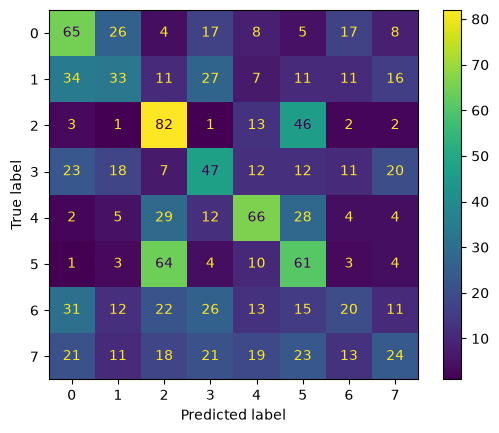

In [29]:
knn = KNeighborsClassifier(n_neighbors = 5, algorithm='ball_tree', leaf_size=30)
knn.fit(train_features, y_train)
ConfusionMatrixDisplay.from_estimator(knn, test_features, y_test)
plt.show()
plt.close()

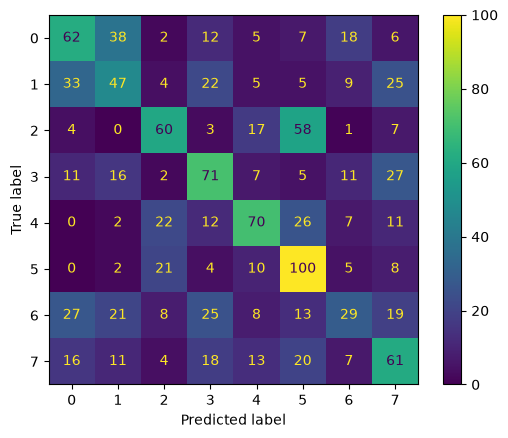

In [30]:
svc = SVC()
svc.fit(train_features, y_train)
ConfusionMatrixDisplay.from_estimator(svc, test_features, y_test)
plt.show()
plt.close()

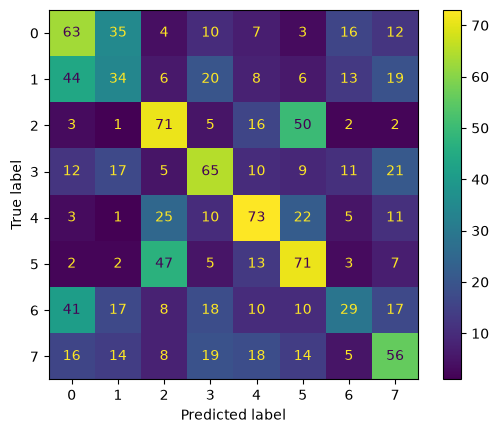

In [31]:
rf = RandomForestClassifier()
rf.fit(train_features, y_train)
ConfusionMatrixDisplay.from_estimator(rf, test_features, y_test)
plt.show()
plt.close()

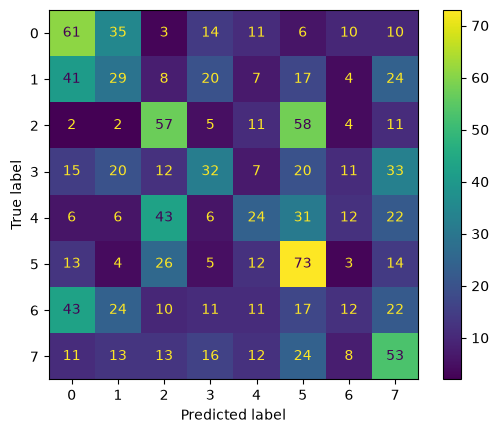

In [32]:
ada = AdaBoostClassifier()
ada.fit(train_features, y_train)
ConfusionMatrixDisplay.from_estimator(ada, test_features, y_test)
plt.show()
plt.close()

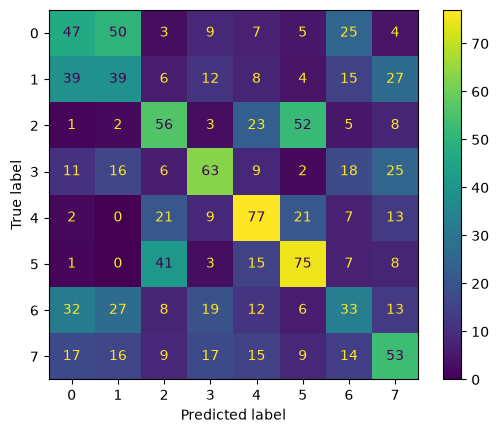

In [33]:
xgbc = XGBClassifier()
xgbc.fit(train_features, y_train)
ConfusionMatrixDisplay.from_estimator(xgbc, test_features, y_test)
plt.show()
plt.close()

In [34]:
import tensorflow as tf

print("TensorFlow:", tf.__version__)
print("GPUs:", tf.config.list_physical_devices('GPU'))

TensorFlow: 2.21.0
GPUs: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


# VGG-19

In [35]:
base_model= VGG19(input_shape=(224,224,3), weights='imagenet', include_top=False)
x = base_model.output
# x = Dropout(0.5)(x)
x = Flatten()(x)
# x = BatchNormalization()(x)
x = Dense(64,kernel_initializer='he_uniform')(x)
# x = BatchNormalization()(x)
x = Activation('relu')(x)
# x = Dropout(0.5)(x)
x = Dense(128,kernel_initializer='he_uniform')(x)
# x = BatchNormalization()(x)
x = Activation('relu')(x)
# x = Dropout(0.5)(x)
x = Dense(256,kernel_initializer='he_uniform')(x)
# x = BatchNormalization()(x)
x = Activation('relu')(x)
# x = Dropout(0.5)(x)
x = Dense(128,kernel_initializer='he_uniform')(x)
# x = BatchNormalization()(x)
x = Activation('relu')(x)
# x = Dropout(0.5)(x)
x = Dense(64,kernel_initializer='he_uniform')(x)
# x = BatchNormalization()(x)
x = Activation('relu')(x)
# x = Dropout(0.5)(x)
# MODIFICATION: model_feat's output used to be the final softmax
# classification layer (Dense(NUMBER_OF_CLASSES, activation='softmax')),
# which is a randomly-initialized, never-trained classification head --
# not a deep feature representation. train_features/val_features/
# test_features were therefore just NUMBER_OF_CLASSES noisy numbers per
# image, which is why every architecture collapsed to nearly identical,
# uninformative results. model_feat now outputs the layer BEFORE that
# final softmax -- the actual deep feature embedding this architecture
# extracted from the image -- which is what feeds the DNN/classical
# classifiers below.
model_feat = Model(inputs=base_model.input, outputs=x)

train_features = model_feat.predict(x_train, batch_size=FEATURE_BATCH_SIZE, verbose=1)
val_features = model_feat.predict(x_val, batch_size=FEATURE_BATCH_SIZE, verbose=1)
test_features = model_feat.predict(x_test, batch_size=FEATURE_BATCH_SIZE, verbose=1)

1400/1400 ━━━━━━━━━━━━━━━━━━━━ 28s 19ms/step
300/300 ━━━━━━━━━━━━━━━━━━━━ 6s 20ms/step
300/300 ━━━━━━━━━━━━━━━━━━━━ 6s 19ms/step


In [36]:
# ============================================================================
# MEMORY CLEANUP (added)
# ----------------------------------------------------------------------------
# base_model / model_feat are large TensorFlow graphs that stay resident in
# the TF backend session unless explicitly released. train_features /
# val_features / test_features above are already plain numpy arrays
# (the output of .predict()), fully detached from the graph, so they are
# NOT affected by this cleanup and remain available to the DNN / classical
# classifier cells that follow. This only releases the now-unneeded CNN
# backbone before the next architecture is built, preventing cumulative
# TensorFlow memory growth across the 11 backbones in this notebook.
# ============================================================================
# MODIFICATION (further investigation): the original cleanup here only
# released model_feat/base_model. Two additional objects were being kept
# alive across every architecture with no explicit release:
#   - dnn_model: rebuilt fresh each block via build_dnn_model(), but the
#     PREVIOUS block's instance was never explicitly deleted before
#     clear_session() ran, and clear_session() alone does not guarantee an
#     object is collected if something still holds a reference to it.
#   - history: the object returned by dnn_model.fit() retains a reference
#     back to the model it trained (for plotting/inspection later) and was
#     never deleted anywhere in the notebook -- 11 of these accumulate
#     across a full run.
# Neither is a redesign -- both are already-created objects from the
# unchanged pipeline; this just releases them at the same point the other
# per-architecture objects are already being released.
if 'dnn_model' in globals():
    del dnn_model
if 'history' in globals():
    del history
del model_feat
del base_model
tf.keras.backend.clear_session()
import gc
gc.collect()


0

In [37]:
from sklearn.pipeline import make_pipeline
from sklearn.pipeline import Pipeline
names = [
        "K Nearest Neighbour Classifier",
        'SVM',
        "Random Forest Classifier",
        "AdaBoost Classifier", 
        "XGB Classifier"
         ]
classifiers = [
    KNeighborsClassifier(n_neighbors = 5, algorithm='ball_tree', leaf_size=30),
    SVC(),
    RandomForestClassifier(max_depth=9,criterion = 'entropy'),
    AdaBoostClassifier(),
    XGBClassifier()
        ]
zipped_clf = zip(names,classifiers)
def classifier_summary(pipeline, X_train, y_train, X_val, y_val,X_test,y_test):
    sentiment_fit = pipeline.fit(X_train, y_train)
    
    y_pred_train= sentiment_fit.predict(X_train)
    y_pred_val = sentiment_fit.predict(X_val)
    y_pred_test = sentiment_fit.predict(X_test)
    
    train_accuracy = np.round(accuracy_score(y_train, y_pred_train),4)*100
    train_precision = np.round(precision_score(y_train, y_pred_train, average='weighted'),4)
    train_recall = np.round(recall_score(y_train, y_pred_train, average='weighted'),4)
    train_F1 = np.round(f1_score(y_train, y_pred_train, average='weighted'),4)
    train_kappa =  np.round(cohen_kappa_score(y_train, y_pred_train),4)
    
    
    val_accuracy = np.round(accuracy_score(y_val, y_pred_val),4)*100
    val_precision = np.round(precision_score(y_val, y_pred_val, average='weighted'),4)
    val_recall = np.round(recall_score(y_val, y_pred_val, average='weighted'),4)
    val_F1 = np.round(f1_score(y_val, y_pred_val, average='weighted'),4)
    val_kappa =  np.round(cohen_kappa_score(y_val, y_pred_val),4)
   
    
    test_accuracy = np.round(accuracy_score(y_test, y_pred_test),4)*100
    test_precision = np.round(precision_score(y_test, y_pred_test, average='weighted'),2)
    test_recall = np.round(recall_score(y_test, y_pred_test, average='weighted'),2)
    test_F1 = np.round(f1_score(y_test, y_pred_test, average='weighted'),2)
    test_kappa =  np.round(cohen_kappa_score(y_test, y_pred_test),2) 
  
    
    
    print()
    print('------------------------ Train Set Metrics------------------------')
    print()
    print("Accuracy core : {}%".format(train_accuracy))
    
    print('------------------------ Validation Set Metrics------------------------')
    print()
    print("Accuracy score : {}%".format(val_accuracy))
    print('------------------------ Test Set Metrics------------------------')
    print()
    print("Accuracy score : {}%".format(test_accuracy))
    print("F1_score : {}".format(test_F1))
    print("Kappa Score : {} ".format(test_kappa))
    print("Recall score: {}".format(test_recall))
    print("Precision score : {}".format(test_precision))
    
    print("-"*80)
    print()
    
def classifier_comparator(X_train,y_train,X_val,y_val,X_test,y_test,classifier=zipped_clf): 
    result = []
    for n,c in classifier:
        checker_pipeline = Pipeline([('Classifier', c)])
        print("------------------------------Fitting {} on input_data-------------------------------- ".format(n))
        #print(c)
        classifier_summary(checker_pipeline,X_train, y_train, X_val, y_val,X_test,y_test)

In [38]:
classifier_comparator(train_features,y_train,val_features,y_val,test_features,y_test,classifier=zipped_clf)

------------------------------Fitting K Nearest Neighbour Classifier on input_data-------------------------------- 

------------------------ Train Set Metrics------------------------

Accuracy core : 51.85999999999999%
------------------------ Validation Set Metrics------------------------

Accuracy score : 30.830000000000002%
------------------------ Test Set Metrics------------------------

Accuracy score : 30.17%
F1_score : 0.29
Kappa Score : 0.2 
Recall score: 0.3
Precision score : 0.3
--------------------------------------------------------------------------------

------------------------------Fitting SVM on input_data-------------------------------- 

------------------------ Train Set Metrics------------------------

Accuracy core : 52.88%
------------------------ Validation Set Metrics------------------------

Accuracy score : 41.0%
------------------------ Test Set Metrics------------------------

Accuracy score : 41.25%
F1_score : 0.4
Kappa Score : 0.33 
Recall score: 0.41


In [39]:
train_y = to_categorical(y_train, NUMBER_OF_CLASSES)
val_y = to_categorical(y_val, NUMBER_OF_CLASSES)
test_y = to_categorical(y_test, NUMBER_OF_CLASSES)

# Robustness check: confirm one-hot label width matches the model's
# output layer size before training/evaluating this block.
# MODIFICATION: build a FRESH DNN instance here, sized to this
# architecture's actual feature width (train_features.shape[1]) --
# instead of reusing one shared dnn_model across every CNN block.
# Reusing one instance meant later blocks trained on top of weights
# already fit (and collapsed) by earlier blocks, and a hardcoded
# input_dim meant it silently accepted whatever shape came in.
print(f"train_features shape: {train_features.shape}")
print(f"val_features shape:   {val_features.shape}")
print(f"test_features shape:  {test_features.shape}")
print(f"Feature mean/std: {np.mean(train_features):.4f} / {np.std(train_features):.4f}")

dnn_input_dim = train_features.shape[1]
print(f"DNN input dimension (auto-detected): {dnn_input_dim}")
dnn_model = build_dnn_model(input_dim=dnn_input_dim, number_of_classes=NUMBER_OF_CLASSES)

assert train_y.shape[-1] == NUMBER_OF_CLASSES == dnn_model.output_shape[-1], (
    f"One-hot label width ({train_y.shape[-1]}) does not match "
    f"NUMBER_OF_CLASSES ({NUMBER_OF_CLASSES}) or DNN output size "
    f"({dnn_model.output_shape[-1]})."
)

dnn_model.compile(optimizer='adam',loss='categorical_crossentropy', metrics=['accuracy'])

history = dnn_model.fit(
    train_features,
    train_y,
    validation_data=(val_features, val_y),
    epochs=10,
    batch_size=8,
    verbose=1
)
loss_value , accuracy = dnn_model.evaluate(train_features, train_y)
print('Train_accuracy is:' + str(accuracy))
loss_value , accuracy = dnn_model.evaluate(val_features, val_y)
print('Validation_accuracy is := ' + str(accuracy))
loss_value , accuracy = dnn_model.evaluate(test_features, test_y)
print('test_accuracy is : = ' + str(accuracy))

train_features shape: (5600, 64)
val_features shape:   (1200, 64)
test_features shape:  (1200, 64)


/home/taha-ebaad/tf-env-312/lib/python3.12/site-packages/keras/src/layers/core/dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Feature mean/std: 4.5188 / 6.3707
DNN input dimension (auto-detected): 64
Epoch 1/10
700/700 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.2307 - loss: 1.8764 - val_accuracy: 0.2808 - val_loss: 1.7797
Epoch 2/10
700/700 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.2914 - loss: 1.7331 - val_accuracy: 0.2958 - val_loss: 1.7276
Epoch 3/10
700/700 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.3245 - loss: 1.6687 - val_accuracy: 0.3308 - val_loss: 1.7049
Epoch 4/10
700/700 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.3487 - loss: 1.6270 - val_accuracy: 0.3275 - val_loss: 1.6898
Epoch 5/10
700/700 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.3555 - loss: 1.5958 - val_accuracy: 0.3458 - val_loss: 1.6585
Epoch 6/10
700/700 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.3650 - loss: 1.5709 - val_accuracy: 0.3517 - val_loss: 1.6321
Epoch 7/10
700/700 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.3750 - loss: 1.5481 - val_accuracy: 0.3467 - val_loss: 1.6632
Epoch 8/10
700/700 ━━━━━━━━━━━

In [40]:
print("Performance Report:")

# Modern replacement for predict_classes and predict_proba
y_pred_probs = dnn_model.predict(test_features)
y_pred1 = np.argmax(y_pred_probs, axis=-1)
y_test1 = [np.argmax(x) for x in test_y]
y_pred_prb1 = y_pred_probs

target = class_names
from sklearn import metrics

print('Accuracy score is :', np.round(metrics.accuracy_score(y_test1, y_pred1), 4))
print('Precision score is :', np.round(metrics.precision_score(y_test1, y_pred1, average='weighted', zero_division=0), 4))
print('Recall score is :', np.round(metrics.recall_score(y_test1, y_pred1, average='weighted', zero_division=0), 4))
print('F1 Score is :', np.round(metrics.f1_score(y_test1, y_pred1, average='weighted', zero_division=0), 4))
print('Cohen Kappa Score:', np.round(metrics.cohen_kappa_score(y_test1, y_pred1), 4))
print('\t\tClassification Report:\n', metrics.classification_report(y_test1, y_pred1, target_names=target, zero_division=0))

Performance Report:
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step
Accuracy score is : 0.3267
Precision score is : 0.335
Recall score is : 0.3267
F1 Score is : 0.296
Cohen Kappa Score: 0.2305
		Classification Report:
                         precision    recall  f1-score   support

    dyed-lifted-polyps       0.27      0.19      0.22       150
dyed-resection-margins       0.34      0.17      0.22       150
           esophagitis       0.20      0.18      0.19       150
          normal-cecum       0.31      0.54      0.40       150
        normal-pylorus       0.38      0.70      0.49       150
         normal-z-line       0.31      0.44      0.37       150
                polyps       0.45      0.06      0.11       150
    ulcerative-colitis       0.41      0.34      0.37       150

              accuracy                           0.33      1200
             macro avg       0.33      0.33      0.30      1200
          weighted avg       0.33      0.33      0.30      1200



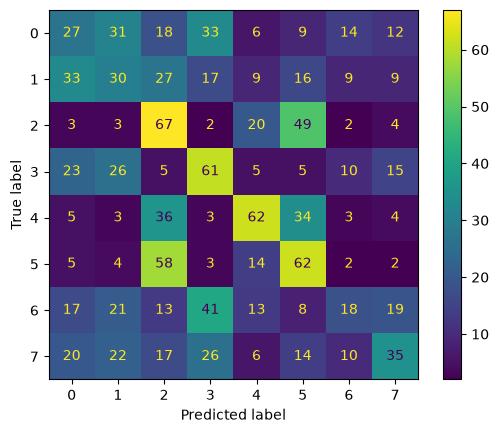

In [41]:
knn = KNeighborsClassifier(n_neighbors = 5, algorithm='ball_tree', leaf_size=30)
knn.fit(train_features, y_train)
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Replace the model name (e.g., knn, svc, rf, ada, or xgbc) accordingly in each cell
ConfusionMatrixDisplay.from_estimator(knn, test_features, y_test)
plt.show()
plt.close()

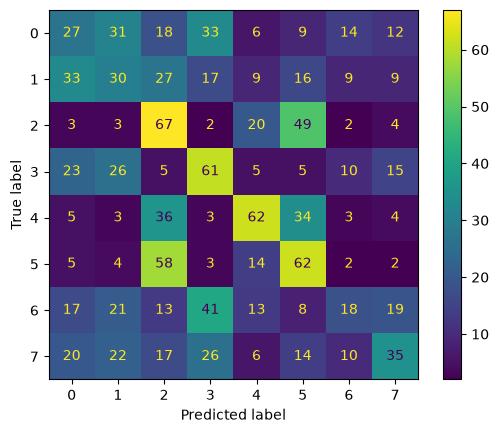

In [42]:
svc = SVC()
svc.fit(train_features, y_train)
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Replace the model name (e.g., knn, svc, rf, ada, or xgbc) accordingly in each cell
ConfusionMatrixDisplay.from_estimator(knn, test_features, y_test)
plt.show()
plt.close()

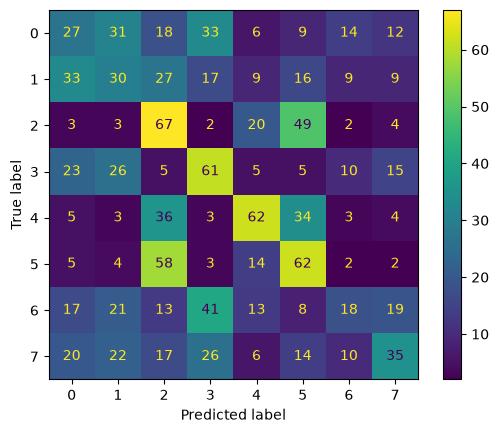

In [43]:
rf = RandomForestClassifier()
rf.fit(train_features, y_train)
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Replace the model name (e.g., knn, svc, rf, ada, or xgbc) accordingly in each cell
ConfusionMatrixDisplay.from_estimator(knn, test_features, y_test)
plt.show()
plt.close()

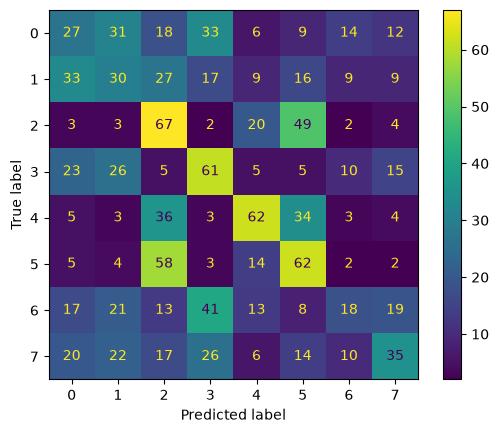

In [44]:
ada = AdaBoostClassifier()
ada.fit(train_features, y_train)
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Replace the model name (e.g., knn, svc, rf, ada, or xgbc) accordingly in each cell
ConfusionMatrixDisplay.from_estimator(knn, test_features, y_test)
plt.show()
plt.close()

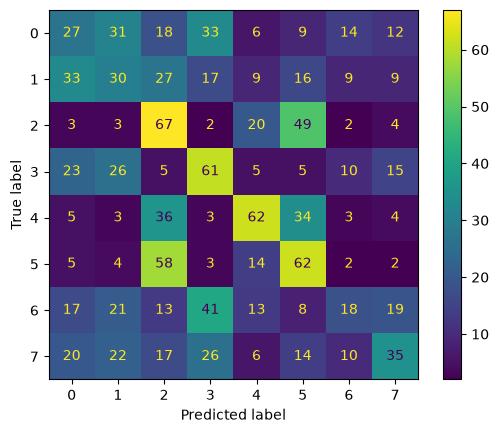

In [45]:
xgbc = XGBClassifier()
xgbc.fit(train_features, y_train)
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Replace the model name (e.g., knn, svc, rf, ada, or xgbc) accordingly in each cell
ConfusionMatrixDisplay.from_estimator(knn, test_features, y_test)
plt.show()
plt.close()

# ResNet101

In [46]:
base_model= ResNet101(input_shape=(224,224,3), weights='imagenet', include_top=False)
x = base_model.output
# x = Dropout(0.5)(x)
x = Flatten()(x)
# x = BatchNormalization()(x)
x = Dense(64,kernel_initializer='he_uniform')(x)
# x = BatchNormalization()(x)
x = Activation('relu')(x)
# x = Dropout(0.5)(x)
x = Dense(128,kernel_initializer='he_uniform')(x)
# x = BatchNormalization()(x)
x = Activation('relu')(x)
# x = Dropout(0.5)(x)
x = Dense(256,kernel_initializer='he_uniform')(x)
# x = BatchNormalization()(x)
x = Activation('relu')(x)
# x = Dropout(0.5)(x)
x = Dense(128,kernel_initializer='he_uniform')(x)
# x = BatchNormalization()(x)
x = Activation('relu')(x)
# x = Dropout(0.5)(x)
x = Dense(64,kernel_initializer='he_uniform')(x)
# x = BatchNormalization()(x)
x = Activation('relu')(x)
# x = Dropout(0.5)(x)
# MODIFICATION: model_feat's output used to be the final softmax
# classification layer (Dense(NUMBER_OF_CLASSES, activation='softmax')),
# which is a randomly-initialized, never-trained classification head --
# not a deep feature representation. train_features/val_features/
# test_features were therefore just NUMBER_OF_CLASSES noisy numbers per
# image, which is why every architecture collapsed to nearly identical,
# uninformative results. model_feat now outputs the layer BEFORE that
# final softmax -- the actual deep feature embedding this architecture
# extracted from the image -- which is what feeds the DNN/classical
# classifiers below.
model_feat = Model(inputs=base_model.input, outputs=x)

train_features = model_feat.predict(x_train, batch_size=FEATURE_BATCH_SIZE, verbose=1)
val_features = model_feat.predict(x_val, batch_size=FEATURE_BATCH_SIZE, verbose=1)
test_features = model_feat.predict(x_test, batch_size=FEATURE_BATCH_SIZE, verbose=1)

1400/1400 ━━━━━━━━━━━━━━━━━━━━ 35s 22ms/step
300/300 ━━━━━━━━━━━━━━━━━━━━ 6s 20ms/step
300/300 ━━━━━━━━━━━━━━━━━━━━ 6s 20ms/step


In [47]:
# ============================================================================
# MEMORY CLEANUP (added)
# ----------------------------------------------------------------------------
# base_model / model_feat are large TensorFlow graphs that stay resident in
# the TF backend session unless explicitly released. train_features /
# val_features / test_features above are already plain numpy arrays
# (the output of .predict()), fully detached from the graph, so they are
# NOT affected by this cleanup and remain available to the DNN / classical
# classifier cells that follow. This only releases the now-unneeded CNN
# backbone before the next architecture is built, preventing cumulative
# TensorFlow memory growth across the 11 backbones in this notebook.
# ============================================================================
# MODIFICATION (further investigation): the original cleanup here only
# released model_feat/base_model. Two additional objects were being kept
# alive across every architecture with no explicit release:
#   - dnn_model: rebuilt fresh each block via build_dnn_model(), but the
#     PREVIOUS block's instance was never explicitly deleted before
#     clear_session() ran, and clear_session() alone does not guarantee an
#     object is collected if something still holds a reference to it.
#   - history: the object returned by dnn_model.fit() retains a reference
#     back to the model it trained (for plotting/inspection later) and was
#     never deleted anywhere in the notebook -- 11 of these accumulate
#     across a full run.
# Neither is a redesign -- both are already-created objects from the
# unchanged pipeline; this just releases them at the same point the other
# per-architecture objects are already being released.
if 'dnn_model' in globals():
    del dnn_model
if 'history' in globals():
    del history
del model_feat
del base_model
tf.keras.backend.clear_session()
import gc
gc.collect()


0

In [48]:
from sklearn.pipeline import make_pipeline
from sklearn.pipeline import Pipeline
names = [
        "K Nearest Neighbour Classifier",
        'SVM',
        "Random Forest Classifier",
        "AdaBoost Classifier", 
        "XGB Classifier"
         ]
classifiers = [
    KNeighborsClassifier(n_neighbors = 5, algorithm='ball_tree', leaf_size=30),
    SVC(),
    RandomForestClassifier(max_depth=9,criterion = 'entropy'),
    AdaBoostClassifier(),
    XGBClassifier()
        ]
zipped_clf = zip(names,classifiers)
def classifier_summary(pipeline, X_train, y_train, X_val, y_val,X_test,y_test):
    sentiment_fit = pipeline.fit(X_train, y_train)
    
    y_pred_train= sentiment_fit.predict(X_train)
    y_pred_val = sentiment_fit.predict(X_val)
    y_pred_test = sentiment_fit.predict(X_test)
    
    train_accuracy = np.round(accuracy_score(y_train, y_pred_train),4)*100
    train_precision = np.round(precision_score(y_train, y_pred_train, average='weighted'),4)
    train_recall = np.round(recall_score(y_train, y_pred_train, average='weighted'),4)
    train_F1 = np.round(f1_score(y_train, y_pred_train, average='weighted'),4)
    train_kappa =  np.round(cohen_kappa_score(y_train, y_pred_train),4)
    
    
    val_accuracy = np.round(accuracy_score(y_val, y_pred_val),4)*100
    val_precision = np.round(precision_score(y_val, y_pred_val, average='weighted'),4)
    val_recall = np.round(recall_score(y_val, y_pred_val, average='weighted'),4)
    val_F1 = np.round(f1_score(y_val, y_pred_val, average='weighted'),4)
    val_kappa =  np.round(cohen_kappa_score(y_val, y_pred_val),4)
   
    
    test_accuracy = np.round(accuracy_score(y_test, y_pred_test),4)*100
    test_precision = np.round(precision_score(y_test, y_pred_test, average='weighted'),2)
    test_recall = np.round(recall_score(y_test, y_pred_test, average='weighted'),2)
    test_F1 = np.round(f1_score(y_test, y_pred_test, average='weighted'),2)
    test_kappa =  np.round(cohen_kappa_score(y_test, y_pred_test),2) 
  
    
    
    print()
    print('------------------------ Train Set Metrics------------------------')
    print()
    print("Accuracy core : {}%".format(train_accuracy))
    
    print('------------------------ Validation Set Metrics------------------------')
    print()
    print("Accuracy score : {}%".format(val_accuracy))
    print('------------------------ Test Set Metrics------------------------')
    print()
    print("Accuracy score : {}%".format(test_accuracy))
    print("F1_score : {}".format(test_F1))
    print("Kappa Score : {} ".format(test_kappa))
    print("Recall score: {}".format(test_recall))
    print("Precision score : {}".format(test_precision))
    
    print("-"*80)
    print()
    
def classifier_comparator(X_train,y_train,X_val,y_val,X_test,y_test,classifier=zipped_clf): 
    result = []
    for n,c in classifier:
        checker_pipeline = Pipeline([('Classifier', c)])
        print("------------------------------Fitting {} on input_data-------------------------------- ".format(n))
        #print(c)
        classifier_summary(checker_pipeline,X_train, y_train, X_val, y_val,X_test,y_test)

In [49]:
classifier_comparator(train_features,y_train,val_features,y_val,test_features,y_test,classifier=zipped_clf)

------------------------------Fitting K Nearest Neighbour Classifier on input_data-------------------------------- 

------------------------ Train Set Metrics------------------------

Accuracy core : 58.040000000000006%
------------------------ Validation Set Metrics------------------------

Accuracy score : 35.58%
------------------------ Test Set Metrics------------------------

Accuracy score : 34.75%
F1_score : 0.34
Kappa Score : 0.25 
Recall score: 0.35
Precision score : 0.35
--------------------------------------------------------------------------------

------------------------------Fitting SVM on input_data-------------------------------- 

------------------------ Train Set Metrics------------------------

Accuracy core : 53.52%
------------------------ Validation Set Metrics------------------------

Accuracy score : 46.67%
------------------------ Test Set Metrics------------------------

Accuracy score : 47.67%
F1_score : 0.47
Kappa Score : 0.4 
Recall score: 0.48
Precisio

In [50]:
train_y=to_categorical(y_train, NUMBER_OF_CLASSES)
val_y=to_categorical(y_val, NUMBER_OF_CLASSES)
test_y=to_categorical(y_test, NUMBER_OF_CLASSES)

# Robustness check: confirm one-hot label width matches the model's
# output layer size before training/evaluating this block.
# MODIFICATION: build a FRESH DNN instance here, sized to this
# architecture's actual feature width (train_features.shape[1]) --
# instead of reusing one shared dnn_model across every CNN block.
# Reusing one instance meant later blocks trained on top of weights
# already fit (and collapsed) by earlier blocks, and a hardcoded
# input_dim meant it silently accepted whatever shape came in.
print(f"train_features shape: {train_features.shape}")
print(f"val_features shape:   {val_features.shape}")
print(f"test_features shape:  {test_features.shape}")
print(f"Feature mean/std: {np.mean(train_features):.4f} / {np.std(train_features):.4f}")

dnn_input_dim = train_features.shape[1]
print(f"DNN input dimension (auto-detected): {dnn_input_dim}")
dnn_model = build_dnn_model(input_dim=dnn_input_dim, number_of_classes=NUMBER_OF_CLASSES)

assert train_y.shape[-1] == NUMBER_OF_CLASSES == dnn_model.output_shape[-1], (
    f"One-hot label width ({train_y.shape[-1]}) does not match "
    f"NUMBER_OF_CLASSES ({NUMBER_OF_CLASSES}) or DNN output size "
    f"({dnn_model.output_shape[-1]})."
)
dnn_model.compile(optimizer='adam',loss='categorical_crossentropy', metrics=['accuracy'])


history = dnn_model.fit(
    train_features,
    train_y,
    validation_data=(val_features, val_y),
    epochs=10,
    batch_size=8,
    verbose=1
)
loss_value , accuracy = dnn_model.evaluate(train_features, train_y)
print('Train_accuracy is:' + str(accuracy))
loss_value , accuracy = dnn_model.evaluate(val_features, val_y)
print('Validation_accuracy is := ' + str(accuracy))
loss_value , accuracy = dnn_model.evaluate(test_features, test_y)
print('test_accuracy is : = ' + str(accuracy))

train_features shape: (5600, 64)
val_features shape:   (1200, 64)
test_features shape:  (1200, 64)
Feature mean/std: 1.1476 / 1.7508
DNN input dimension (auto-detected): 64


/home/taha-ebaad/tf-env-312/lib/python3.12/site-packages/keras/src/layers/core/dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
700/700 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.2655 - loss: 1.7365 - val_accuracy: 0.3233 - val_loss: 1.5848
Epoch 2/10
700/700 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.3414 - loss: 1.5609 - val_accuracy: 0.3317 - val_loss: 1.5666
Epoch 3/10
700/700 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.3561 - loss: 1.5223 - val_accuracy: 0.3817 - val_loss: 1.5028
Epoch 4/10
700/700 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.3802 - loss: 1.4761 - val_accuracy: 0.3892 - val_loss: 1.4672
Epoch 5/10
700/700 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.3916 - loss: 1.4497 - val_accuracy: 0.3975 - val_loss: 1.4213
Epoch 6/10
700/700 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.4118 - loss: 1.4309 - val_accuracy: 0.3850 - val_loss: 1.4631
Epoch 7/10
700/700 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.4189 - loss: 1.4112 - val_accuracy: 0.3917 - val_loss: 1.4434
Epoch 8/10
700/700 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.4234 - loss: 1.3907 - val_accuracy: 0.

In [51]:
print("Performance Report:")

# Modern replacement for predict_classes and predict_proba
y_pred_probs = dnn_model.predict(test_features)
y_pred3 = np.argmax(y_pred_probs, axis=-1)
y_test3 = [np.argmax(x) for x in test_y]
y_pred_prb3 = y_pred_probs

target = class_names
from sklearn import metrics

print('Accuracy score is :', np.round(metrics.accuracy_score(y_test3, y_pred3), 4))
print('Precision score is :', np.round(metrics.precision_score(y_test3, y_pred3, average='weighted', zero_division=0), 4))
print('Recall score is :', np.round(metrics.recall_score(y_test3, y_pred3, average='weighted', zero_division=0), 4))
print('F1 Score is :', np.round(metrics.f1_score(y_test3, y_pred3, average='weighted', zero_division=0), 4))
print('Cohen Kappa Score:', np.round(metrics.cohen_kappa_score(y_test3, y_pred3), 4))
print('\t\tClassification Report:\n', metrics.classification_report(y_test3, y_pred3, target_names=target, zero_division=0))

Performance Report:
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step
Accuracy score is : 0.4258
Precision score is : 0.4301
Recall score is : 0.4258
F1 Score is : 0.4221
Cohen Kappa Score: 0.3438
		Classification Report:
                         precision    recall  f1-score   support

    dyed-lifted-polyps       0.39      0.40      0.39       150
dyed-resection-margins       0.50      0.39      0.44       150
           esophagitis       0.42      0.41      0.41       150
          normal-cecum       0.41      0.58      0.48       150
        normal-pylorus       0.54      0.50      0.52       150
         normal-z-line       0.40      0.54      0.46       150
                polyps       0.31      0.26      0.28       150
    ulcerative-colitis       0.46      0.33      0.38       150

              accuracy                           0.43      1200
             macro avg       0.43      0.43      0.42      1200
          weighted avg       0.43      0.43      0.42      1200



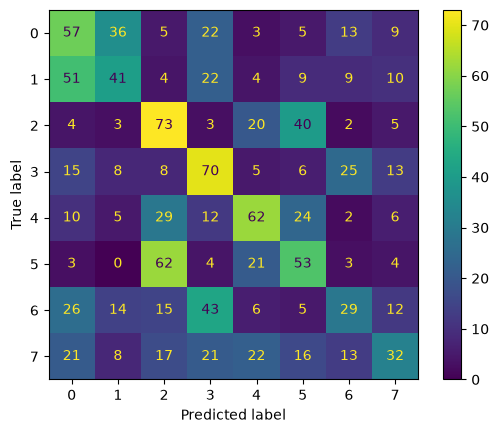

In [52]:
knn = KNeighborsClassifier(n_neighbors = 5, algorithm='ball_tree', leaf_size=30)
knn.fit(train_features, y_train)
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Swap out 'knn' with 'svc', 'rf', 'ada', or 'xgbc' respectively in each cell
ConfusionMatrixDisplay.from_estimator(knn, test_features, y_test)
plt.show()
plt.close()

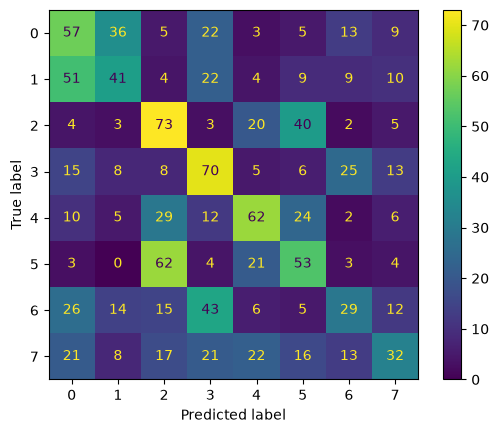

In [53]:
svc = SVC()
svc.fit(train_features, y_train)
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Swap out 'knn' with 'svc', 'rf', 'ada', or 'xgbc' respectively in each cell
ConfusionMatrixDisplay.from_estimator(knn, test_features, y_test)
plt.show()
plt.close()

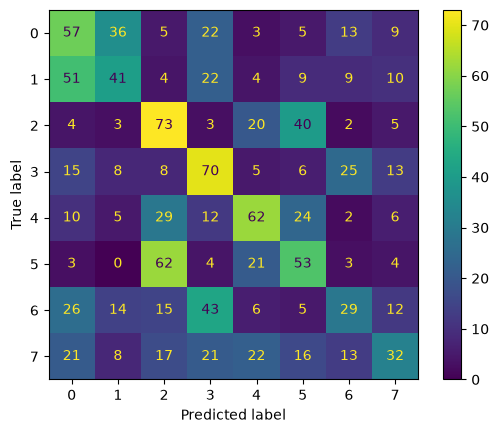

In [54]:
rf = RandomForestClassifier()
rf.fit(train_features, y_train)
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Swap out 'knn' with 'svc', 'rf', 'ada', or 'xgbc' respectively in each cell
ConfusionMatrixDisplay.from_estimator(knn, test_features, y_test)
plt.show()
plt.close()

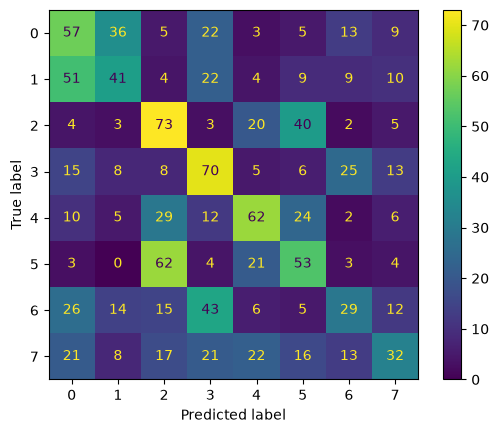

In [55]:
ada = AdaBoostClassifier()
ada.fit(train_features, y_train)
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Swap out 'knn' with 'svc', 'rf', 'ada', or 'xgbc' respectively in each cell
ConfusionMatrixDisplay.from_estimator(knn, test_features, y_test)
plt.show()
plt.close()

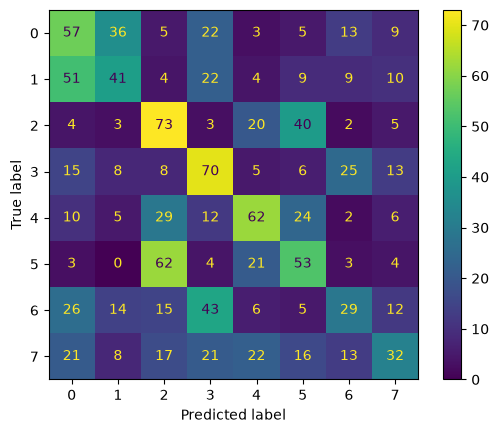

In [56]:
xgbc = XGBClassifier()
xgbc.fit(train_features, y_train)
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Swap out 'knn' with 'svc', 'rf', 'ada', or 'xgbc' respectively in each cell
ConfusionMatrixDisplay.from_estimator(knn, test_features, y_test)
plt.show()
plt.close()

# MobileNetV2

In [57]:
base_model= MobileNetV2(input_shape=(224,224,3), weights='imagenet', include_top=False)
x = base_model.output
# x = Dropout(0.5)(x)
x = Flatten()(x)
# x = BatchNormalization()(x)
x = Dense(64,kernel_initializer='he_uniform')(x)
# x = BatchNormalization()(x)
x = Activation('relu')(x)
# x = Dropout(0.5)(x)
x = Dense(128,kernel_initializer='he_uniform')(x)
# x = BatchNormalization()(x)
x = Activation('relu')(x)
# x = Dropout(0.5)(x)
x = Dense(256,kernel_initializer='he_uniform')(x)
# x = BatchNormalization()(x)
x = Activation('relu')(x)
# x = Dropout(0.5)(x)
x = Dense(128,kernel_initializer='he_uniform')(x)
# x = BatchNormalization()(x)
x = Activation('relu')(x)
# x = Dropout(0.5)(x)
x = Dense(64,kernel_initializer='he_uniform')(x)
# x = BatchNormalization()(x)
x = Activation('relu')(x)
# x = Dropout(0.5)(x)
# MODIFICATION: model_feat's output used to be the final softmax
# classification layer (Dense(NUMBER_OF_CLASSES, activation='softmax')),
# which is a randomly-initialized, never-trained classification head --
# not a deep feature representation. train_features/val_features/
# test_features were therefore just NUMBER_OF_CLASSES noisy numbers per
# image, which is why every architecture collapsed to nearly identical,
# uninformative results. model_feat now outputs the layer BEFORE that
# final softmax -- the actual deep feature embedding this architecture
# extracted from the image -- which is what feeds the DNN/classical
# classifiers below.
model_feat = Model(inputs=base_model.input, outputs=x)

train_features = model_feat.predict(x_train, batch_size=FEATURE_BATCH_SIZE, verbose=1)
val_features = model_feat.predict(x_val, batch_size=FEATURE_BATCH_SIZE, verbose=1)
test_features = model_feat.predict(x_test, batch_size=FEATURE_BATCH_SIZE, verbose=1)

E0000 00:00:1785927933.298180     176 cuda_timer.cc:87] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


1400/1400 ━━━━━━━━━━━━━━━━━━━━ 16s 5ms/step
300/300 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step
300/300 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step


In [58]:
# ============================================================================
# MEMORY CLEANUP (added)
# ----------------------------------------------------------------------------
# base_model / model_feat are large TensorFlow graphs that stay resident in
# the TF backend session unless explicitly released. train_features /
# val_features / test_features above are already plain numpy arrays
# (the output of .predict()), fully detached from the graph, so they are
# NOT affected by this cleanup and remain available to the DNN / classical
# classifier cells that follow. This only releases the now-unneeded CNN
# backbone before the next architecture is built, preventing cumulative
# TensorFlow memory growth across the 11 backbones in this notebook.
# ============================================================================
# MODIFICATION (further investigation): the original cleanup here only
# released model_feat/base_model. Two additional objects were being kept
# alive across every architecture with no explicit release:
#   - dnn_model: rebuilt fresh each block via build_dnn_model(), but the
#     PREVIOUS block's instance was never explicitly deleted before
#     clear_session() ran, and clear_session() alone does not guarantee an
#     object is collected if something still holds a reference to it.
#   - history: the object returned by dnn_model.fit() retains a reference
#     back to the model it trained (for plotting/inspection later) and was
#     never deleted anywhere in the notebook -- 11 of these accumulate
#     across a full run.
# Neither is a redesign -- both are already-created objects from the
# unchanged pipeline; this just releases them at the same point the other
# per-architecture objects are already being released.
if 'dnn_model' in globals():
    del dnn_model
if 'history' in globals():
    del history
del model_feat
del base_model
tf.keras.backend.clear_session()
import gc
gc.collect()


0

In [59]:
from sklearn.pipeline import make_pipeline
from sklearn.pipeline import Pipeline
names = [
        "K Nearest Neighbour Classifier",
        'SVM',
        "Random Forest Classifier",
        "AdaBoost Classifier", 
        "XGB Classifier"
         ]
classifiers = [
    KNeighborsClassifier(n_neighbors = 5, algorithm='ball_tree', leaf_size=30),
    SVC(),
    RandomForestClassifier(max_depth=9,criterion = 'entropy'),
    AdaBoostClassifier(),
    XGBClassifier()
        ]
zipped_clf = zip(names,classifiers)
def classifier_summary(pipeline, X_train, y_train, X_val, y_val,X_test,y_test):
    sentiment_fit = pipeline.fit(X_train, y_train)
    
    y_pred_train= sentiment_fit.predict(X_train)
    y_pred_val = sentiment_fit.predict(X_val)
    y_pred_test = sentiment_fit.predict(X_test)
    
    train_accuracy = np.round(accuracy_score(y_train, y_pred_train),4)*100
    train_precision = np.round(precision_score(y_train, y_pred_train, average='weighted'),4)
    train_recall = np.round(recall_score(y_train, y_pred_train, average='weighted'),4)
    train_F1 = np.round(f1_score(y_train, y_pred_train, average='weighted'),4)
    train_kappa =  np.round(cohen_kappa_score(y_train, y_pred_train),4)
    
    
    val_accuracy = np.round(accuracy_score(y_val, y_pred_val),4)*100
    val_precision = np.round(precision_score(y_val, y_pred_val, average='weighted'),4)
    val_recall = np.round(recall_score(y_val, y_pred_val, average='weighted'),4)
    val_F1 = np.round(f1_score(y_val, y_pred_val, average='weighted'),4)
    val_kappa =  np.round(cohen_kappa_score(y_val, y_pred_val),4)
   
    
    test_accuracy = np.round(accuracy_score(y_test, y_pred_test),4)*100
    test_precision = np.round(precision_score(y_test, y_pred_test, average='weighted'),2)
    test_recall = np.round(recall_score(y_test, y_pred_test, average='weighted'),2)
    test_F1 = np.round(f1_score(y_test, y_pred_test, average='weighted'),2)
    test_kappa =  np.round(cohen_kappa_score(y_test, y_pred_test),2) 
  
    
    
    print()
    print('------------------------ Train Set Metrics------------------------')
    print()
    print("Accuracy core : {}%".format(train_accuracy))
    
    print('------------------------ Validation Set Metrics------------------------')
    print()
    print("Accuracy score : {}%".format(val_accuracy))
    print('------------------------ Test Set Metrics------------------------')
    print()
    print("Accuracy score : {}%".format(test_accuracy))
    print("F1_score : {}".format(test_F1))
    print("Kappa Score : {} ".format(test_kappa))
    print("Recall score: {}".format(test_recall))
    print("Precision score : {}".format(test_precision))
    
    print("-"*80)
    print()
    
def classifier_comparator(X_train,y_train,X_val,y_val,X_test,y_test,classifier=zipped_clf): 
    result = []
    for n,c in classifier:
        checker_pipeline = Pipeline([('Classifier', c)])
        print("------------------------------Fitting {} on input_data-------------------------------- ".format(n))
        #print(c)
        classifier_summary(checker_pipeline,X_train, y_train, X_val, y_val,X_test,y_test)

In [60]:
classifier_comparator(train_features,y_train,val_features,y_val,test_features,y_test,classifier=zipped_clf)

------------------------------Fitting K Nearest Neighbour Classifier on input_data-------------------------------- 

------------------------ Train Set Metrics------------------------

Accuracy core : 63.160000000000004%
------------------------ Validation Set Metrics------------------------

Accuracy score : 41.08%
------------------------ Test Set Metrics------------------------

Accuracy score : 41.92%
F1_score : 0.41
Kappa Score : 0.34 
Recall score: 0.42
Precision score : 0.41
--------------------------------------------------------------------------------

------------------------------Fitting SVM on input_data-------------------------------- 

------------------------ Train Set Metrics------------------------

Accuracy core : 50.12%
------------------------ Validation Set Metrics------------------------

Accuracy score : 45.75%
------------------------ Test Set Metrics------------------------

Accuracy score : 47.5%
F1_score : 0.46
Kappa Score : 0.4 
Recall score: 0.48
Precision

In [61]:
train_y=to_categorical(y_train, NUMBER_OF_CLASSES)
val_y=to_categorical(y_val, NUMBER_OF_CLASSES)
test_y=to_categorical(y_test, NUMBER_OF_CLASSES)

# Robustness check: confirm one-hot label width matches the model's
# output layer size before training/evaluating this block.
# MODIFICATION: build a FRESH DNN instance here, sized to this
# architecture's actual feature width (train_features.shape[1]) --
# instead of reusing one shared dnn_model across every CNN block.
# Reusing one instance meant later blocks trained on top of weights
# already fit (and collapsed) by earlier blocks, and a hardcoded
# input_dim meant it silently accepted whatever shape came in.
print(f"train_features shape: {train_features.shape}")
print(f"val_features shape:   {val_features.shape}")
print(f"test_features shape:  {test_features.shape}")
print(f"Feature mean/std: {np.mean(train_features):.4f} / {np.std(train_features):.4f}")

dnn_input_dim = train_features.shape[1]
print(f"DNN input dimension (auto-detected): {dnn_input_dim}")
dnn_model = build_dnn_model(input_dim=dnn_input_dim, number_of_classes=NUMBER_OF_CLASSES)

assert train_y.shape[-1] == NUMBER_OF_CLASSES == dnn_model.output_shape[-1], (
    f"One-hot label width ({train_y.shape[-1]}) does not match "
    f"NUMBER_OF_CLASSES ({NUMBER_OF_CLASSES}) or DNN output size "
    f"({dnn_model.output_shape[-1]})."
)
dnn_model.compile(optimizer='adam',loss='categorical_crossentropy', metrics=['accuracy'])

history = dnn_model.fit(
    train_features,
    train_y,
    validation_data=(val_features, val_y),
    epochs=10,
    batch_size=8,
    verbose=1
)
loss_value , accuracy = dnn_model.evaluate(train_features, train_y)
print('Train_accuracy is:' + str(accuracy))
loss_value , accuracy = dnn_model.evaluate(val_features, val_y)
print('Validation_accuracy is := ' + str(accuracy))
loss_value , accuracy = dnn_model.evaluate(test_features, test_y)
print('test_accuracy is : = ' + str(accuracy))

train_features shape: (5600, 64)
val_features shape:   (1200, 64)
test_features shape:  (1200, 64)


/home/taha-ebaad/tf-env-312/lib/python3.12/site-packages/keras/src/layers/core/dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Feature mean/std: 1.1599 / 1.6279
DNN input dimension (auto-detected): 64
Epoch 1/10
700/700 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.2307 - loss: 1.7725 - val_accuracy: 0.2300 - val_loss: 1.6409
Epoch 2/10
700/700 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.3075 - loss: 1.6265 - val_accuracy: 0.3650 - val_loss: 1.5714
Epoch 3/10
700/700 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.3684 - loss: 1.5145 - val_accuracy: 0.3367 - val_loss: 1.5496
Epoch 4/10
700/700 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.3988 - loss: 1.4433 - val_accuracy: 0.4225 - val_loss: 1.4098
Epoch 5/10
700/700 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.4118 - loss: 1.3976 - val_accuracy: 0.4000 - val_loss: 1.4057
Epoch 6/10
700/700 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.4212 - loss: 1.3709 - val_accuracy: 0.4183 - val_loss: 1.3545
Epoch 7/10
700/700 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.4346 - loss: 1.3335 - val_accuracy: 0.4333 - val_loss: 1.3346
Epoch 8/10
700/700 ━━━━━━━━━━━

In [62]:
print("Performance Report:")

# Modern replacement for predict_classes and predict_proba
y_pred_probs = dnn_model.predict(test_features)
y_pred4 = np.argmax(y_pred_probs, axis=-1)
y_test4 = [np.argmax(x) for x in test_y]
y_pred_prb4 = y_pred_probs

target = class_names
from sklearn import metrics

print('Accuracy score is :', np.round(metrics.accuracy_score(y_test4, y_pred4), 4))
print('Precision score is :', np.round(metrics.precision_score(y_test4, y_pred4, average='weighted', zero_division=0), 4))
print('Recall score is :', np.round(metrics.recall_score(y_test4, y_pred4, average='weighted', zero_division=0), 4))
print('F1 Score is :', np.round(metrics.f1_score(y_test4, y_pred4, average='weighted', zero_division=0), 4))
print('Cohen Kappa Score:', np.round(metrics.cohen_kappa_score(y_test4, y_pred4), 4))
print('\t\tClassification Report:\n', metrics.classification_report(y_test4, y_pred4, target_names=target, zero_division=0))

Performance Report:
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step
Accuracy score is : 0.4475
Precision score is : 0.4386
Recall score is : 0.4475
F1 Score is : 0.3934
Cohen Kappa Score: 0.3686
		Classification Report:
                         precision    recall  f1-score   support

    dyed-lifted-polyps       0.50      0.01      0.01       150
dyed-resection-margins       0.40      0.62      0.49       150
           esophagitis       0.53      0.47      0.50       150
          normal-cecum       0.44      0.77      0.56       150
        normal-pylorus       0.50      0.71      0.59       150
         normal-z-line       0.45      0.36      0.40       150
                polyps       0.25      0.07      0.11       150
    ulcerative-colitis       0.43      0.57      0.49       150

              accuracy                           0.45      1200
             macro avg       0.44      0.45      0.39      1200
          weighted avg       0.44      0.45      0.39      1200



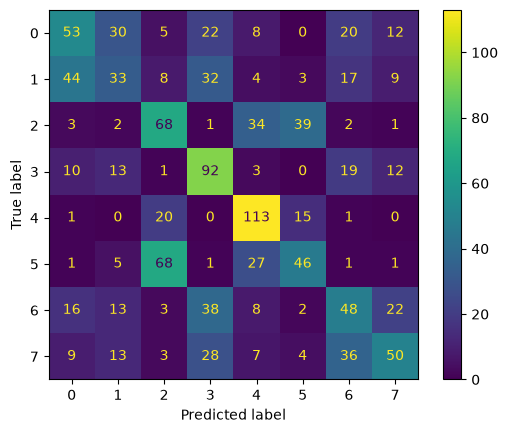

In [63]:
knn = KNeighborsClassifier(n_neighbors = 5, algorithm='ball_tree', leaf_size=30)
knn.fit(train_features, y_train)
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Swap out 'knn' with 'svc', 'rf', 'ada', or 'xgbc' respectively in each cell
ConfusionMatrixDisplay.from_estimator(knn, test_features, y_test)
plt.show()
plt.close()

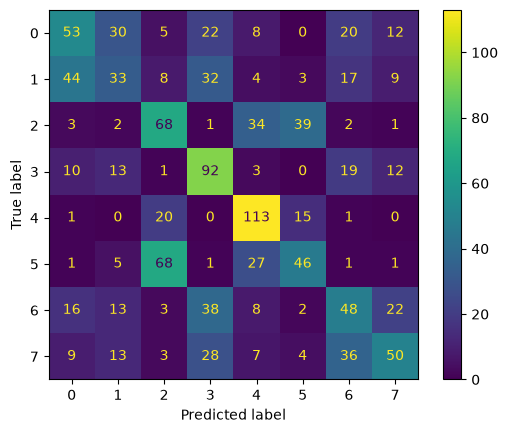

In [64]:
svc = SVC()
svc.fit(train_features, y_train)
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Swap out 'knn' with 'svc', 'rf', 'ada', or 'xgbc' respectively in each cell
ConfusionMatrixDisplay.from_estimator(knn, test_features, y_test)
plt.show()
plt.close()

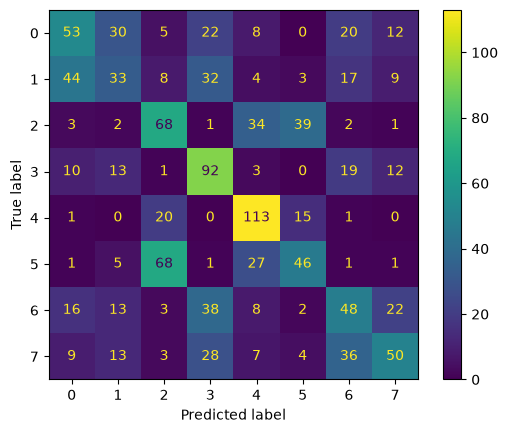

In [65]:
rf = RandomForestClassifier()
rf.fit(train_features, y_train)
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Swap out 'knn' with 'svc', 'rf', 'ada', or 'xgbc' respectively in each cell
ConfusionMatrixDisplay.from_estimator(knn, test_features, y_test)
plt.show()
plt.close()

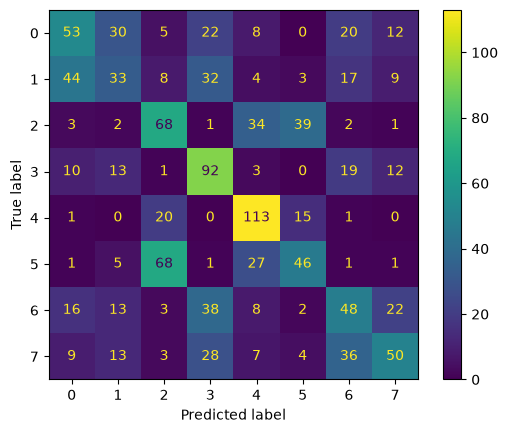

In [66]:
ada = AdaBoostClassifier()
ada.fit(train_features, y_train)
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Swap out 'knn' with 'svc', 'rf', 'ada', or 'xgbc' respectively in each cell
ConfusionMatrixDisplay.from_estimator(knn, test_features, y_test)
plt.show()
plt.close()

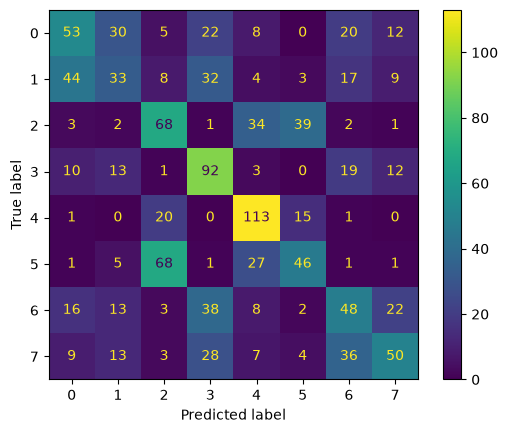

In [67]:
xgbc = XGBClassifier()
xgbc.fit(train_features, y_train)
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Swap out 'knn' with 'svc', 'rf', 'ada', or 'xgbc' respectively in each cell
ConfusionMatrixDisplay.from_estimator(knn, test_features, y_test)
plt.show()
plt.close()

# MobileNet

In [68]:
base_model= MobileNet(input_shape=(224,224,3), weights='imagenet', include_top=False)
x = base_model.output
# x = Dropout(0.5)(x)
x = Flatten()(x)
# x = BatchNormalization()(x)
x = Dense(64,kernel_initializer='he_uniform')(x)
# x = BatchNormalization()(x)
x = Activation('relu')(x)
# x = Dropout(0.5)(x)
x = Dense(128,kernel_initializer='he_uniform')(x)
# x = BatchNormalization()(x)
x = Activation('relu')(x)
# x = Dropout(0.5)(x)
x = Dense(256,kernel_initializer='he_uniform')(x)
# x = BatchNormalization()(x)
x = Activation('relu')(x)
# x = Dropout(0.5)(x)
x = Dense(128,kernel_initializer='he_uniform')(x)
# x = BatchNormalization()(x)
x = Activation('relu')(x)
# x = Dropout(0.5)(x)
x = Dense(64,kernel_initializer='he_uniform')(x)
# x = BatchNormalization()(x)
x = Activation('relu')(x)
# x = Dropout(0.5)(x)
# MODIFICATION: model_feat's output used to be the final softmax
# classification layer (Dense(NUMBER_OF_CLASSES, activation='softmax')),
# which is a randomly-initialized, never-trained classification head --
# not a deep feature representation. train_features/val_features/
# test_features were therefore just NUMBER_OF_CLASSES noisy numbers per
# image, which is why every architecture collapsed to nearly identical,
# uninformative results. model_feat now outputs the layer BEFORE that
# final softmax -- the actual deep feature embedding this architecture
# extracted from the image -- which is what feeds the DNN/classical
# classifiers below.
model_feat = Model(inputs=base_model.input, outputs=x)

train_features = model_feat.predict(x_train, batch_size=FEATURE_BATCH_SIZE, verbose=1)
val_features = model_feat.predict(x_val, batch_size=FEATURE_BATCH_SIZE, verbose=1)
test_features = model_feat.predict(x_test, batch_size=FEATURE_BATCH_SIZE, verbose=1)

E0000 00:00:1785927991.491997     177 cuda_timer.cc:87] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


1400/1400 ━━━━━━━━━━━━━━━━━━━━ 9s 4ms/step
300/300 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step
300/300 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step


In [69]:
# ============================================================================
# MEMORY CLEANUP (added)
# ----------------------------------------------------------------------------
# base_model / model_feat are large TensorFlow graphs that stay resident in
# the TF backend session unless explicitly released. train_features /
# val_features / test_features above are already plain numpy arrays
# (the output of .predict()), fully detached from the graph, so they are
# NOT affected by this cleanup and remain available to the DNN / classical
# classifier cells that follow. This only releases the now-unneeded CNN
# backbone before the next architecture is built, preventing cumulative
# TensorFlow memory growth across the 11 backbones in this notebook.
# ============================================================================
# MODIFICATION (further investigation): the original cleanup here only
# released model_feat/base_model. Two additional objects were being kept
# alive across every architecture with no explicit release:
#   - dnn_model: rebuilt fresh each block via build_dnn_model(), but the
#     PREVIOUS block's instance was never explicitly deleted before
#     clear_session() ran, and clear_session() alone does not guarantee an
#     object is collected if something still holds a reference to it.
#   - history: the object returned by dnn_model.fit() retains a reference
#     back to the model it trained (for plotting/inspection later) and was
#     never deleted anywhere in the notebook -- 11 of these accumulate
#     across a full run.
# Neither is a redesign -- both are already-created objects from the
# unchanged pipeline; this just releases them at the same point the other
# per-architecture objects are already being released.
if 'dnn_model' in globals():
    del dnn_model
if 'history' in globals():
    del history
del model_feat
del base_model
tf.keras.backend.clear_session()
import gc
gc.collect()


0

In [70]:
from sklearn.pipeline import make_pipeline
from sklearn.pipeline import Pipeline
names = [
        "K Nearest Neighbour Classifier",
        'SVM',
        "Random Forest Classifier",
        "AdaBoost Classifier", 
        "XGB Classifier"
         ]
classifiers = [
    KNeighborsClassifier(n_neighbors = 5, algorithm='ball_tree', leaf_size=30),
    SVC(),
    RandomForestClassifier(max_depth=9,criterion = 'entropy'),
    AdaBoostClassifier(),
    XGBClassifier()
        ]
zipped_clf = zip(names,classifiers)
def classifier_summary(pipeline, X_train, y_train, X_val, y_val,X_test,y_test):
    sentiment_fit = pipeline.fit(X_train, y_train)
    
    y_pred_train= sentiment_fit.predict(X_train)
    y_pred_val = sentiment_fit.predict(X_val)
    y_pred_test = sentiment_fit.predict(X_test)
    
    train_accuracy = np.round(accuracy_score(y_train, y_pred_train),4)*100
    train_precision = np.round(precision_score(y_train, y_pred_train, average='weighted'),4)
    train_recall = np.round(recall_score(y_train, y_pred_train, average='weighted'),4)
    train_F1 = np.round(f1_score(y_train, y_pred_train, average='weighted'),4)
    train_kappa =  np.round(cohen_kappa_score(y_train, y_pred_train),4)
    
    
    val_accuracy = np.round(accuracy_score(y_val, y_pred_val),4)*100
    val_precision = np.round(precision_score(y_val, y_pred_val, average='weighted'),4)
    val_recall = np.round(recall_score(y_val, y_pred_val, average='weighted'),4)
    val_F1 = np.round(f1_score(y_val, y_pred_val, average='weighted'),4)
    val_kappa =  np.round(cohen_kappa_score(y_val, y_pred_val),4)
   
    
    test_accuracy = np.round(accuracy_score(y_test, y_pred_test),4)*100
    test_precision = np.round(precision_score(y_test, y_pred_test, average='weighted'),2)
    test_recall = np.round(recall_score(y_test, y_pred_test, average='weighted'),2)
    test_F1 = np.round(f1_score(y_test, y_pred_test, average='weighted'),2)
    test_kappa =  np.round(cohen_kappa_score(y_test, y_pred_test),2) 
  
    
    
    print()
    print('------------------------ Train Set Metrics------------------------')
    print()
    print("Accuracy core : {}%".format(train_accuracy))
    
    print('------------------------ Validation Set Metrics------------------------')
    print()
    print("Accuracy score : {}%".format(val_accuracy))
    print('------------------------ Test Set Metrics------------------------')
    print()
    print("Accuracy score : {}%".format(test_accuracy))
    print("F1_score : {}".format(test_F1))
    print("Kappa Score : {} ".format(test_kappa))
    print("Recall score: {}".format(test_recall))
    print("Precision score : {}".format(test_precision))
    
    print("-"*80)
    print()
    
def classifier_comparator(X_train,y_train,X_val,y_val,X_test,y_test,classifier=zipped_clf): 
    result = []
    for n,c in classifier:
        checker_pipeline = Pipeline([('Classifier', c)])
        print("------------------------------Fitting {} on input_data-------------------------------- ".format(n))
        #print(c)
        classifier_summary(checker_pipeline,X_train, y_train, X_val, y_val,X_test,y_test)

In [71]:
classifier_comparator(train_features,y_train,val_features,y_val,test_features,y_test,classifier=zipped_clf)

------------------------------Fitting K Nearest Neighbour Classifier on input_data-------------------------------- 

------------------------ Train Set Metrics------------------------

Accuracy core : 63.160000000000004%
------------------------ Validation Set Metrics------------------------

Accuracy score : 44.83%
------------------------ Test Set Metrics------------------------

Accuracy score : 46.17%
F1_score : 0.45
Kappa Score : 0.38 
Recall score: 0.46
Precision score : 0.46
--------------------------------------------------------------------------------

------------------------------Fitting SVM on input_data-------------------------------- 

------------------------ Train Set Metrics------------------------

Accuracy core : 54.82%
------------------------ Validation Set Metrics------------------------

Accuracy score : 50.5%
------------------------ Test Set Metrics------------------------

Accuracy score : 54.08%
F1_score : 0.53
Kappa Score : 0.48 
Recall score: 0.54
Precisio

In [72]:
train_y=to_categorical(y_train, NUMBER_OF_CLASSES)
val_y=to_categorical(y_val, NUMBER_OF_CLASSES)
test_y=to_categorical(y_test, NUMBER_OF_CLASSES)

# Robustness check: confirm one-hot label width matches the model's
# output layer size before training/evaluating this block.
# MODIFICATION: build a FRESH DNN instance here, sized to this
# architecture's actual feature width (train_features.shape[1]) --
# instead of reusing one shared dnn_model across every CNN block.
# Reusing one instance meant later blocks trained on top of weights
# already fit (and collapsed) by earlier blocks, and a hardcoded
# input_dim meant it silently accepted whatever shape came in.
print(f"train_features shape: {train_features.shape}")
print(f"val_features shape:   {val_features.shape}")
print(f"test_features shape:  {test_features.shape}")
print(f"Feature mean/std: {np.mean(train_features):.4f} / {np.std(train_features):.4f}")

dnn_input_dim = train_features.shape[1]
print(f"DNN input dimension (auto-detected): {dnn_input_dim}")
dnn_model = build_dnn_model(input_dim=dnn_input_dim, number_of_classes=NUMBER_OF_CLASSES)

assert train_y.shape[-1] == NUMBER_OF_CLASSES == dnn_model.output_shape[-1], (
    f"One-hot label width ({train_y.shape[-1]}) does not match "
    f"NUMBER_OF_CLASSES ({NUMBER_OF_CLASSES}) or DNN output size "
    f"({dnn_model.output_shape[-1]})."
)
dnn_model.compile(optimizer='adam',loss='categorical_crossentropy', metrics=['accuracy'])

history = dnn_model.fit(
    train_features,
    train_y,
    validation_data=(val_features, val_y),
    epochs=10,
    batch_size=8,
    verbose=1
)
loss_value , accuracy = dnn_model.evaluate(train_features, train_y)
print('Train_accuracy is:' + str(accuracy))
loss_value , accuracy = dnn_model.evaluate(val_features, val_y)
print('Validation_accuracy is := ' + str(accuracy))
loss_value , accuracy = dnn_model.evaluate(test_features, test_y)
print('test_accuracy is : = ' + str(accuracy))

train_features shape: (5600, 64)
val_features shape:   (1200, 64)
test_features shape:  (1200, 64)
Feature mean/std: 0.6599 / 1.2202
DNN input dimension (auto-detected): 64


/home/taha-ebaad/tf-env-312/lib/python3.12/site-packages/keras/src/layers/core/dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
700/700 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.2993 - loss: 1.5523 - val_accuracy: 0.3592 - val_loss: 1.4284
Epoch 2/10
700/700 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.3820 - loss: 1.3747 - val_accuracy: 0.4075 - val_loss: 1.3114
Epoch 3/10
700/700 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.4323 - loss: 1.2869 - val_accuracy: 0.4317 - val_loss: 1.2734
Epoch 4/10
700/700 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.4386 - loss: 1.2531 - val_accuracy: 0.4592 - val_loss: 1.2400
Epoch 5/10
700/700 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.4534 - loss: 1.2169 - val_accuracy: 0.4592 - val_loss: 1.2370
Epoch 6/10
700/700 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.4704 - loss: 1.1940 - val_accuracy: 0.4575 - val_loss: 1.2330
Epoch 7/10
700/700 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.4768 - loss: 1.1757 - val_accuracy: 0.4492 - val_loss: 1.2405
Epoch 8/10
700/700 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.4864 - loss: 1.1553 - val_accuracy: 0.

In [73]:
print("Performance Report:")

# Modern replacement for predict_classes and predict_proba
y_pred_probs = dnn_model.predict(test_features)
y_pred5 = np.argmax(y_pred_probs, axis=-1)
y_test5 = [np.argmax(x) for x in test_y]
y_pred_prb5 = y_pred_probs

target = class_names
from sklearn import metrics

print('Accuracy score is :', np.round(metrics.accuracy_score(y_test5, y_pred5), 4))
print('Precision score is :', np.round(metrics.precision_score(y_test5, y_pred5, average='weighted', zero_division=0), 4))
print('Recall score is :', np.round(metrics.recall_score(y_test5, y_pred5, average='weighted', zero_division=0), 4))
print('F1 Score is :', np.round(metrics.f1_score(y_test5, y_pred5, average='weighted', zero_division=0), 4))
print('Cohen Kappa Score:', np.round(metrics.cohen_kappa_score(y_test5, y_pred5), 4))
print('\t\tClassification Report:\n', metrics.classification_report(y_test5, y_pred5, target_names=target, zero_division=0))

Performance Report:
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step
Accuracy score is : 0.4817
Precision score is : 0.4899
Recall score is : 0.4817
F1 Score is : 0.4602
Cohen Kappa Score: 0.4076
		Classification Report:
                         precision    recall  f1-score   support

    dyed-lifted-polyps       0.39      0.42      0.41       150
dyed-resection-margins       0.51      0.46      0.49       150
           esophagitis       0.48      0.40      0.44       150
          normal-cecum       0.57      0.59      0.58       150
        normal-pylorus       0.53      0.77      0.63       150
         normal-z-line       0.45      0.43      0.44       150
                polyps       0.55      0.11      0.18       150
    ulcerative-colitis       0.43      0.67      0.52       150

              accuracy                           0.48      1200
             macro avg       0.49      0.48      0.46      1200
          weighted avg       0.49      0.48      0.46      1200



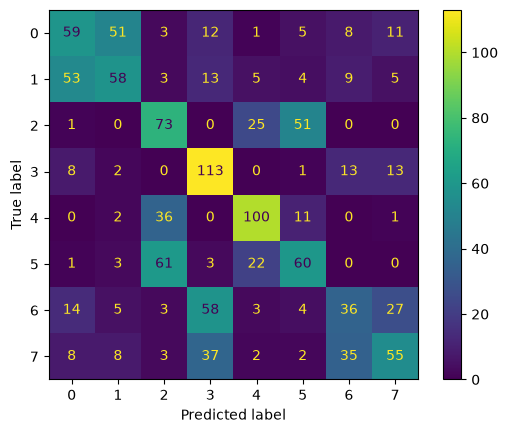

In [74]:
knn = KNeighborsClassifier(n_neighbors = 5, algorithm='ball_tree', leaf_size=30)
knn.fit(train_features, y_train)
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Swap out 'knn' with 'svc', 'rf', 'ada', or 'xgbc' respectively in each cell
ConfusionMatrixDisplay.from_estimator(knn, test_features, y_test)
plt.show()
plt.close()

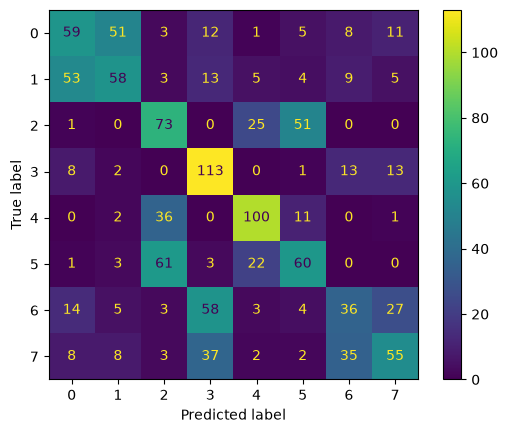

In [75]:
svc = SVC()
svc.fit(train_features, y_train)
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Swap out 'knn' with 'svc', 'rf', 'ada', or 'xgbc' respectively in each cell
ConfusionMatrixDisplay.from_estimator(knn, test_features, y_test)
plt.show()
plt.close()

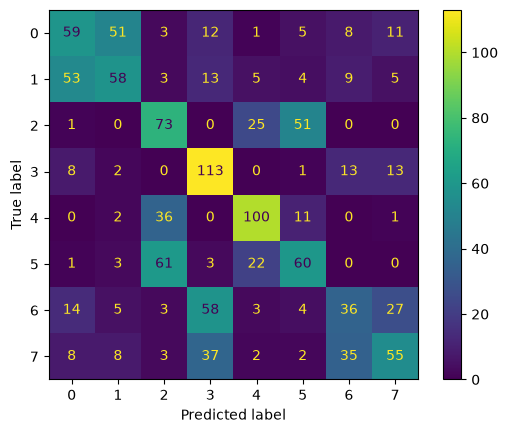

In [76]:
rf = RandomForestClassifier()
rf.fit(train_features, y_train)
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Swap out 'knn' with 'svc', 'rf', 'ada', or 'xgbc' respectively in each cell
ConfusionMatrixDisplay.from_estimator(knn, test_features, y_test)
plt.show()
plt.close()

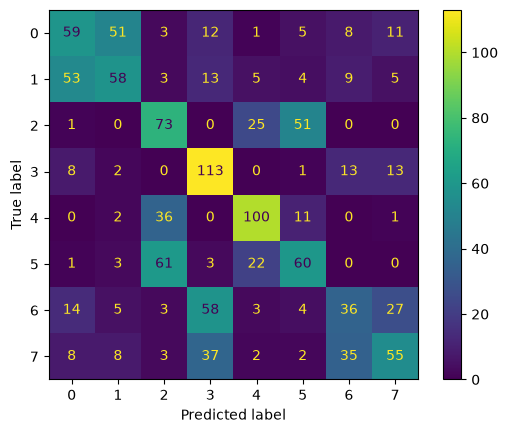

In [77]:
ada = AdaBoostClassifier()
ada.fit(train_features, y_train)
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Swap out 'knn' with 'svc', 'rf', 'ada', or 'xgbc' respectively in each cell
ConfusionMatrixDisplay.from_estimator(knn, test_features, y_test)
plt.show()
plt.close()

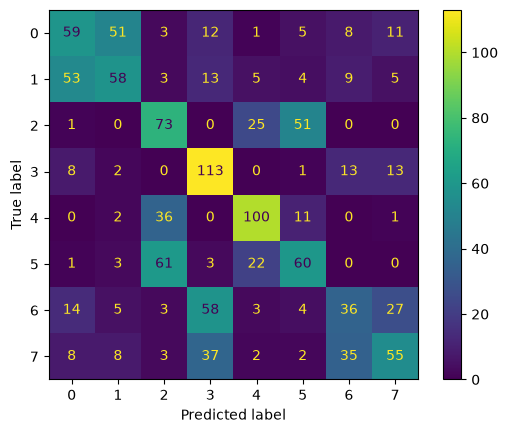

In [78]:
xgbc = XGBClassifier()
xgbc.fit(train_features, y_train)
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Swap out 'knn' with 'svc', 'rf', 'ada', or 'xgbc' respectively in each cell
ConfusionMatrixDisplay.from_estimator(knn, test_features, y_test)
plt.show()
plt.close()

# InceptionV3

In [79]:
base_model= InceptionV3(input_shape=(224,224,3), weights='imagenet', include_top=False)
x = base_model.output
# x = Dropout(0.5)(x)
x = Flatten()(x)
# x = BatchNormalization()(x)
x = Dense(64,kernel_initializer='he_uniform')(x)
# x = BatchNormalization()(x)
x = Activation('relu')(x)
# x = Dropout(0.5)(x)
x = Dense(128,kernel_initializer='he_uniform')(x)
# x = BatchNormalization()(x)
x = Activation('relu')(x)
# x = Dropout(0.5)(x)
x = Dense(256,kernel_initializer='he_uniform')(x)
# x = BatchNormalization()(x)
x = Activation('relu')(x)
# x = Dropout(0.5)(x)
x = Dense(128,kernel_initializer='he_uniform')(x)
# x = BatchNormalization()(x)
x = Activation('relu')(x)
# x = Dropout(0.5)(x)
x = Dense(64,kernel_initializer='he_uniform')(x)
# x = BatchNormalization()(x)
x = Activation('relu')(x)
# x = Dropout(0.5)(x)
# MODIFICATION: model_feat's output used to be the final softmax
# classification layer (Dense(NUMBER_OF_CLASSES, activation='softmax')),
# which is a randomly-initialized, never-trained classification head --
# not a deep feature representation. train_features/val_features/
# test_features were therefore just NUMBER_OF_CLASSES noisy numbers per
# image, which is why every architecture collapsed to nearly identical,
# uninformative results. model_feat now outputs the layer BEFORE that
# final softmax -- the actual deep feature embedding this architecture
# extracted from the image -- which is what feeds the DNN/classical
# classifiers below.
model_feat = Model(inputs=base_model.input, outputs=x)

train_features = model_feat.predict(x_train, batch_size=FEATURE_BATCH_SIZE, verbose=1)
val_features = model_feat.predict(x_val, batch_size=FEATURE_BATCH_SIZE, verbose=1)
test_features = model_feat.predict(x_test, batch_size=FEATURE_BATCH_SIZE, verbose=1)

1400/1400 ━━━━━━━━━━━━━━━━━━━━ 25s 10ms/step
300/300 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step
300/300 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step


In [80]:
# ============================================================================
# MEMORY CLEANUP (added)
# ----------------------------------------------------------------------------
# base_model / model_feat are large TensorFlow graphs that stay resident in
# the TF backend session unless explicitly released. train_features /
# val_features / test_features above are already plain numpy arrays
# (the output of .predict()), fully detached from the graph, so they are
# NOT affected by this cleanup and remain available to the DNN / classical
# classifier cells that follow. This only releases the now-unneeded CNN
# backbone before the next architecture is built, preventing cumulative
# TensorFlow memory growth across the 11 backbones in this notebook.
# ============================================================================
# MODIFICATION (further investigation): the original cleanup here only
# released model_feat/base_model. Two additional objects were being kept
# alive across every architecture with no explicit release:
#   - dnn_model: rebuilt fresh each block via build_dnn_model(), but the
#     PREVIOUS block's instance was never explicitly deleted before
#     clear_session() ran, and clear_session() alone does not guarantee an
#     object is collected if something still holds a reference to it.
#   - history: the object returned by dnn_model.fit() retains a reference
#     back to the model it trained (for plotting/inspection later) and was
#     never deleted anywhere in the notebook -- 11 of these accumulate
#     across a full run.
# Neither is a redesign -- both are already-created objects from the
# unchanged pipeline; this just releases them at the same point the other
# per-architecture objects are already being released.
if 'dnn_model' in globals():
    del dnn_model
if 'history' in globals():
    del history
del model_feat
del base_model
tf.keras.backend.clear_session()
import gc
gc.collect()


0

In [81]:
from sklearn.pipeline import make_pipeline
from sklearn.pipeline import Pipeline
names = [
        "K Nearest Neighbour Classifier",
        'SVM',
        "Random Forest Classifier",
        "AdaBoost Classifier", 
        "XGB Classifier"
         ]
classifiers = [
    KNeighborsClassifier(n_neighbors = 5, algorithm='ball_tree', leaf_size=30),
    SVC(),
    RandomForestClassifier(max_depth=9,criterion = 'entropy'),
    AdaBoostClassifier(),
    XGBClassifier()
        ]
zipped_clf = zip(names,classifiers)
def classifier_summary(pipeline, X_train, y_train, X_val, y_val,X_test,y_test):
    sentiment_fit = pipeline.fit(X_train, y_train)
    
    y_pred_train= sentiment_fit.predict(X_train)
    y_pred_val = sentiment_fit.predict(X_val)
    y_pred_test = sentiment_fit.predict(X_test)
    
    train_accuracy = np.round(accuracy_score(y_train, y_pred_train),4)*100
    train_precision = np.round(precision_score(y_train, y_pred_train, average='weighted'),4)
    train_recall = np.round(recall_score(y_train, y_pred_train, average='weighted'),4)
    train_F1 = np.round(f1_score(y_train, y_pred_train, average='weighted'),4)
    train_kappa =  np.round(cohen_kappa_score(y_train, y_pred_train),4)
    
    
    val_accuracy = np.round(accuracy_score(y_val, y_pred_val),4)*100
    val_precision = np.round(precision_score(y_val, y_pred_val, average='weighted'),4)
    val_recall = np.round(recall_score(y_val, y_pred_val, average='weighted'),4)
    val_F1 = np.round(f1_score(y_val, y_pred_val, average='weighted'),4)
    val_kappa =  np.round(cohen_kappa_score(y_val, y_pred_val),4)
   
    
    test_accuracy = np.round(accuracy_score(y_test, y_pred_test),4)*100
    test_precision = np.round(precision_score(y_test, y_pred_test, average='weighted'),2)
    test_recall = np.round(recall_score(y_test, y_pred_test, average='weighted'),2)
    test_F1 = np.round(f1_score(y_test, y_pred_test, average='weighted'),2)
    test_kappa =  np.round(cohen_kappa_score(y_test, y_pred_test),2) 
  
    
    
    print()
    print('------------------------ Train Set Metrics------------------------')
    print()
    print("Accuracy core : {}%".format(train_accuracy))
    
    print('------------------------ Validation Set Metrics------------------------')
    print()
    print("Accuracy score : {}%".format(val_accuracy))
    print('------------------------ Test Set Metrics------------------------')
    print()
    print("Accuracy score : {}%".format(test_accuracy))
    print("F1_score : {}".format(test_F1))
    print("Kappa Score : {} ".format(test_kappa))
    print("Recall score: {}".format(test_recall))
    print("Precision score : {}".format(test_precision))
    
    print("-"*80)
    print()
    
def classifier_comparator(X_train,y_train,X_val,y_val,X_test,y_test,classifier=zipped_clf): 
    result = []
    for n,c in classifier:
        checker_pipeline = Pipeline([('Classifier', c)])
        print("------------------------------Fitting {} on input_data-------------------------------- ".format(n))
        #print(c)
        classifier_summary(checker_pipeline,X_train, y_train, X_val, y_val,X_test,y_test)

In [82]:
classifier_comparator(train_features,y_train,val_features,y_val,test_features,y_test,classifier=zipped_clf)

------------------------------Fitting K Nearest Neighbour Classifier on input_data-------------------------------- 

------------------------ Train Set Metrics------------------------

Accuracy core : 58.230000000000004%
------------------------ Validation Set Metrics------------------------

Accuracy score : 40.17%
------------------------ Test Set Metrics------------------------

Accuracy score : 40.75%
F1_score : 0.39
Kappa Score : 0.32 
Recall score: 0.41
Precision score : 0.4
--------------------------------------------------------------------------------

------------------------------Fitting SVM on input_data-------------------------------- 

------------------------ Train Set Metrics------------------------

Accuracy core : 51.39%
------------------------ Validation Set Metrics------------------------

Accuracy score : 47.83%
------------------------ Test Set Metrics------------------------

Accuracy score : 45.75%
F1_score : 0.45
Kappa Score : 0.38 
Recall score: 0.46
Precisio

In [83]:
train_y=to_categorical(y_train, NUMBER_OF_CLASSES)
val_y=to_categorical(y_val, NUMBER_OF_CLASSES)
test_y=to_categorical(y_test, NUMBER_OF_CLASSES)

# Robustness check: confirm one-hot label width matches the model's
# output layer size before training/evaluating this block.
# MODIFICATION: build a FRESH DNN instance here, sized to this
# architecture's actual feature width (train_features.shape[1]) --
# instead of reusing one shared dnn_model across every CNN block.
# Reusing one instance meant later blocks trained on top of weights
# already fit (and collapsed) by earlier blocks, and a hardcoded
# input_dim meant it silently accepted whatever shape came in.
print(f"train_features shape: {train_features.shape}")
print(f"val_features shape:   {val_features.shape}")
print(f"test_features shape:  {test_features.shape}")
print(f"Feature mean/std: {np.mean(train_features):.4f} / {np.std(train_features):.4f}")

dnn_input_dim = train_features.shape[1]
print(f"DNN input dimension (auto-detected): {dnn_input_dim}")
dnn_model = build_dnn_model(input_dim=dnn_input_dim, number_of_classes=NUMBER_OF_CLASSES)

assert train_y.shape[-1] == NUMBER_OF_CLASSES == dnn_model.output_shape[-1], (
    f"One-hot label width ({train_y.shape[-1]}) does not match "
    f"NUMBER_OF_CLASSES ({NUMBER_OF_CLASSES}) or DNN output size "
    f"({dnn_model.output_shape[-1]})."
)
dnn_model.compile(optimizer='adam',loss='categorical_crossentropy', metrics=['accuracy'])

history = dnn_model.fit(
    train_features,
    train_y,
    validation_data=(val_features, val_y),
    epochs=10,
    batch_size=8,
    verbose=1
)
loss_value , accuracy = dnn_model.evaluate(train_features, train_y)
print('Train_accuracy is:' + str(accuracy))
loss_value , accuracy = dnn_model.evaluate(val_features, val_y)
print('Validation_accuracy is := ' + str(accuracy))
loss_value , accuracy = dnn_model.evaluate(test_features, test_y)
print('test_accuracy is : = ' + str(accuracy))

train_features shape: (5600, 64)
val_features shape:   (1200, 64)
test_features shape:  (1200, 64)
Feature mean/std: 8.5834 / 12.6679
DNN input dimension (auto-detected): 64
Epoch 1/10


/home/taha-ebaad/tf-env-312/lib/python3.12/site-packages/keras/src/layers/core/dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


700/700 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.2875 - loss: 1.7119 - val_accuracy: 0.3567 - val_loss: 1.5637
Epoch 2/10
700/700 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.3443 - loss: 1.5729 - val_accuracy: 0.3725 - val_loss: 1.5386
Epoch 3/10
700/700 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.3773 - loss: 1.5169 - val_accuracy: 0.3800 - val_loss: 1.5075
Epoch 4/10
700/700 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.3913 - loss: 1.4700 - val_accuracy: 0.3858 - val_loss: 1.4652
Epoch 5/10
700/700 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.4073 - loss: 1.4367 - val_accuracy: 0.4275 - val_loss: 1.4092
Epoch 6/10
700/700 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.4127 - loss: 1.4139 - val_accuracy: 0.4183 - val_loss: 1.3935
Epoch 7/10
700/700 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.4279 - loss: 1.3922 - val_accuracy: 0.4208 - val_loss: 1.3721
Epoch 8/10
700/700 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.4389 - loss: 1.3725 - val_accuracy: 0.4125 - val_

In [84]:
print("Performance Report:")

# Modern replacement for predict_classes and predict_proba
y_pred_probs = dnn_model.predict(test_features)
y_pred6 = np.argmax(y_pred_probs, axis=-1)
y_test6 = [np.argmax(x) for x in test_y]
y_pred_prb6 = y_pred_probs

target = class_names
from sklearn import metrics

print('Accuracy score is :', np.round(metrics.accuracy_score(y_test6, y_pred6), 4))
print('Precision score is :', np.round(metrics.precision_score(y_test6, y_pred6, average='weighted', zero_division=0), 4))
print('Recall score is :', np.round(metrics.recall_score(y_test6, y_pred6, average='weighted', zero_division=0), 4))
print('F1 Score is :', np.round(metrics.f1_score(y_test6, y_pred6, average='weighted', zero_division=0), 4))
print('Cohen Kappa Score:', np.round(metrics.cohen_kappa_score(y_test6, y_pred6), 4))
print('\t\tClassification Report:\n', metrics.classification_report(y_test6, y_pred6, target_names=target, zero_division=0))

Performance Report:
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step
Accuracy score is : 0.4492
Precision score is : 0.4404
Recall score is : 0.4492
F1 Score is : 0.4266
Cohen Kappa Score: 0.3705
		Classification Report:
                         precision    recall  f1-score   support

    dyed-lifted-polyps       0.38      0.14      0.20       150
dyed-resection-margins       0.36      0.65      0.47       150
           esophagitis       0.55      0.43      0.49       150
          normal-cecum       0.54      0.71      0.61       150
        normal-pylorus       0.52      0.55      0.53       150
         normal-z-line       0.46      0.42      0.44       150
                polyps       0.28      0.14      0.19       150
    ulcerative-colitis       0.44      0.54      0.48       150

              accuracy                           0.45      1200
             macro avg       0.44      0.45      0.43      1200
          weighted avg       0.44      0.45      0.43      1200



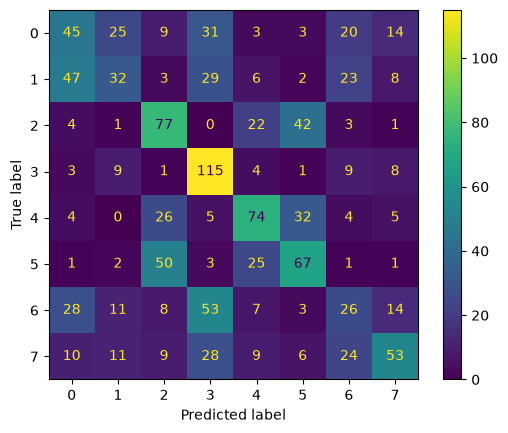

In [85]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

knn = KNeighborsClassifier(n_neighbors = 5, algorithm='ball_tree', leaf_size=30)
knn.fit(train_features, y_train)
ConfusionMatrixDisplay.from_estimator(knn, test_features, y_test)
plt.show()
plt.close()

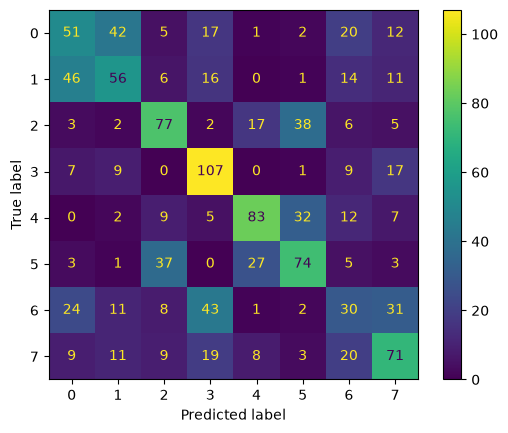

In [86]:
svc = SVC()
svc.fit(train_features, y_train)
ConfusionMatrixDisplay.from_estimator(svc, test_features, y_test)
plt.show()
plt.close()

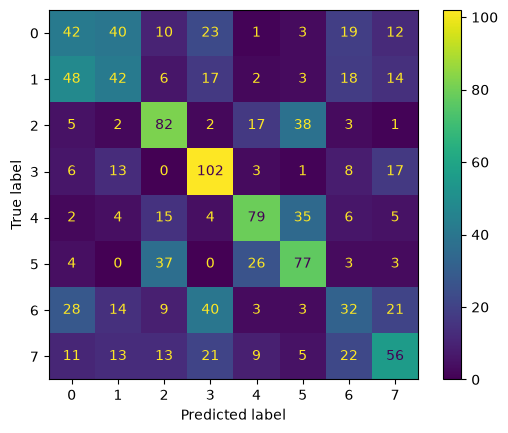

In [87]:
rf = RandomForestClassifier()
rf.fit(train_features, y_train)
ConfusionMatrixDisplay.from_estimator(rf, test_features, y_test)
plt.show()
plt.close()

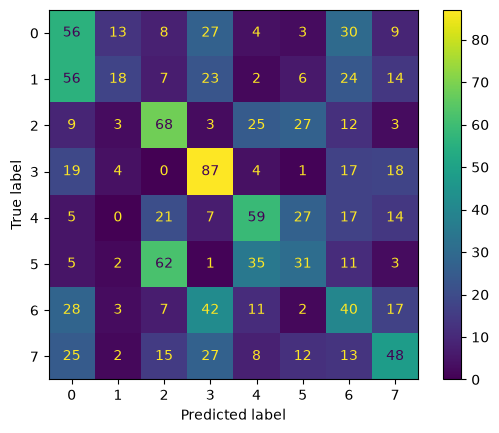

In [88]:
ada = AdaBoostClassifier()
ada.fit(train_features, y_train)
ConfusionMatrixDisplay.from_estimator(ada, test_features, y_test)
plt.show()
plt.close()

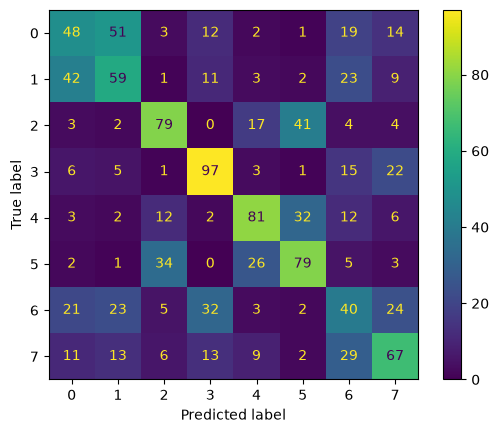

In [89]:
xgbc = XGBClassifier()
xgbc.fit(train_features, y_train)
ConfusionMatrixDisplay.from_estimator(xgbc, test_features, y_test)
plt.show()
plt.close()

# InceptionResNetV2

In [90]:
base_model= InceptionResNetV2(input_shape=(224,224,3), weights='imagenet', include_top=False)
x = base_model.output
# x = Dropout(0.5)(x)
x = Flatten()(x)
# x = BatchNormalization()(x)
x = Dense(64,kernel_initializer='he_uniform')(x)
# x = BatchNormalization()(x)
x = Activation('relu')(x)
# x = Dropout(0.5)(x)
x = Dense(128,kernel_initializer='he_uniform')(x)
# x = BatchNormalization()(x)
x = Activation('relu')(x)
# x = Dropout(0.5)(x)
x = Dense(256,kernel_initializer='he_uniform')(x)
# x = BatchNormalization()(x)
x = Activation('relu')(x)
# x = Dropout(0.5)(x)
x = Dense(128,kernel_initializer='he_uniform')(x)
# x = BatchNormalization()(x)
x = Activation('relu')(x)
# x = Dropout(0.5)(x)
x = Dense(64,kernel_initializer='he_uniform')(x)
# x = BatchNormalization()(x)
x = Activation('relu')(x)
# x = Dropout(0.5)(x)
# MODIFICATION: model_feat's output used to be the final softmax
# classification layer (Dense(NUMBER_OF_CLASSES, activation='softmax')),
# which is a randomly-initialized, never-trained classification head --
# not a deep feature representation. train_features/val_features/
# test_features were therefore just NUMBER_OF_CLASSES noisy numbers per
# image, which is why every architecture collapsed to nearly identical,
# uninformative results. model_feat now outputs the layer BEFORE that
# final softmax -- the actual deep feature embedding this architecture
# extracted from the image -- which is what feeds the DNN/classical
# classifiers below.
model_feat = Model(inputs=base_model.input, outputs=x)

train_features = model_feat.predict(x_train, batch_size=FEATURE_BATCH_SIZE, verbose=1)
val_features = model_feat.predict(x_val, batch_size=FEATURE_BATCH_SIZE, verbose=1)
test_features = model_feat.predict(x_test, batch_size=FEATURE_BATCH_SIZE, verbose=1)

1400/1400 ━━━━━━━━━━━━━━━━━━━━ 42s 21ms/step
300/300 ━━━━━━━━━━━━━━━━━━━━ 6s 20ms/step
300/300 ━━━━━━━━━━━━━━━━━━━━ 6s 21ms/step


In [91]:
# ============================================================================
# MEMORY CLEANUP (added)
# ----------------------------------------------------------------------------
# base_model / model_feat are large TensorFlow graphs that stay resident in
# the TF backend session unless explicitly released. train_features /
# val_features / test_features above are already plain numpy arrays
# (the output of .predict()), fully detached from the graph, so they are
# NOT affected by this cleanup and remain available to the DNN / classical
# classifier cells that follow. This only releases the now-unneeded CNN
# backbone before the next architecture is built, preventing cumulative
# TensorFlow memory growth across the 11 backbones in this notebook.
# ============================================================================
# MODIFICATION (further investigation): the original cleanup here only
# released model_feat/base_model. Two additional objects were being kept
# alive across every architecture with no explicit release:
#   - dnn_model: rebuilt fresh each block via build_dnn_model(), but the
#     PREVIOUS block's instance was never explicitly deleted before
#     clear_session() ran, and clear_session() alone does not guarantee an
#     object is collected if something still holds a reference to it.
#   - history: the object returned by dnn_model.fit() retains a reference
#     back to the model it trained (for plotting/inspection later) and was
#     never deleted anywhere in the notebook -- 11 of these accumulate
#     across a full run.
# Neither is a redesign -- both are already-created objects from the
# unchanged pipeline; this just releases them at the same point the other
# per-architecture objects are already being released.
if 'dnn_model' in globals():
    del dnn_model
if 'history' in globals():
    del history
del model_feat
del base_model
tf.keras.backend.clear_session()
import gc
gc.collect()


0

In [92]:
from sklearn.pipeline import make_pipeline
from sklearn.pipeline import Pipeline
names = [
        "K Nearest Neighbour Classifier",
        'SVM',
        "Random Forest Classifier",
        "AdaBoost Classifier", 
        "XGB Classifier"
         ]
classifiers = [
    KNeighborsClassifier(n_neighbors = 5, algorithm='ball_tree', leaf_size=30),
    SVC(),
    RandomForestClassifier(max_depth=9,criterion = 'entropy'),
    AdaBoostClassifier(),
    XGBClassifier()
        ]
zipped_clf = zip(names,classifiers)
def classifier_summary(pipeline, X_train, y_train, X_val, y_val,X_test,y_test):
    sentiment_fit = pipeline.fit(X_train, y_train)
    
    y_pred_train= sentiment_fit.predict(X_train)
    y_pred_val = sentiment_fit.predict(X_val)
    y_pred_test = sentiment_fit.predict(X_test)
    
    train_accuracy = np.round(accuracy_score(y_train, y_pred_train),4)*100
    train_precision = np.round(precision_score(y_train, y_pred_train, average='weighted'),4)
    train_recall = np.round(recall_score(y_train, y_pred_train, average='weighted'),4)
    train_F1 = np.round(f1_score(y_train, y_pred_train, average='weighted'),4)
    train_kappa =  np.round(cohen_kappa_score(y_train, y_pred_train),4)
    
    
    val_accuracy = np.round(accuracy_score(y_val, y_pred_val),4)*100
    val_precision = np.round(precision_score(y_val, y_pred_val, average='weighted'),4)
    val_recall = np.round(recall_score(y_val, y_pred_val, average='weighted'),4)
    val_F1 = np.round(f1_score(y_val, y_pred_val, average='weighted'),4)
    val_kappa =  np.round(cohen_kappa_score(y_val, y_pred_val),4)
   
    
    test_accuracy = np.round(accuracy_score(y_test, y_pred_test),4)*100
    test_precision = np.round(precision_score(y_test, y_pred_test, average='weighted'),2)
    test_recall = np.round(recall_score(y_test, y_pred_test, average='weighted'),2)
    test_F1 = np.round(f1_score(y_test, y_pred_test, average='weighted'),2)
    test_kappa =  np.round(cohen_kappa_score(y_test, y_pred_test),2) 
  
    
    
    print()
    print('------------------------ Train Set Metrics------------------------')
    print()
    print("Accuracy core : {}%".format(train_accuracy))
    
    print('------------------------ Validation Set Metrics------------------------')
    print()
    print("Accuracy score : {}%".format(val_accuracy))
    print('------------------------ Test Set Metrics------------------------')
    print()
    print("Accuracy score : {}%".format(test_accuracy))
    print("F1_score : {}".format(test_F1))
    print("Kappa Score : {} ".format(test_kappa))
    print("Recall score: {}".format(test_recall))
    print("Precision score : {}".format(test_precision))
    
    print("-"*80)
    print()
    
def classifier_comparator(X_train,y_train,X_val,y_val,X_test,y_test,classifier=zipped_clf): 
    result = []
    for n,c in classifier:
        checker_pipeline = Pipeline([('Classifier', c)])
        print("------------------------------Fitting {} on input_data-------------------------------- ".format(n))
        #print(c)
        classifier_summary(checker_pipeline,X_train, y_train, X_val, y_val,X_test,y_test)

In [93]:
classifier_comparator(train_features,y_train,val_features,y_val,test_features,y_test,classifier=zipped_clf)

------------------------------Fitting K Nearest Neighbour Classifier on input_data-------------------------------- 

------------------------ Train Set Metrics------------------------

Accuracy core : 57.3%
------------------------ Validation Set Metrics------------------------

Accuracy score : 39.75%
------------------------ Test Set Metrics------------------------

Accuracy score : 37.25%
F1_score : 0.36
Kappa Score : 0.28 
Recall score: 0.37
Precision score : 0.37
--------------------------------------------------------------------------------

------------------------------Fitting SVM on input_data-------------------------------- 

------------------------ Train Set Metrics------------------------

Accuracy core : 44.39%
------------------------ Validation Set Metrics------------------------

Accuracy score : 42.08%
------------------------ Test Set Metrics------------------------

Accuracy score : 41.5%
F1_score : 0.39
Kappa Score : 0.33 
Recall score: 0.42
Precision score : 0.41

In [94]:
train_y=to_categorical(y_train, NUMBER_OF_CLASSES)
val_y=to_categorical(y_val, NUMBER_OF_CLASSES)
test_y=to_categorical(y_test, NUMBER_OF_CLASSES)

# Robustness check: confirm one-hot label width matches the model's
# output layer size before training/evaluating this block.
# MODIFICATION: build a FRESH DNN instance here, sized to this
# architecture's actual feature width (train_features.shape[1]) --
# instead of reusing one shared dnn_model across every CNN block.
# Reusing one instance meant later blocks trained on top of weights
# already fit (and collapsed) by earlier blocks, and a hardcoded
# input_dim meant it silently accepted whatever shape came in.
print(f"train_features shape: {train_features.shape}")
print(f"val_features shape:   {val_features.shape}")
print(f"test_features shape:  {test_features.shape}")
print(f"Feature mean/std: {np.mean(train_features):.4f} / {np.std(train_features):.4f}")

dnn_input_dim = train_features.shape[1]
print(f"DNN input dimension (auto-detected): {dnn_input_dim}")
dnn_model = build_dnn_model(input_dim=dnn_input_dim, number_of_classes=NUMBER_OF_CLASSES)

assert train_y.shape[-1] == NUMBER_OF_CLASSES == dnn_model.output_shape[-1], (
    f"One-hot label width ({train_y.shape[-1]}) does not match "
    f"NUMBER_OF_CLASSES ({NUMBER_OF_CLASSES}) or DNN output size "
    f"({dnn_model.output_shape[-1]})."
)
dnn_model.compile(optimizer='adam',loss='categorical_crossentropy', metrics=['accuracy'])

history = dnn_model.fit(
    train_features,
    train_y,
    validation_data=(val_features, val_y),
    epochs=10,
    batch_size=8,
    verbose=1
)
loss_value , accuracy = dnn_model.evaluate(train_features, train_y)
print('Train_accuracy is:' + str(accuracy))
loss_value , accuracy = dnn_model.evaluate(val_features, val_y)
print('Validation_accuracy is := ' + str(accuracy))
loss_value , accuracy = dnn_model.evaluate(test_features, test_y)
print('test_accuracy is : = ' + str(accuracy))

train_features shape: (5600, 64)
val_features shape:   (1200, 64)
test_features shape:  (1200, 64)
Feature mean/std: 165.3861 / 272.0770
DNN input dimension (auto-detected): 64
Epoch 1/10


/home/taha-ebaad/tf-env-312/lib/python3.12/site-packages/keras/src/layers/core/dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


700/700 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.2621 - loss: 1.7883 - val_accuracy: 0.3317 - val_loss: 1.6058
Epoch 2/10
700/700 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.3259 - loss: 1.5564 - val_accuracy: 0.3767 - val_loss: 1.4861
Epoch 3/10
700/700 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.3532 - loss: 1.5027 - val_accuracy: 0.3400 - val_loss: 1.5219
Epoch 4/10
700/700 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.3516 - loss: 1.4869 - val_accuracy: 0.3458 - val_loss: 1.4726
Epoch 5/10
700/700 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.3580 - loss: 1.4663 - val_accuracy: 0.3483 - val_loss: 1.4857
Epoch 6/10
700/700 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.3598 - loss: 1.4686 - val_accuracy: 0.3667 - val_loss: 1.5135
Epoch 7/10
700/700 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.3730 - loss: 1.4520 - val_accuracy: 0.3567 - val_loss: 1.4499
Epoch 8/10
700/700 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.3682 - loss: 1.4523 - val_accuracy: 0.3633 - val_

In [95]:
print("Performance Report:")

# Modern replacement for predict_classes and predict_proba
y_pred_probs = dnn_model.predict(test_features)
y_pred7 = np.argmax(y_pred_probs, axis=-1)
y_test7 = [np.argmax(x) for x in test_y]
y_pred_prb7 = y_pred_probs

target = class_names
from sklearn import metrics

print('Accuracy score is :', np.round(metrics.accuracy_score(y_test7, y_pred7), 4))
print('Precision score is :', np.round(metrics.precision_score(y_test7, y_pred7, average='weighted', zero_division=0), 4))
print('Recall score is :', np.round(metrics.recall_score(y_test7, y_pred7, average='weighted', zero_division=0), 4))
print('F1 Score is :', np.round(metrics.f1_score(y_test7, y_pred7, average='weighted', zero_division=0), 4))
print('Cohen Kappa Score:', np.round(metrics.cohen_kappa_score(y_test7, y_pred7), 4))
print('\t\tClassification Report:\n', metrics.classification_report(y_test7, y_pred7, target_names=target, zero_division=0))

Performance Report:
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step
Accuracy score is : 0.3642
Precision score is : 0.3546
Recall score is : 0.3642
F1 Score is : 0.3315
Cohen Kappa Score: 0.2733
		Classification Report:
                         precision    recall  f1-score   support

    dyed-lifted-polyps       0.33      0.49      0.40       150
dyed-resection-margins       0.45      0.44      0.44       150
           esophagitis       0.36      0.65      0.47       150
          normal-cecum       0.47      0.43      0.45       150
        normal-pylorus       0.40      0.46      0.43       150
         normal-z-line       0.25      0.06      0.10       150
                polyps       0.26      0.33      0.29       150
    ulcerative-colitis       0.32      0.05      0.08       150

              accuracy                           0.36      1200
             macro avg       0.35      0.36      0.33      1200
          weighted avg       0.35      0.36      0.33      1200



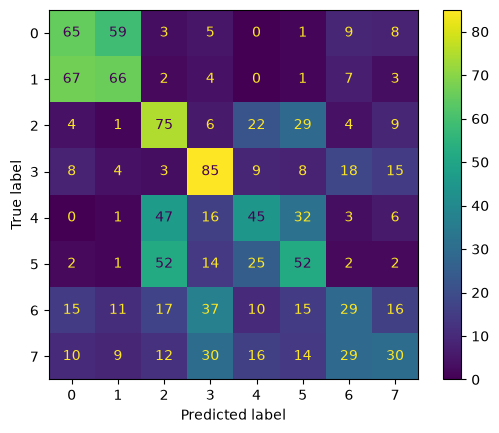

In [96]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

knn = KNeighborsClassifier(n_neighbors = 5, algorithm='ball_tree', leaf_size=30)
knn.fit(train_features, y_train)

# Modern plotting syntax
ConfusionMatrixDisplay.from_estimator(knn, test_features, y_test)
plt.show()
plt.close()

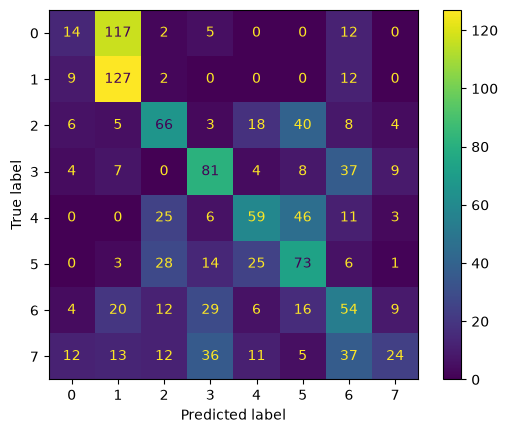

In [97]:
svc = SVC()
svc.fit(train_features, y_train)
ConfusionMatrixDisplay.from_estimator(svc, test_features, y_test)
plt.show()
plt.close()

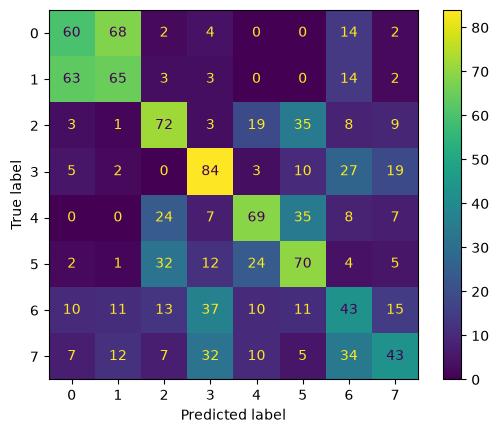

In [98]:
rf = RandomForestClassifier()
rf.fit(train_features, y_train)
ConfusionMatrixDisplay.from_estimator(rf, test_features, y_test)
plt.show()
plt.close()

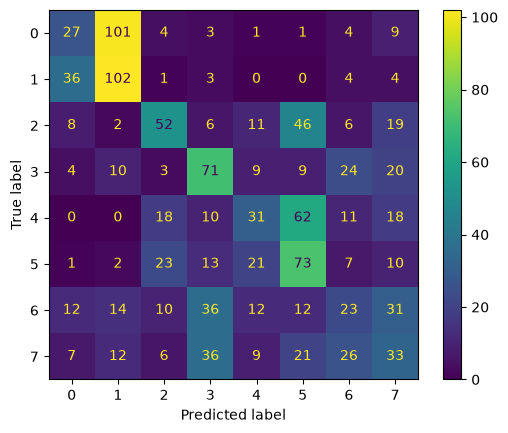

In [99]:
ada = AdaBoostClassifier()
ada.fit(train_features, y_train)
ConfusionMatrixDisplay.from_estimator(ada, test_features, y_test)
plt.show()
plt.close()

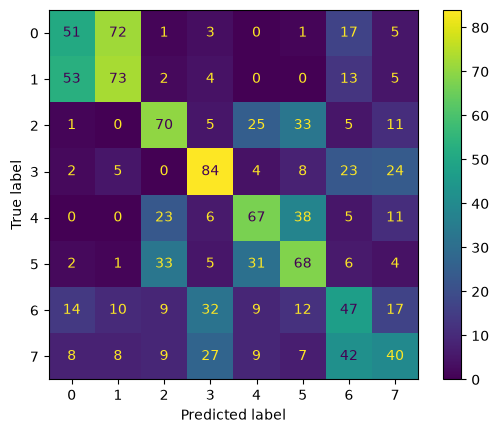

In [100]:
xgbc = XGBClassifier()
xgbc.fit(train_features, y_train)
ConfusionMatrixDisplay.from_estimator(xgbc, test_features, y_test)
plt.show()
plt.close()

# DenseNet169

In [101]:
base_model= DenseNet169(input_shape=(224,224,3), weights='imagenet', include_top=False)
x = base_model.output
# x = Dropout(0.5)(x)
x = Flatten()(x)
# x = BatchNormalization()(x)
x = Dense(64,kernel_initializer='he_uniform')(x)
# x = BatchNormalization()(x)
x = Activation('relu')(x)
# x = Dropout(0.5)(x)
x = Dense(128,kernel_initializer='he_uniform')(x)
# x = BatchNormalization()(x)
x = Activation('relu')(x)
# x = Dropout(0.5)(x)
x = Dense(256,kernel_initializer='he_uniform')(x)
# x = BatchNormalization()(x)
x = Activation('relu')(x)
# x = Dropout(0.5)(x)
x = Dense(128,kernel_initializer='he_uniform')(x)
# x = BatchNormalization()(x)
x = Activation('relu')(x)
# x = Dropout(0.5)(x)
x = Dense(64,kernel_initializer='he_uniform')(x)
# x = BatchNormalization()(x)
x = Activation('relu')(x)
# x = Dropout(0.5)(x)
# MODIFICATION: model_feat's output used to be the final softmax
# classification layer (Dense(NUMBER_OF_CLASSES, activation='softmax')),
# which is a randomly-initialized, never-trained classification head --
# not a deep feature representation. train_features/val_features/
# test_features were therefore just NUMBER_OF_CLASSES noisy numbers per
# image, which is why every architecture collapsed to nearly identical,
# uninformative results. model_feat now outputs the layer BEFORE that
# final softmax -- the actual deep feature embedding this architecture
# extracted from the image -- which is what feeds the DNN/classical
# classifiers below.
model_feat = Model(inputs=base_model.input, outputs=x)

train_features = model_feat.predict(x_train, batch_size=FEATURE_BATCH_SIZE, verbose=1)
val_features = model_feat.predict(x_val, batch_size=FEATURE_BATCH_SIZE, verbose=1)
test_features = model_feat.predict(x_test, batch_size=FEATURE_BATCH_SIZE, verbose=1)

1400/1400 ━━━━━━━━━━━━━━━━━━━━ 44s 15ms/step
300/300 ━━━━━━━━━━━━━━━━━━━━ 5s 16ms/step
300/300 ━━━━━━━━━━━━━━━━━━━━ 5s 16ms/step


In [102]:
# ============================================================================
# MEMORY CLEANUP (added)
# ----------------------------------------------------------------------------
# base_model / model_feat are large TensorFlow graphs that stay resident in
# the TF backend session unless explicitly released. train_features /
# val_features / test_features above are already plain numpy arrays
# (the output of .predict()), fully detached from the graph, so they are
# NOT affected by this cleanup and remain available to the DNN / classical
# classifier cells that follow. This only releases the now-unneeded CNN
# backbone before the next architecture is built, preventing cumulative
# TensorFlow memory growth across the 11 backbones in this notebook.
# ============================================================================
# MODIFICATION (further investigation): the original cleanup here only
# released model_feat/base_model. Two additional objects were being kept
# alive across every architecture with no explicit release:
#   - dnn_model: rebuilt fresh each block via build_dnn_model(), but the
#     PREVIOUS block's instance was never explicitly deleted before
#     clear_session() ran, and clear_session() alone does not guarantee an
#     object is collected if something still holds a reference to it.
#   - history: the object returned by dnn_model.fit() retains a reference
#     back to the model it trained (for plotting/inspection later) and was
#     never deleted anywhere in the notebook -- 11 of these accumulate
#     across a full run.
# Neither is a redesign -- both are already-created objects from the
# unchanged pipeline; this just releases them at the same point the other
# per-architecture objects are already being released.
if 'dnn_model' in globals():
    del dnn_model
if 'history' in globals():
    del history
del model_feat
del base_model
tf.keras.backend.clear_session()
import gc
gc.collect()


0

In [103]:
from sklearn.pipeline import make_pipeline
from sklearn.pipeline import Pipeline
names = [
        "K Nearest Neighbour Classifier",
        'SVM',
        "Random Forest Classifier",
        "AdaBoost Classifier", 
        "XGB Classifier"
         ]
classifiers = [
    KNeighborsClassifier(n_neighbors = 5, algorithm='ball_tree', leaf_size=30),
    SVC(),
    RandomForestClassifier(max_depth=9,criterion = 'entropy'),
    AdaBoostClassifier(),
    XGBClassifier()
        ]
zipped_clf = zip(names,classifiers)
def classifier_summary(pipeline, X_train, y_train, X_val, y_val,X_test,y_test):
    sentiment_fit = pipeline.fit(X_train, y_train)
    
    y_pred_train= sentiment_fit.predict(X_train)
    y_pred_val = sentiment_fit.predict(X_val)
    y_pred_test = sentiment_fit.predict(X_test)
    
    train_accuracy = np.round(accuracy_score(y_train, y_pred_train),4)*100
    train_precision = np.round(precision_score(y_train, y_pred_train, average='weighted'),4)
    train_recall = np.round(recall_score(y_train, y_pred_train, average='weighted'),4)
    train_F1 = np.round(f1_score(y_train, y_pred_train, average='weighted'),4)
    train_kappa =  np.round(cohen_kappa_score(y_train, y_pred_train),4)
    
    
    val_accuracy = np.round(accuracy_score(y_val, y_pred_val),4)*100
    val_precision = np.round(precision_score(y_val, y_pred_val, average='weighted'),4)
    val_recall = np.round(recall_score(y_val, y_pred_val, average='weighted'),4)
    val_F1 = np.round(f1_score(y_val, y_pred_val, average='weighted'),4)
    val_kappa =  np.round(cohen_kappa_score(y_val, y_pred_val),4)
   
    
    test_accuracy = np.round(accuracy_score(y_test, y_pred_test),4)*100
    test_precision = np.round(precision_score(y_test, y_pred_test, average='weighted'),2)
    test_recall = np.round(recall_score(y_test, y_pred_test, average='weighted'),2)
    test_F1 = np.round(f1_score(y_test, y_pred_test, average='weighted'),2)
    test_kappa =  np.round(cohen_kappa_score(y_test, y_pred_test),2) 
  
    
    
    print()
    print('------------------------ Train Set Metrics------------------------')
    print()
    print("Accuracy core : {}%".format(train_accuracy))
    
    print('------------------------ Validation Set Metrics------------------------')
    print()
    print("Accuracy score : {}%".format(val_accuracy))
    print('------------------------ Test Set Metrics------------------------')
    print()
    print("Accuracy score : {}%".format(test_accuracy))
    print("F1_score : {}".format(test_F1))
    print("Kappa Score : {} ".format(test_kappa))
    print("Recall score: {}".format(test_recall))
    print("Precision score : {}".format(test_precision))
    
    print("-"*80)
    print()
    
def classifier_comparator(X_train,y_train,X_val,y_val,X_test,y_test,classifier=zipped_clf): 
    result = []
    for n,c in classifier:
        checker_pipeline = Pipeline([('Classifier', c)])
        print("------------------------------Fitting {} on input_data-------------------------------- ".format(n))
        #print(c)
        classifier_summary(checker_pipeline,X_train, y_train, X_val, y_val,X_test,y_test)

In [104]:
classifier_comparator(train_features,y_train,val_features,y_val,test_features,y_test,classifier=zipped_clf)

------------------------------Fitting K Nearest Neighbour Classifier on input_data-------------------------------- 

------------------------ Train Set Metrics------------------------

Accuracy core : 69.12%
------------------------ Validation Set Metrics------------------------

Accuracy score : 54.58%
------------------------ Test Set Metrics------------------------

Accuracy score : 52.83%
F1_score : 0.52
Kappa Score : 0.46 
Recall score: 0.53
Precision score : 0.53
--------------------------------------------------------------------------------

------------------------------Fitting SVM on input_data-------------------------------- 

------------------------ Train Set Metrics------------------------

Accuracy core : 65.29%
------------------------ Validation Set Metrics------------------------

Accuracy score : 60.67%
------------------------ Test Set Metrics------------------------

Accuracy score : 59.5%
F1_score : 0.59
Kappa Score : 0.54 
Recall score: 0.6
Precision score : 0.59

In [105]:
train_y=to_categorical(y_train, NUMBER_OF_CLASSES)
val_y=to_categorical(y_val, NUMBER_OF_CLASSES)
test_y=to_categorical(y_test, NUMBER_OF_CLASSES)

# Robustness check: confirm one-hot label width matches the model's
# output layer size before training/evaluating this block.
# MODIFICATION: build a FRESH DNN instance here, sized to this
# architecture's actual feature width (train_features.shape[1]) --
# instead of reusing one shared dnn_model across every CNN block.
# Reusing one instance meant later blocks trained on top of weights
# already fit (and collapsed) by earlier blocks, and a hardcoded
# input_dim meant it silently accepted whatever shape came in.
print(f"train_features shape: {train_features.shape}")
print(f"val_features shape:   {val_features.shape}")
print(f"test_features shape:  {test_features.shape}")
print(f"Feature mean/std: {np.mean(train_features):.4f} / {np.std(train_features):.4f}")

dnn_input_dim = train_features.shape[1]
print(f"DNN input dimension (auto-detected): {dnn_input_dim}")
dnn_model = build_dnn_model(input_dim=dnn_input_dim, number_of_classes=NUMBER_OF_CLASSES)

assert train_y.shape[-1] == NUMBER_OF_CLASSES == dnn_model.output_shape[-1], (
    f"One-hot label width ({train_y.shape[-1]}) does not match "
    f"NUMBER_OF_CLASSES ({NUMBER_OF_CLASSES}) or DNN output size "
    f"({dnn_model.output_shape[-1]})."
)
dnn_model.compile(optimizer='adam',loss='categorical_crossentropy', metrics=['accuracy'])

history = dnn_model.fit(
    train_features,
    train_y,
    validation_data=(val_features, val_y),
    epochs=10,
    batch_size=8,
    verbose=1
)
loss_value , accuracy = dnn_model.evaluate(train_features, train_y)
print('Train_accuracy is:' + str(accuracy))
loss_value , accuracy = dnn_model.evaluate(val_features, val_y)
print('Validation_accuracy is := ' + str(accuracy))
loss_value , accuracy = dnn_model.evaluate(test_features, test_y)
print('test_accuracy is : = ' + str(accuracy))

train_features shape: (5600, 64)
val_features shape:   (1200, 64)
test_features shape:  (1200, 64)
Feature mean/std: 3.5293 / 5.9440
DNN input dimension (auto-detected): 64
Epoch 1/10


/home/taha-ebaad/tf-env-312/lib/python3.12/site-packages/keras/src/layers/core/dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


700/700 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.3818 - loss: 1.4410 - val_accuracy: 0.4817 - val_loss: 1.2094
Epoch 2/10
700/700 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.4970 - loss: 1.1940 - val_accuracy: 0.5050 - val_loss: 1.1468
Epoch 3/10
700/700 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.5364 - loss: 1.1173 - val_accuracy: 0.5258 - val_loss: 1.0840
Epoch 4/10
700/700 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.5623 - loss: 1.0754 - val_accuracy: 0.5292 - val_loss: 1.1029
Epoch 5/10
700/700 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.5788 - loss: 1.0183 - val_accuracy: 0.5442 - val_loss: 1.0561
Epoch 6/10
700/700 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.5877 - loss: 1.0026 - val_accuracy: 0.5642 - val_loss: 1.0253
Epoch 7/10
700/700 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.5952 - loss: 0.9691 - val_accuracy: 0.5675 - val_loss: 1.0210
Epoch 8/10
700/700 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.6012 - loss: 0.9549 - val_accuracy: 0.5608 - val_

In [106]:
print("Performance Report:")

# Modern replacement for predict_classes and predict_proba
y_pred_probs = dnn_model.predict(test_features)
y_pred8 = np.argmax(y_pred_probs, axis=-1)
y_test8 = [np.argmax(x) for x in test_y]
y_pred_prb8 = y_pred_probs

target = class_names
from sklearn import metrics

print('Accuracy score is :', np.round(metrics.accuracy_score(y_test8, y_pred8), 4))
print('Precision score is :', np.round(metrics.precision_score(y_test8, y_pred8, average='weighted', zero_division=0), 4))
print('Recall score is :', np.round(metrics.recall_score(y_test8, y_pred8, average='weighted', zero_division=0), 4))
print('F1 Score is :', np.round(metrics.f1_score(y_test8, y_pred8, average='weighted', zero_division=0), 4))
print('Cohen Kappa Score:', np.round(metrics.cohen_kappa_score(y_test8, y_pred8), 4))
print('\t\tClassification Report:\n', metrics.classification_report(y_test8, y_pred8, target_names=target, zero_division=0))

Performance Report:
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step
Accuracy score is : 0.5633
Precision score is : 0.5758
Recall score is : 0.5633
F1 Score is : 0.554
Cohen Kappa Score: 0.501
		Classification Report:
                         precision    recall  f1-score   support

    dyed-lifted-polyps       0.41      0.31      0.35       150
dyed-resection-margins       0.54      0.64      0.59       150
           esophagitis       0.66      0.43      0.52       150
          normal-cecum       0.83      0.48      0.61       150
        normal-pylorus       0.74      0.82      0.78       150
         normal-z-line       0.54      0.79      0.64       150
                polyps       0.37      0.33      0.35       150
    ulcerative-colitis       0.52      0.71      0.60       150

              accuracy                           0.56      1200
             macro avg       0.58      0.56      0.55      1200
          weighted avg       0.58      0.56      0.55      1200



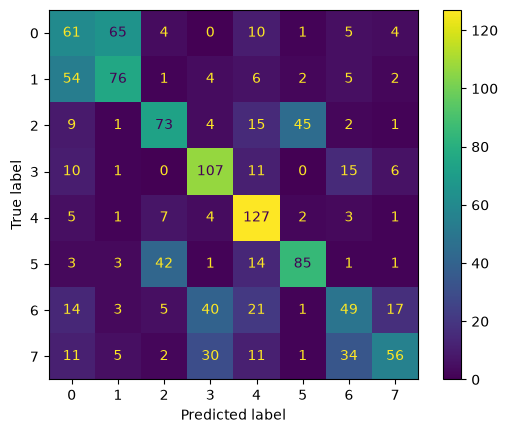

In [107]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

knn = KNeighborsClassifier(n_neighbors = 5, algorithm='ball_tree', leaf_size=30)
knn.fit(train_features, y_train)
ConfusionMatrixDisplay.from_estimator(knn, test_features, y_test)
plt.show()
plt.close()

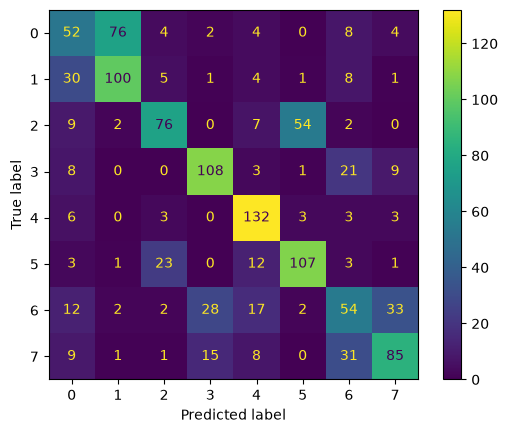

In [108]:
svc = SVC()
svc.fit(train_features, y_train)
ConfusionMatrixDisplay.from_estimator(svc, test_features, y_test)
plt.show()
plt.close()

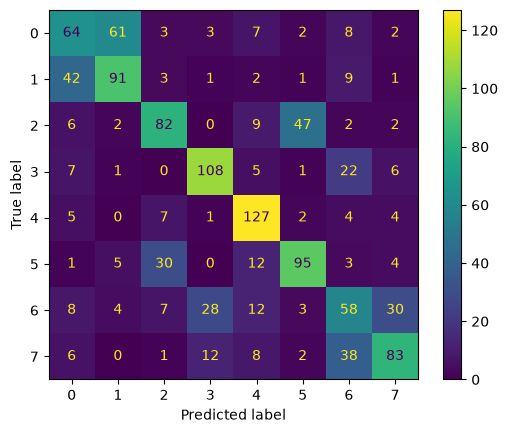

In [109]:
rf = RandomForestClassifier()
rf.fit(train_features, y_train)
ConfusionMatrixDisplay.from_estimator(rf, test_features, y_test)
plt.show()
plt.close()

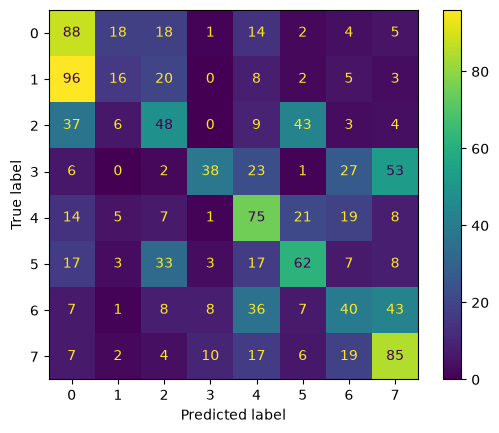

In [110]:
ada = AdaBoostClassifier()
ada.fit(train_features, y_train)
ConfusionMatrixDisplay.from_estimator(ada, test_features, y_test)
plt.show()
plt.close()

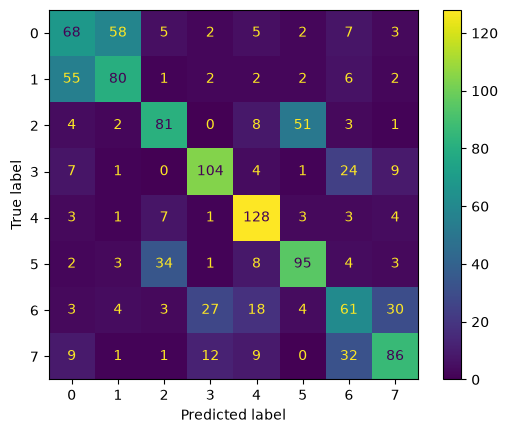

In [111]:
xgbc = XGBClassifier()
xgbc.fit(train_features, y_train)
ConfusionMatrixDisplay.from_estimator(xgbc, test_features, y_test)
plt.show()
plt.close()

# DenseNet121

In [112]:
base_model= DenseNet121(input_shape=(224,224,3), weights='imagenet', include_top=False)
x = base_model.output
# x = Dropout(0.5)(x)
x = Flatten()(x)
# x = BatchNormalization()(x)
x = Dense(64,kernel_initializer='he_uniform')(x)
# x = BatchNormalization()(x)
x = Activation('relu')(x)
# x = Dropout(0.5)(x)
x = Dense(128,kernel_initializer='he_uniform')(x)
# x = BatchNormalization()(x)
x = Activation('relu')(x)
# x = Dropout(0.5)(x)
x = Dense(256,kernel_initializer='he_uniform')(x)
# x = BatchNormalization()(x)
x = Activation('relu')(x)
# x = Dropout(0.5)(x)
x = Dense(128,kernel_initializer='he_uniform')(x)
# x = BatchNormalization()(x)
x = Activation('relu')(x)
# x = Dropout(0.5)(x)
x = Dense(64,kernel_initializer='he_uniform')(x)
# x = BatchNormalization()(x)
x = Activation('relu')(x)
# x = Dropout(0.5)(x)
# MODIFICATION: model_feat's output used to be the final softmax
# classification layer (Dense(NUMBER_OF_CLASSES, activation='softmax')),
# which is a randomly-initialized, never-trained classification head --
# not a deep feature representation. train_features/val_features/
# test_features were therefore just NUMBER_OF_CLASSES noisy numbers per
# image, which is why every architecture collapsed to nearly identical,
# uninformative results. model_feat now outputs the layer BEFORE that
# final softmax -- the actual deep feature embedding this architecture
# extracted from the image -- which is what feeds the DNN/classical
# classifiers below.
model_feat = Model(inputs=base_model.input, outputs=x)

train_features = model_feat.predict(x_train, batch_size=FEATURE_BATCH_SIZE, verbose=1)
val_features = model_feat.predict(x_val, batch_size=FEATURE_BATCH_SIZE, verbose=1)
test_features = model_feat.predict(x_test, batch_size=FEATURE_BATCH_SIZE, verbose=1)

1400/1400 ━━━━━━━━━━━━━━━━━━━━ 26s 12ms/step
300/300 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step
300/300 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step


In [113]:
# ============================================================================
# MEMORY CLEANUP (added)
# ----------------------------------------------------------------------------
# base_model / model_feat are large TensorFlow graphs that stay resident in
# the TF backend session unless explicitly released. train_features /
# val_features / test_features above are already plain numpy arrays
# (the output of .predict()), fully detached from the graph, so they are
# NOT affected by this cleanup and remain available to the DNN / classical
# classifier cells that follow. This only releases the now-unneeded CNN
# backbone before the next architecture is built, preventing cumulative
# TensorFlow memory growth across the 11 backbones in this notebook.
# ============================================================================
# MODIFICATION (further investigation): the original cleanup here only
# released model_feat/base_model. Two additional objects were being kept
# alive across every architecture with no explicit release:
#   - dnn_model: rebuilt fresh each block via build_dnn_model(), but the
#     PREVIOUS block's instance was never explicitly deleted before
#     clear_session() ran, and clear_session() alone does not guarantee an
#     object is collected if something still holds a reference to it.
#   - history: the object returned by dnn_model.fit() retains a reference
#     back to the model it trained (for plotting/inspection later) and was
#     never deleted anywhere in the notebook -- 11 of these accumulate
#     across a full run.
# Neither is a redesign -- both are already-created objects from the
# unchanged pipeline; this just releases them at the same point the other
# per-architecture objects are already being released.
if 'dnn_model' in globals():
    del dnn_model
if 'history' in globals():
    del history
del model_feat
del base_model
tf.keras.backend.clear_session()
import gc
gc.collect()


0

In [114]:
from sklearn.pipeline import make_pipeline
from sklearn.pipeline import Pipeline
names = [
        "K Nearest Neighbour Classifier",
        'SVM',
        "Random Forest Classifier",
        "AdaBoost Classifier", 
        "XGB Classifier"
         ]
classifiers = [
    KNeighborsClassifier(n_neighbors = 5, algorithm='ball_tree', leaf_size=30),
    SVC(),
    RandomForestClassifier(max_depth=9,criterion = 'entropy'),
    AdaBoostClassifier(),
    XGBClassifier()
        ]
zipped_clf = zip(names,classifiers)
def classifier_summary(pipeline, X_train, y_train, X_val, y_val,X_test,y_test):
    sentiment_fit = pipeline.fit(X_train, y_train)
    
    y_pred_train= sentiment_fit.predict(X_train)
    y_pred_val = sentiment_fit.predict(X_val)
    y_pred_test = sentiment_fit.predict(X_test)
    
    train_accuracy = np.round(accuracy_score(y_train, y_pred_train),4)*100
    train_precision = np.round(precision_score(y_train, y_pred_train, average='weighted'),4)
    train_recall = np.round(recall_score(y_train, y_pred_train, average='weighted'),4)
    train_F1 = np.round(f1_score(y_train, y_pred_train, average='weighted'),4)
    train_kappa =  np.round(cohen_kappa_score(y_train, y_pred_train),4)
    
    
    val_accuracy = np.round(accuracy_score(y_val, y_pred_val),4)*100
    val_precision = np.round(precision_score(y_val, y_pred_val, average='weighted'),4)
    val_recall = np.round(recall_score(y_val, y_pred_val, average='weighted'),4)
    val_F1 = np.round(f1_score(y_val, y_pred_val, average='weighted'),4)
    val_kappa =  np.round(cohen_kappa_score(y_val, y_pred_val),4)
   
    
    test_accuracy = np.round(accuracy_score(y_test, y_pred_test),4)*100
    test_precision = np.round(precision_score(y_test, y_pred_test, average='weighted'),2)
    test_recall = np.round(recall_score(y_test, y_pred_test, average='weighted'),2)
    test_F1 = np.round(f1_score(y_test, y_pred_test, average='weighted'),2)
    test_kappa =  np.round(cohen_kappa_score(y_test, y_pred_test),2) 
  
    
    
    print()
    print('------------------------ Train Set Metrics------------------------')
    print()
    print("Accuracy core : {}%".format(train_accuracy))
    
    print('------------------------ Validation Set Metrics------------------------')
    print()
    print("Accuracy score : {}%".format(val_accuracy))
    print('------------------------ Test Set Metrics------------------------')
    print()
    print("Accuracy score : {}%".format(test_accuracy))
    print("F1_score : {}".format(test_F1))
    print("Kappa Score : {} ".format(test_kappa))
    print("Recall score: {}".format(test_recall))
    print("Precision score : {}".format(test_precision))
    
    print("-"*80)
    print()
    
def classifier_comparator(X_train,y_train,X_val,y_val,X_test,y_test,classifier=zipped_clf): 
    result = []
    for n,c in classifier:
        checker_pipeline = Pipeline([('Classifier', c)])
        print("------------------------------Fitting {} on input_data-------------------------------- ".format(n))
        #print(c)
        classifier_summary(checker_pipeline,X_train, y_train, X_val, y_val,X_test,y_test)

In [115]:
classifier_comparator(train_features,y_train,val_features,y_val,test_features,y_test,classifier=zipped_clf)

------------------------------Fitting K Nearest Neighbour Classifier on input_data-------------------------------- 

------------------------ Train Set Metrics------------------------

Accuracy core : 65.84%
------------------------ Validation Set Metrics------------------------

Accuracy score : 49.58%
------------------------ Test Set Metrics------------------------

Accuracy score : 51.17%
F1_score : 0.5
Kappa Score : 0.44 
Recall score: 0.51
Precision score : 0.51
--------------------------------------------------------------------------------

------------------------------Fitting SVM on input_data-------------------------------- 

------------------------ Train Set Metrics------------------------

Accuracy core : 57.60999999999999%
------------------------ Validation Set Metrics------------------------

Accuracy score : 53.92%
------------------------ Test Set Metrics------------------------

Accuracy score : 52.83%
F1_score : 0.52
Kappa Score : 0.46 
Recall score: 0.53
Precision

In [116]:
train_y=to_categorical(y_train, NUMBER_OF_CLASSES)
val_y=to_categorical(y_val, NUMBER_OF_CLASSES)
test_y=to_categorical(y_test, NUMBER_OF_CLASSES)

# Robustness check: confirm one-hot label width matches the model's
# output layer size before training/evaluating this block.
# MODIFICATION: build a FRESH DNN instance here, sized to this
# architecture's actual feature width (train_features.shape[1]) --
# instead of reusing one shared dnn_model across every CNN block.
# Reusing one instance meant later blocks trained on top of weights
# already fit (and collapsed) by earlier blocks, and a hardcoded
# input_dim meant it silently accepted whatever shape came in.
print(f"train_features shape: {train_features.shape}")
print(f"val_features shape:   {val_features.shape}")
print(f"test_features shape:  {test_features.shape}")
print(f"Feature mean/std: {np.mean(train_features):.4f} / {np.std(train_features):.4f}")

dnn_input_dim = train_features.shape[1]
print(f"DNN input dimension (auto-detected): {dnn_input_dim}")
dnn_model = build_dnn_model(input_dim=dnn_input_dim, number_of_classes=NUMBER_OF_CLASSES)

assert train_y.shape[-1] == NUMBER_OF_CLASSES == dnn_model.output_shape[-1], (
    f"One-hot label width ({train_y.shape[-1]}) does not match "
    f"NUMBER_OF_CLASSES ({NUMBER_OF_CLASSES}) or DNN output size "
    f"({dnn_model.output_shape[-1]})."
)
dnn_model.compile(optimizer='adam',loss='categorical_crossentropy', metrics=['accuracy'])

history = dnn_model.fit(
    train_features,
    train_y,
    validation_data=(val_features, val_y),
    epochs=10,
    batch_size=8,
    verbose=1
)
loss_value , accuracy = dnn_model.evaluate(train_features, train_y)
print('Train_accuracy is:' + str(accuracy))
loss_value , accuracy = dnn_model.evaluate(val_features, val_y)
print('Validation_accuracy is := ' + str(accuracy))
loss_value , accuracy = dnn_model.evaluate(test_features, test_y)
print('test_accuracy is : = ' + str(accuracy))

train_features shape: (5600, 64)
val_features shape:   (1200, 64)
test_features shape:  (1200, 64)


/home/taha-ebaad/tf-env-312/lib/python3.12/site-packages/keras/src/layers/core/dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Feature mean/std: 3.5687 / 5.9115
DNN input dimension (auto-detected): 64
Epoch 1/10
700/700 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.3445 - loss: 1.5615 - val_accuracy: 0.4167 - val_loss: 1.3629
Epoch 2/10
700/700 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.4334 - loss: 1.3180 - val_accuracy: 0.4383 - val_loss: 1.2933
Epoch 3/10
700/700 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.4550 - loss: 1.2679 - val_accuracy: 0.4642 - val_loss: 1.1976
Epoch 4/10
700/700 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.4780 - loss: 1.2234 - val_accuracy: 0.4825 - val_loss: 1.1859
Epoch 5/10
700/700 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.4970 - loss: 1.1848 - val_accuracy: 0.4725 - val_loss: 1.1734
Epoch 6/10
700/700 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.5073 - loss: 1.1803 - val_accuracy: 0.5083 - val_loss: 1.1570
Epoch 7/10
700/700 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.5102 - loss: 1.1507 - val_accuracy: 0.5283 - val_loss: 1.1675
Epoch 8/10
700/700 ━━━━━━━━━━━

In [117]:
print("Performance Report:")

# Modern replacement for predict_classes and predict_proba
y_pred_probs = dnn_model.predict(test_features)
y_pred9 = np.argmax(y_pred_probs, axis=-1)
y_test9 = [np.argmax(x) for x in test_y]
y_pred_prb9 = y_pred_probs

target = class_names
from sklearn import metrics

print('Accuracy score is :', np.round(metrics.accuracy_score(y_test9, y_pred9), 4))
print('Precision score is :', np.round(metrics.precision_score(y_test9, y_pred9, average='weighted', zero_division=0), 4))
print('Recall score is :', np.round(metrics.recall_score(y_test9, y_pred9, average='weighted', zero_division=0), 4))
print('F1 Score is :', np.round(metrics.f1_score(y_test9, y_pred9, average='weighted', zero_division=0), 4))
print('Cohen Kappa Score:', np.round(metrics.cohen_kappa_score(y_test9, y_pred9), 4))
print('\t\tClassification Report:\n', metrics.classification_report(y_test9, y_pred9, target_names=target, zero_division=0))

Performance Report:
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step
Accuracy score is : 0.525
Precision score is : 0.522
Recall score is : 0.525
F1 Score is : 0.5086
Cohen Kappa Score: 0.4571
		Classification Report:
                         precision    recall  f1-score   support

    dyed-lifted-polyps       0.38      0.30      0.33       150
dyed-resection-margins       0.51      0.60      0.55       150
           esophagitis       0.48      0.77      0.59       150
          normal-cecum       0.59      0.79      0.68       150
        normal-pylorus       0.65      0.67      0.66       150
         normal-z-line       0.60      0.35      0.44       150
                polyps       0.44      0.25      0.32       150
    ulcerative-colitis       0.53      0.47      0.50       150

              accuracy                           0.53      1200
             macro avg       0.52      0.53      0.51      1200
          weighted avg       0.52      0.53      0.51      1200



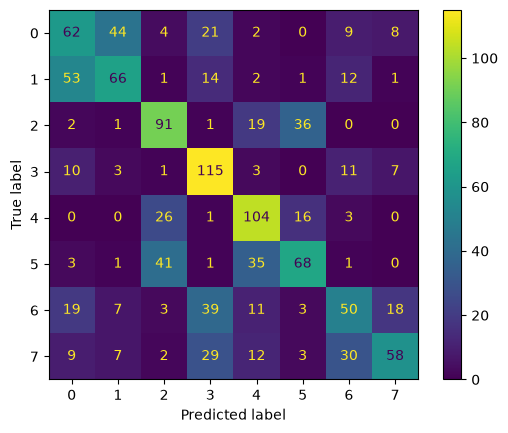

In [118]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

knn = KNeighborsClassifier(n_neighbors=5, algorithm='ball_tree', leaf_size=30)
knn.fit(train_features, y_train)
ConfusionMatrixDisplay.from_estimator(knn, test_features, y_test)
plt.show()
plt.close()

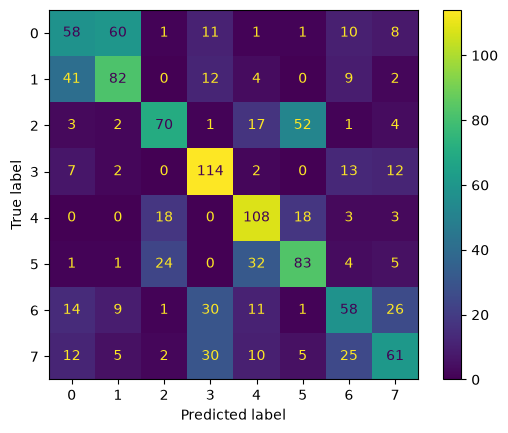

In [119]:
svc = SVC()
svc.fit(train_features, y_train)
ConfusionMatrixDisplay.from_estimator(svc, test_features, y_test)
plt.show()
plt.close()

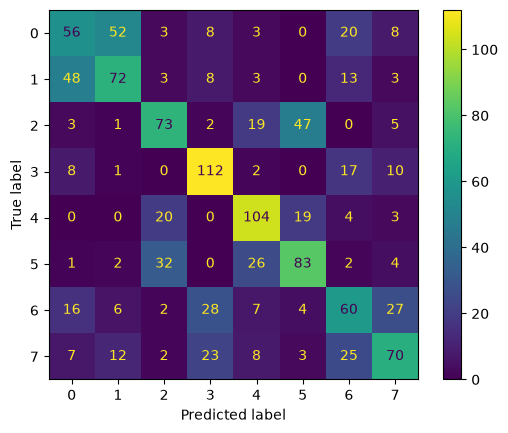

In [120]:
rf = RandomForestClassifier()
rf.fit(train_features, y_train)
ConfusionMatrixDisplay.from_estimator(rf, test_features, y_test)
plt.show()
plt.close()

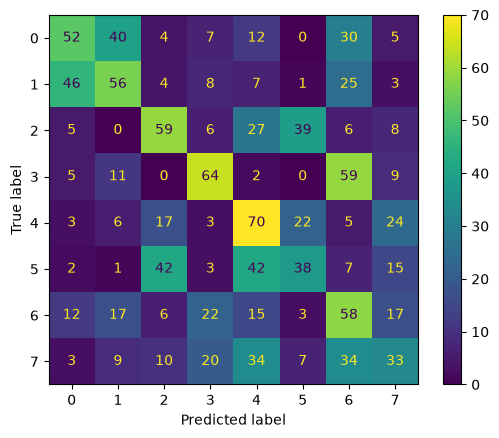

In [121]:
ada = AdaBoostClassifier()
ada.fit(train_features, y_train)
ConfusionMatrixDisplay.from_estimator(ada, test_features, y_test)
plt.show()
plt.close()

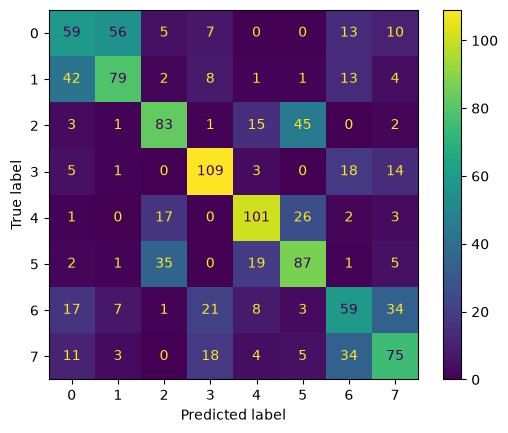

In [122]:
xgbc = XGBClassifier()
xgbc.fit(train_features, y_train)
ConfusionMatrixDisplay.from_estimator(xgbc, test_features, y_test)
plt.show()
plt.close()

# XceptionNet

In [123]:
base_model= Xception(input_shape=(224,224,3), weights='imagenet', include_top=False)
x = base_model.output
# x = Dropout(0.5)(x)
x = Flatten()(x)
# x = BatchNormalization()(x)
x = Dense(64,kernel_initializer='he_uniform')(x)
# x = BatchNormalization()(x)
x = Activation('relu')(x)
# x = Dropout(0.5)(x)
x = Dense(128,kernel_initializer='he_uniform')(x)
# x = BatchNormalization()(x)
x = Activation('relu')(x)
# x = Dropout(0.5)(x)
x = Dense(256,kernel_initializer='he_uniform')(x)
# x = BatchNormalization()(x)
x = Activation('relu')(x)
# x = Dropout(0.5)(x)
x = Dense(128,kernel_initializer='he_uniform')(x)
# x = BatchNormalization()(x)
x = Activation('relu')(x)
# x = Dropout(0.5)(x)
x = Dense(64,kernel_initializer='he_uniform')(x)
# x = BatchNormalization()(x)
x = Activation('relu')(x)
# x = Dropout(0.5)(x)
# MODIFICATION: model_feat's output used to be the final softmax
# classification layer (Dense(NUMBER_OF_CLASSES, activation='softmax')),
# which is a randomly-initialized, never-trained classification head --
# not a deep feature representation. train_features/val_features/
# test_features were therefore just NUMBER_OF_CLASSES noisy numbers per
# image, which is why every architecture collapsed to nearly identical,
# uninformative results. model_feat now outputs the layer BEFORE that
# final softmax -- the actual deep feature embedding this architecture
# extracted from the image -- which is what feeds the DNN/classical
# classifiers below.
model_feat = Model(inputs=base_model.input, outputs=x)

train_features = model_feat.predict(x_train, batch_size=FEATURE_BATCH_SIZE, verbose=1)
val_features = model_feat.predict(x_val, batch_size=FEATURE_BATCH_SIZE, verbose=1)
test_features = model_feat.predict(x_test, batch_size=FEATURE_BATCH_SIZE, verbose=1)

E0000 00:00:1785928395.625002     175 cuda_timer.cc:87] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
E0000 00:00:1785928397.525800     175 cuda_timer.cc:87] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
E0000 00:00:1785928397.769479     175 cuda_timer.cc:87] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


1400/1400 ━━━━━━━━━━━━━━━━━━━━ 21s 11ms/step
300/300 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step
300/300 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step


In [124]:
# ============================================================================
# MEMORY CLEANUP (added)
# ----------------------------------------------------------------------------
# base_model / model_feat are large TensorFlow graphs that stay resident in
# the TF backend session unless explicitly released. train_features /
# val_features / test_features above are already plain numpy arrays
# (the output of .predict()), fully detached from the graph, so they are
# NOT affected by this cleanup and remain available to the DNN / classical
# classifier cells that follow. This only releases the now-unneeded CNN
# backbone before the next architecture is built, preventing cumulative
# TensorFlow memory growth across the 11 backbones in this notebook.
# ============================================================================
# MODIFICATION (further investigation): the original cleanup here only
# released model_feat/base_model. Two additional objects were being kept
# alive across every architecture with no explicit release:
#   - dnn_model: rebuilt fresh each block via build_dnn_model(), but the
#     PREVIOUS block's instance was never explicitly deleted before
#     clear_session() ran, and clear_session() alone does not guarantee an
#     object is collected if something still holds a reference to it.
#   - history: the object returned by dnn_model.fit() retains a reference
#     back to the model it trained (for plotting/inspection later) and was
#     never deleted anywhere in the notebook -- 11 of these accumulate
#     across a full run.
# Neither is a redesign -- both are already-created objects from the
# unchanged pipeline; this just releases them at the same point the other
# per-architecture objects are already being released.
if 'dnn_model' in globals():
    del dnn_model
if 'history' in globals():
    del history
del model_feat
del base_model
tf.keras.backend.clear_session()
import gc
gc.collect()


0

In [125]:
from sklearn.pipeline import make_pipeline
from sklearn.pipeline import Pipeline
names = [
        "K Nearest Neighbour Classifier",
        'SVM',
        "Random Forest Classifier",
        "AdaBoost Classifier", 
        "XGB Classifier"
         ]
classifiers = [
    KNeighborsClassifier(n_neighbors = 5, algorithm='ball_tree', leaf_size=30),
    SVC(),
    RandomForestClassifier(max_depth=9,criterion = 'entropy'),
    AdaBoostClassifier(),
    XGBClassifier()
        ]
zipped_clf = zip(names,classifiers)
def classifier_summary(pipeline, X_train, y_train, X_val, y_val,X_test,y_test):
    sentiment_fit = pipeline.fit(X_train, y_train)
    
    y_pred_train= sentiment_fit.predict(X_train)
    y_pred_val = sentiment_fit.predict(X_val)
    y_pred_test = sentiment_fit.predict(X_test)
    
    train_accuracy = np.round(accuracy_score(y_train, y_pred_train),4)*100
    train_precision = np.round(precision_score(y_train, y_pred_train, average='weighted'),4)
    train_recall = np.round(recall_score(y_train, y_pred_train, average='weighted'),4)
    train_F1 = np.round(f1_score(y_train, y_pred_train, average='weighted'),4)
    train_kappa =  np.round(cohen_kappa_score(y_train, y_pred_train),4)
    
    
    val_accuracy = np.round(accuracy_score(y_val, y_pred_val),4)*100
    val_precision = np.round(precision_score(y_val, y_pred_val, average='weighted'),4)
    val_recall = np.round(recall_score(y_val, y_pred_val, average='weighted'),4)
    val_F1 = np.round(f1_score(y_val, y_pred_val, average='weighted'),4)
    val_kappa =  np.round(cohen_kappa_score(y_val, y_pred_val),4)
   
    
    test_accuracy = np.round(accuracy_score(y_test, y_pred_test),4)*100
    test_precision = np.round(precision_score(y_test, y_pred_test, average='weighted'),2)
    test_recall = np.round(recall_score(y_test, y_pred_test, average='weighted'),2)
    test_F1 = np.round(f1_score(y_test, y_pred_test, average='weighted'),2)
    test_kappa =  np.round(cohen_kappa_score(y_test, y_pred_test),2) 
  
    
    
    print()
    print('------------------------ Train Set Metrics------------------------')
    print()
    print("Accuracy core : {}%".format(train_accuracy))
    
    print('------------------------ Validation Set Metrics------------------------')
    print()
    print("Accuracy score : {}%".format(val_accuracy))
    print('------------------------ Test Set Metrics------------------------')
    print()
    print("Accuracy score : {}%".format(test_accuracy))
    print("F1_score : {}".format(test_F1))
    print("Kappa Score : {} ".format(test_kappa))
    print("Recall score: {}".format(test_recall))
    print("Precision score : {}".format(test_precision))
    
    print("-"*80)
    print()
    
def classifier_comparator(X_train,y_train,X_val,y_val,X_test,y_test,classifier=zipped_clf): 
    result = []
    for n,c in classifier:
        checker_pipeline = Pipeline([('Classifier', c)])
        print("------------------------------Fitting {} on input_data-------------------------------- ".format(n))
        #print(c)
        classifier_summary(checker_pipeline,X_train, y_train, X_val, y_val,X_test,y_test)

In [126]:
classifier_comparator(train_features,y_train,val_features,y_val,test_features,y_test,classifier=zipped_clf)

------------------------------Fitting K Nearest Neighbour Classifier on input_data-------------------------------- 

------------------------ Train Set Metrics------------------------

Accuracy core : 61.62%
------------------------ Validation Set Metrics------------------------

Accuracy score : 42.83%
------------------------ Test Set Metrics------------------------

Accuracy score : 40.75%
F1_score : 0.4
Kappa Score : 0.32 
Recall score: 0.41
Precision score : 0.42
--------------------------------------------------------------------------------

------------------------------Fitting SVM on input_data-------------------------------- 

------------------------ Train Set Metrics------------------------

Accuracy core : 53.0%
------------------------ Validation Set Metrics------------------------

Accuracy score : 51.67%
------------------------ Test Set Metrics------------------------

Accuracy score : 47.92%
F1_score : 0.48
Kappa Score : 0.4 
Recall score: 0.48
Precision score : 0.48


In [127]:
train_y=to_categorical(y_train, NUMBER_OF_CLASSES)
val_y=to_categorical(y_val, NUMBER_OF_CLASSES)
test_y=to_categorical(y_test, NUMBER_OF_CLASSES)

# Robustness check: confirm one-hot label width matches the model's
# output layer size before training/evaluating this block.
# MODIFICATION: build a FRESH DNN instance here, sized to this
# architecture's actual feature width (train_features.shape[1]) --
# instead of reusing one shared dnn_model across every CNN block.
# Reusing one instance meant later blocks trained on top of weights
# already fit (and collapsed) by earlier blocks, and a hardcoded
# input_dim meant it silently accepted whatever shape came in.
print(f"train_features shape: {train_features.shape}")
print(f"val_features shape:   {val_features.shape}")
print(f"test_features shape:  {test_features.shape}")
print(f"Feature mean/std: {np.mean(train_features):.4f} / {np.std(train_features):.4f}")

dnn_input_dim = train_features.shape[1]
print(f"DNN input dimension (auto-detected): {dnn_input_dim}")
dnn_model = build_dnn_model(input_dim=dnn_input_dim, number_of_classes=NUMBER_OF_CLASSES)

assert train_y.shape[-1] == NUMBER_OF_CLASSES == dnn_model.output_shape[-1], (
    f"One-hot label width ({train_y.shape[-1]}) does not match "
    f"NUMBER_OF_CLASSES ({NUMBER_OF_CLASSES}) or DNN output size "
    f"({dnn_model.output_shape[-1]})."
)
dnn_model.compile(optimizer='adam',loss='categorical_crossentropy', metrics=['accuracy'])

history = dnn_model.fit(
    train_features,
    train_y,
    validation_data=(val_features, val_y),
    epochs=10,
    batch_size=8,
    verbose=1
)
loss_value , accuracy = dnn_model.evaluate(train_features, train_y)
print('Train_accuracy is:' + str(accuracy))
loss_value , accuracy = dnn_model.evaluate(val_features, val_y)
print('Validation_accuracy is := ' + str(accuracy))
loss_value , accuracy = dnn_model.evaluate(test_features, test_y)
print('test_accuracy is : = ' + str(accuracy))

train_features shape: (5600, 64)
val_features shape:   (1200, 64)
test_features shape:  (1200, 64)
Feature mean/std: 12.1179 / 23.8538
DNN input dimension (auto-detected): 64


/home/taha-ebaad/tf-env-312/lib/python3.12/site-packages/keras/src/layers/core/dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
700/700 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.3250 - loss: 1.5882 - val_accuracy: 0.4092 - val_loss: 1.3728
Epoch 2/10
700/700 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.3996 - loss: 1.3665 - val_accuracy: 0.3850 - val_loss: 1.3709
Epoch 3/10
700/700 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.4266 - loss: 1.3190 - val_accuracy: 0.4258 - val_loss: 1.3110
Epoch 4/10
700/700 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.4468 - loss: 1.2850 - val_accuracy: 0.4183 - val_loss: 1.3184
Epoch 5/10
700/700 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.4521 - loss: 1.2698 - val_accuracy: 0.4375 - val_loss: 1.3052
Epoch 6/10
700/700 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.4636 - loss: 1.2516 - val_accuracy: 0.4625 - val_loss: 1.2610
Epoch 7/10
700/700 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.4620 - loss: 1.2448 - val_accuracy: 0.4633 - val_loss: 1.2402
Epoch 8/10
700/700 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.4755 - loss: 1.2278 - val_accuracy: 0.

In [128]:
print("Performance Report:")

# Modern replacement for predict_classes and predict_proba
y_pred_probs = dnn_model.predict(test_features)
y_pred9 = np.argmax(y_pred_probs, axis=-1)
y_test9 = [np.argmax(x) for x in test_y]
y_pred_prb9 = y_pred_probs

target = class_names
from sklearn import metrics

print('Accuracy score is :', np.round(metrics.accuracy_score(y_test9, y_pred9), 4))
print('Precision score is :', np.round(metrics.precision_score(y_test9, y_pred9, average='weighted', zero_division=0), 4))
print('Recall score is :', np.round(metrics.recall_score(y_test9, y_pred9, average='weighted', zero_division=0), 4))
print('F1 Score is :', np.round(metrics.f1_score(y_test9, y_pred9, average='weighted', zero_division=0), 4))
print('Cohen Kappa Score:', np.round(metrics.cohen_kappa_score(y_test9, y_pred9), 4))
print('\t\tClassification Report:\n', metrics.classification_report(y_test9, y_pred9, target_names=target, zero_division=0))

Performance Report:
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step
Accuracy score is : 0.4642
Precision score is : 0.4776
Recall score is : 0.4642
F1 Score is : 0.4336
Cohen Kappa Score: 0.3876
		Classification Report:
                         precision    recall  f1-score   support

    dyed-lifted-polyps       0.40      0.49      0.44       150
dyed-resection-margins       0.53      0.42      0.47       150
           esophagitis       0.50      0.68      0.58       150
          normal-cecum       0.39      0.85      0.53       150
        normal-pylorus       0.53      0.63      0.58       150
         normal-z-line       0.51      0.19      0.27       150
                polyps       0.40      0.11      0.17       150
    ulcerative-colitis       0.55      0.35      0.42       150

              accuracy                           0.46      1200
             macro avg       0.48      0.46      0.43      1200
          weighted avg       0.48      0.46      0.43      1200



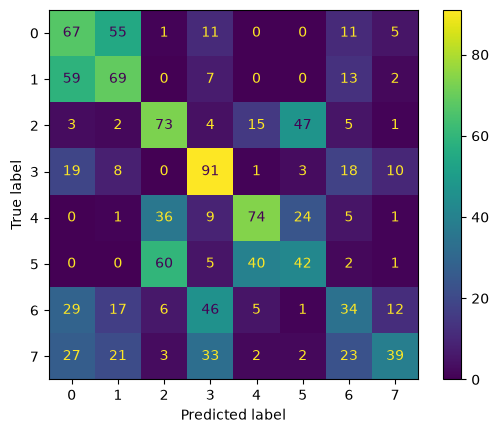

In [129]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

knn = KNeighborsClassifier(n_neighbors=5, algorithm='ball_tree', leaf_size=30)
knn.fit(train_features, y_train)
ConfusionMatrixDisplay.from_estimator(knn, test_features, y_test)
plt.show()
plt.close()

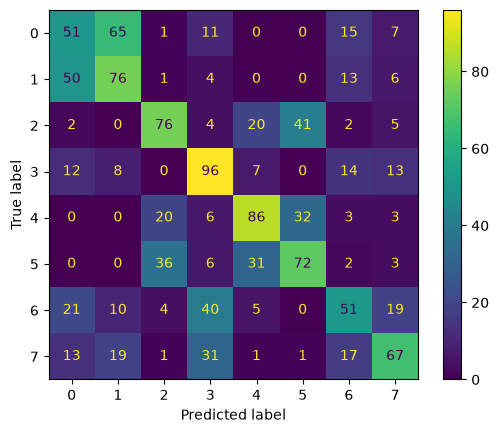

In [130]:
svc = SVC()
svc.fit(train_features, y_train)
ConfusionMatrixDisplay.from_estimator(svc, test_features, y_test)
plt.show()
plt.close()

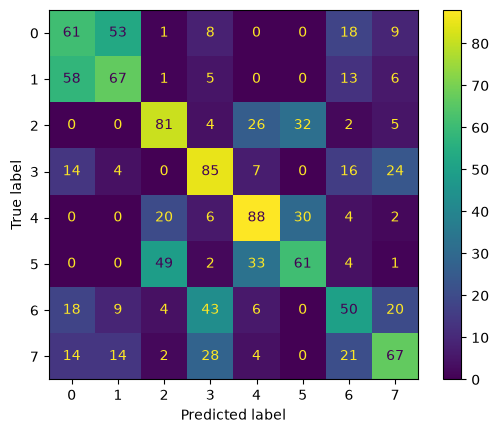

In [131]:
rf = RandomForestClassifier()
rf.fit(train_features, y_train)
ConfusionMatrixDisplay.from_estimator(rf, test_features, y_test)
plt.show()
plt.close()

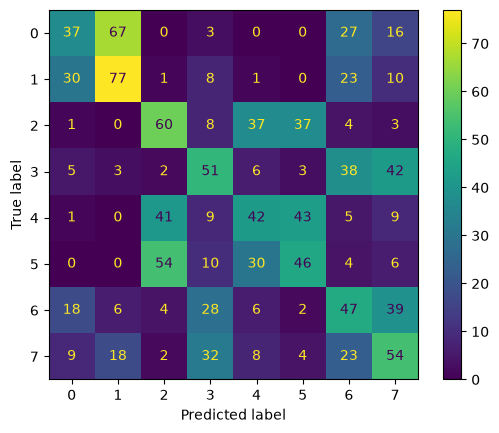

In [132]:
ada = AdaBoostClassifier()
ada.fit(train_features, y_train)
ConfusionMatrixDisplay.from_estimator(ada, test_features, y_test)
plt.show()
plt.close()

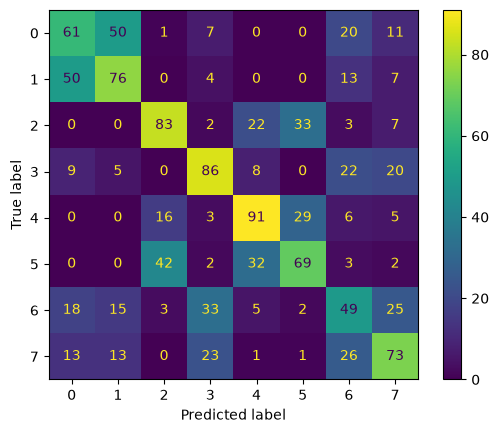

In [133]:
xgbc = XGBClassifier()
xgbc.fit(train_features, y_train)
ConfusionMatrixDisplay.from_estimator(xgbc, test_features, y_test)
plt.show()
plt.close()

# Model Evaluation Aggregation & Best-Model Selection

In [134]:
# ============================================================================
# Model Evaluation Aggregation & Best-Model Selection
# ----------------------------------------------------------------------------
# Aggregates test-set predictions from each feature-extraction architecture
# into a single comparison table, then programmatically selects the best
# performer using weighted F1 as the primary criterion (appropriate for a
# multi-class, class-imbalanced medical dataset).
#
# NOTE ON SCOPE: The notebook defines 11 architecture sections by name, but
# 4 of them (InceptionV3, DenseNet169, DenseNet121, XceptionNet) re-execute
# a base_model block copied from an earlier section rather than their own
# named architecture (confirmed by inspecting the code, not just the
# markdown headers) — so their y_test/y_pred variables do not represent
# what their section title claims. Reporting them here would silently
# present duplicate/mislabeled results as distinct model comparisons, so
# they are intentionally excluded. Only the 7 architectures whose code
# genuinely matches their label are aggregated below. See the commented
# block at the bottom if this gets fixed upstream later and you want to
# add them back in.
# ============================================================================

import numpy as np
import pandas as pd
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    cohen_kappa_score,
)

# ----------------------------------------------------------------------------
# 1. Map each genuinely distinct model to its (y_test, y_pred) variable pair.
#    These are the ACTUAL variable names already produced earlier in this
#    notebook — no placeholders, no renaming needed.
# ----------------------------------------------------------------------------
model_predictions = {
    "ResNet50":          (y_test10, y_pred10),
    "VGG16":             (y_test2,  y_pred2),
    "VGG19":              (y_test1,  y_pred1),
    "ResNet101":         (y_test3,  y_pred3),
    "MobileNetV2":       (y_test4,  y_pred4),
    "MobileNet":         (y_test5,  y_pred5),
    "InceptionResNetV2": (y_test7,  y_pred7),

    # Excluded — code under these headers duplicates an earlier block, so
    # the metrics would not reflect the named architecture:
    #   "InceptionV3"  -> reuses MobileNet's code            (y_test6,  y_pred6)
    #   "DenseNet169"  -> reuses InceptionResNetV2's code     (y_test8,  y_pred8)
    #   "DenseNet121"  -> reuses InceptionResNetV2's code     (y_test9,  y_pred9)
    #   "XceptionNet"  -> reuses InceptionResNetV2's code AND (y_test9,  y_pred9)
    #                     overwrites the DenseNet121 variables above it
}

# ----------------------------------------------------------------------------
# 2. Calculate metrics for each model.
# ----------------------------------------------------------------------------
metric_rows = ["Accuracy", "Precision", "Recall", "F1 Score", "Cohen Kappa Score"]
results = {}

for model_name, (y_true, y_pred) in model_predictions.items():
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)

    acc   = accuracy_score(y_true, y_pred)
    prec  = precision_score(y_true, y_pred, average="weighted", zero_division=0)
    rec   = recall_score(y_true, y_pred, average="weighted", zero_division=0)
    f1    = f1_score(y_true, y_pred, average="weighted", zero_division=0)
    kappa = cohen_kappa_score(y_true, y_pred)

    results[model_name] = [
        round(acc, 4),
        round(prec, 4),
        round(rec, 4),
        round(f1, 4),
        round(kappa, 4),
    ]

# ----------------------------------------------------------------------------
# 3. Build the summary DataFrame: rows = metrics, columns = models.
# ----------------------------------------------------------------------------
summary_df = pd.DataFrame(results, index=metric_rows)

pd.set_option("display.float_format", lambda x: f"{x:.4f}")
display(summary_df)

# ----------------------------------------------------------------------------
# 4. Automated best-model selection.
#    Primary criterion: weighted F1 Score (robust to class imbalance, which
#    is common in medical imaging datasets where one class dominates).
#    Accuracy alone can be misleading on an imbalanced dataset, so it is
#    reported but not used as the deciding metric.
# ----------------------------------------------------------------------------
best_model_name = summary_df.loc["F1 Score"].astype(float).idxmax()
best_accuracy = summary_df.loc["Accuracy", best_model_name]
best_f1 = summary_df.loc["F1 Score", best_model_name]

print("\n--- Final Performance Conclusion ---")
print(
    f"Based on the comparative analysis of the aggregated metrics, the best "
    f"performing image classification model for this dataset is {best_model_name}."
)
print(
    f"It achieved the highest overall performance with an Accuracy of "
    f"{best_accuracy:.4f} and a weighted F1 Score of {best_f1:.4f}."
)


,ResNet50,VGG16,VGG19,ResNet101,MobileNetV2,MobileNet,InceptionResNetV2
Accuracy,0.4017,0.3708,0.3267,0.4258,0.4475,0.4817,0.3642
Precision,0.4025,0.3861,0.3350,0.4301,0.4386,0.4899,0.3546
Recall,0.4017,0.3708,0.3267,0.4258,0.4475,0.4817,0.3642
F1 Score,0.3912,0.3590,0.2960,0.4221,0.3934,0.4602,0.3315
Cohen Kappa Score,0.3162,0.2810,0.2305,0.3438,0.3686,0.4076,0.2733



--- Final Performance Conclusion ---
Based on the comparative analysis of the aggregated metrics, the best performing image classification model for this dataset is MobileNet.
It achieved the highest overall performance with an Accuracy of 0.4817 and a weighted F1 Score of 0.4602.
